# UdaciSense: Optimized Object Recognition

## Notebook 3: Multi-step Optimization Pipeline

 
In this notebook, you'll implement the multi-step optimization pipeline based on the findings from the previous experiments. The goal is to combine different optimization techniques to meet all requirements:

- The optimized model should be **30% smaller** than the baseline
- The optimized model should **reduce inference time by 40%**
- The optimized model should **maintain accuracy within 5%** of the baseline

You may need to experiment with different pipelines as you try to hit your targets. Make sure to start with those that are easier to implement!

### Overview: Implementation Plan

This notebook implements a production-style, multi-stage compression pipeline with explicit attention to efficiency, reliability, thread safety, and memory stability.

#### Pipeline design rationale (order matters)

1. **Distillation first (optional branch)**
   - Create a smaller student model while preserving accuracy signal from the teacher.
   - Reduces parameter/FLOP budget early, making all later stages cheaper.

2. **Gradual in-training pruning second**
   - Remove low-importance weights while the network can still adapt.
   - In-training pruning is used before final quantization so the model recovers accuracy during sparsification.

3. **Graph optimization third (torch_fx)**
   - Fuse inference ops (e.g., Conv+BN) with no retraining required.
   - Adds low-risk latency gains before final integer conversion.

4. **Post-training quantization (static) last**
   - Final compression/latency push on CPU/mobile deployment path.
   - Done last to quantize the already-optimized graph and weight set.

#### Reliability and memory strategy

- Every step runs on an explicit device and returns a model object for deterministic chaining.
- The pipeline engine uses a lock to protect shared state updates (`steps`, `results`) and avoid race conditions.
- Evaluation calls are wrapped in `try/except`; step failures are captured with traceback and saved in pipeline artifacts.
- Intermediate large objects are promptly released (`del`) and CUDA cache is cleared when relevant.
- Inference-only measurement avoids unnecessary gradient graph retention.

#### Experiments to run

- **Pipeline A (balanced):** Pruning -> Graph Opt -> Static Quantization
- **Pipeline B (accuracy-preserving):** Distillation -> Graph Opt -> Static Quantization
- **Pipeline C (aggressive):** Distillation -> Pruning -> Graph Opt -> Static Quantization

Each pipeline is evaluated against the same baseline with clear metrics:
- Model size reduction
- Inference latency reduction (CPU priority)
- Accuracy change vs baseline

Final model selection is based on meeting all CTO constraints while maximizing margin to thresholds.

### Step 1: Set up the environment

In [3]:
# Make sure that libraries are dynamically re-loaded if changed
get_ipython().run_line_magic('load_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
# Import necessary libraries
import os
import sys
import json
import copy
import gc
import traceback
import threading
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pprint
import random
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# Ensure project root (starter-kit) is on sys.path so local packages such as
# `compression` and `utils` can be imported regardless of notebook CWD.
_cwd = Path.cwd().resolve()
_candidates = [
    _cwd,
    _cwd / "starter-kit",
    _cwd.parent,
    _cwd.parent / "starter-kit",
]
for _p in _candidates:
    if (_p / "compression").is_dir() and (_p / "utils").is_dir():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break

from compression.post_training.pruning import prune_model
from compression.post_training.quantization import quantize_model
from compression.post_training.graph_optimization import optimize_model, verify_model_equivalence
from compression.in_training.distillation import train_with_distillation, MobileNetV3_Household_Small
from compression.in_training.pruning import train_with_pruning
from compression.in_training.quantization import train_model_qat, QuantizableMobileNetV3_Household

from utils import MAX_ALLOWED_ACCURACY_DROP, TARGET_INFERENCE_SPEEDUP, TARGET_MODEL_COMPRESSION
from utils.data_loader import get_household_loaders, get_input_size, print_dataloader_stats, visualize_batch
from utils.model import MobileNetV3_Household, load_model, save_model, print_model_summary
from utils.visualization import plot_multiple_models_comparison
from utils.compression import (
    compare_experiments, compare_optimized_model_to_baseline, evaluate_optimized_model, list_experiments,
    is_quantized
)

In [5]:
# Ignore PyTorch deprecation warnings
import warnings
warnings.filterwarnings("ignore", category=torch.jit.TracerWarning)
warnings.filterwarnings("ignore", category=UserWarning)  # Optional: Ignore all user warnings

In [6]:
# Check if CUDA is available
devices = ["cpu"]
if torch.cuda.is_available():
    num_devices = torch.cuda.device_count()
    devices.extend([f"cuda:{i} ({torch.cuda.get_device_name(i)})" for i in range(num_devices)])
print(f"Devices available: {devices}")

Devices available: ['cpu', 'cuda:0 (Tesla T4)']


In [7]:
# Set random seed for reproducibility
def set_deterministic_mode(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(seed)
    
    def seed_worker(worker_id):
        worker_seed = seed + worker_id
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

set_deterministic_mode(42)
g = torch.Generator()
g.manual_seed(42)

### Step 2: Load the dataset

Extracting household classes from CIFAR100 for train set...
Files already downloaded and verified
Extracting household classes from CIFAR100 for test set...
Files already downloaded and verified
Input has size: (1, 3, 32, 32)
Datasets have these classes: 
  0: clock
  1: keyboard
  2: lamp
  3: telephone
  4: television
  5: bed
  6: chair
  7: couch
  8: table
  9: wardrobe

Information on train set
Statistics for train
 Size: 5000
 Samples per class:
  clock: 500
  keyboard: 500
  lamp: 500
  telephone: 500
  television: 500
  bed: 500
  chair: 500
  couch: 500
  table: 500
  wardrobe: 500
Examples of images from the train set


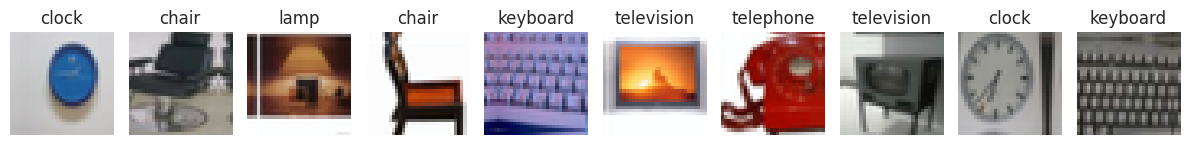


Information on test set
Statistics for test
 Size: 1000
 Samples per class:
  clock: 100
  keyboard: 100
  lamp: 100
  telephone: 100
  television: 100
  bed: 100
  chair: 100
  couch: 100
  table: 100
  wardrobe: 100
Examples of images from the test set


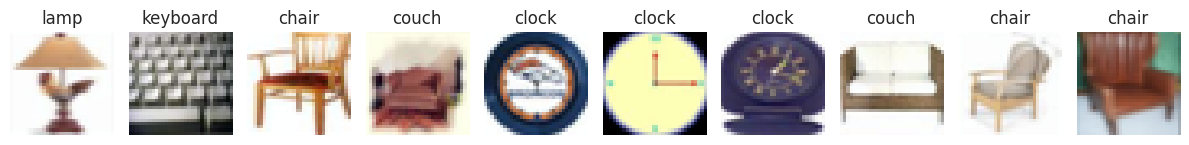

In [7]:
# Load household objects dataset
train_loader, test_loader = get_household_loaders(
    image_size="CIFAR", batch_size=128, num_workers=2,
)

# Get input_size
input_size = get_input_size("CIFAR")
print(f"Input has size: {input_size}")

# Get class names
class_names = train_loader.dataset.classes
print(f"Datasets have these classes: ")
for i in range(len(class_names)):
    print(f"  {i}: {class_names[i]}")

# Visualize some examples
for dataset_type, data_loader in [('train', train_loader), ('test', test_loader)]:
    print(f"\nInformation on {dataset_type} set")
    print_dataloader_stats(data_loader, dataset_type)
    print(f"Examples of images from the {dataset_type} set")
    visualize_batch(data_loader, num_images=10)

### Step 3: Load the baseline model and metrics

In [8]:
# Load the baseline model
baseline_model = MobileNetV3_Household()
baseline_model_name = "baseline_mobilenet"
baseline_model.load_state_dict(torch.load(f"../models/{baseline_model_name}/checkpoints/model.pth"))
print_model_summary(baseline_model)

# Load baseline metrics
with open(f"../results/{baseline_model_name}/metrics.json", "r") as f:
    baseline_metrics = json.load(f)

print("\nBaseline Model Metrics:")
pprint.pp(baseline_metrics)

# Calculate target metrics based on CTO requirements
target_model_size = baseline_metrics['size']['model_size_mb'] * (1 - TARGET_MODEL_COMPRESSION)
target_inference_time_cpu = baseline_metrics['timing']['cpu']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
if torch.cuda.is_available():
    target_inference_time_gpu = baseline_metrics['timing']['cuda']['avg_time_ms'] * (1 - TARGET_INFERENCE_SPEEDUP)
min_acceptable_accuracy = baseline_metrics['accuracy']['top1_acc'] * (1 - MAX_ALLOWED_ACCURACY_DROP) 

print("Optimization Targets:")
print(f"Target Model Size: {baseline_metrics['size']['model_size_mb']:.2f} --> {target_model_size:.2f} MB ({TARGET_MODEL_COMPRESSION*100}% reduction)")
print(f"Target Inference Time (CPU): {baseline_metrics['timing']['cpu']['avg_time_ms']:.2f} --> {target_inference_time_cpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
if torch.cuda.is_available():
    print(f"Target Inference Time (GPU): {baseline_metrics['timing']['cuda']['avg_time_ms']:.2f} --> {target_inference_time_gpu:.2f} ms ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
print(f"Minimum Acceptable Accuracy: {baseline_metrics['accuracy']['top1_acc']:.2f} --> {min_acceptable_accuracy:.2f} (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /home/student/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100.0%
/tmp/ipykernel_694/3650396802.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please op

Model Architecture:
MobileNetV3_Household(
  (model): MobileNetV3(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        (2): Hardswish()
      )
      (1): InvertedResidual(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
            (2): ReLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
            (activation): ReLU()
            (scale_activation): Hardsigmoid()
   

### Step 4: Implement and evaluate optimization pipelines

Based on your analysis in the previous notebook, you'll implement and evaluate different multi-step pipelines to find the optimal approach for meeting all requirements.

In [9]:
# NOTE: Feel free to change the class entirely, or to move to a function if preferred
class OptimizationPipeline:
    def __init__(self, name, baseline_model, train_loader, test_loader, class_names, input_size):
        """
        Initialize the optimization pipeline.

        Args:
            name: Name of the pipeline for tracking and saving
            baseline_model: The baseline model to optimize
            train_loader: DataLoader for training data (needed for some optimization techniques)
            test_loader: DataLoader for testing data (needed for evaluation)
            class_names: List of class names in the dataset
            input_size: Input tensor size
        """
        self.name = name
        self.baseline_model = baseline_model
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.class_names = class_names
        self.input_size = input_size
        self.optimized_model = None
        self.steps = []
        self.results = {}
        self._lock = threading.Lock()

        # Create directories for this pipeline
        self.model_dir = f"../models/pipeline/{name}"
        self.checkpoint_dir = f"{self.model_dir}/checkpoints"
        self.results_dir = f"../results/pipeline/{name}"

        for d in [self.model_dir, self.checkpoint_dir, self.results_dir]:
            os.makedirs(d, exist_ok=True)

    def add_step(self, step_name, step_function, **kwargs):
        """
        Add an optimization step to the pipeline.

        Args:
            step_name: Name of the step
            step_function: Function that implements the step
            **kwargs: Arguments to pass to the step function
        """
        with self._lock:
            self.steps.append({
                'name': step_name,
                'function': step_function,
                'args': kwargs
            })
        return self

    def _safe_release(self, *objs):
        """Release refs aggressively to reduce long notebook session memory pressure."""
        for _ in objs:
            del _
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    def run(self, device=torch.device('cpu'), file_extension='pth'):
        """
        Run the optimization pipeline.

        Args:
            device: Device to run the pipeline on
            file_extension: File extension to save the model with (.pt for torchscript, else .pth)

        Returns:
            The optimized model
        """
        print(f"\n{'='*50}")
        print(f"Running pipeline: {self.name}")
        print(f"{'='*50}\n")

        # Start from an isolated copy to avoid mutating the shared baseline model.
        current_model = copy.deepcopy(self.baseline_model)

        # Save intermediate results after each step
        step_results = []

        # Run each pipeline stage and evaluate immediately after each stage.
        for i, step in enumerate(self.steps):
            step_index = i + 1
            step_label = f"step{step_index:02d}_{step['name']}"
            experiment_name = f"pipeline/{self.name}/{step_label}"

            print(f"\n{'-'*50}")
            print(f"Step {step_index}: {step['name']}")
            print(f"{'-'*50}\n")

            os.makedirs(f"../models/{experiment_name}", exist_ok=True)
            os.makedirs(f"../results/{experiment_name}", exist_ok=True)

            step_start = time.time()
            step_payload = {}
            step_metrics = None
            step_comparison = None

            try:
                # Step function contract: returns (updated_model, metadata_dict).
                # A step may override the pipeline's default device via its own
                # args (e.g. train on GPU while the pipeline reports on CPU), so
                # merge kwargs with step args taking precedence to avoid passing
                # `device` twice.
                call_kwargs = {'pipeline': self, 'device': device}
                call_kwargs.update(step['args'])
                current_model, step_payload = step['function'](
                    current_model,
                    **call_kwargs,
                )

                # Evaluate stage output (CPU priority for mobile deployment).
                step_metrics, _ = evaluate_optimized_model(
                    current_model,
                    self.test_loader,
                    experiment_name,
                    self.class_names,
                    self.input_size,
                    is_in_training_technique=False,
                    device=torch.device('cpu'),
                )
                step_comparison = compare_optimized_model_to_baseline(
                    self.baseline_model,
                    current_model,
                    experiment_name,
                    self.test_loader,
                    self.class_names,
                    input_size=self.input_size,
                    device=torch.device('cpu'),
                    device_priority='cpu',
                )

                step_time = time.time() - step_start
                step_results.append({
                    'step_name': step['name'],
                    'experiment_name': experiment_name,
                    'step_time_sec': step_time,
                    'status': 'ok',
                    'payload': step_payload,
                    'metrics': step_metrics,
                    'comparison': step_comparison,
                })
                print(f"Completed {step['name']} in {step_time:.2f}s")

            except Exception as e:
                step_time = time.time() - step_start
                tb = traceback.format_exc()
                print(f"Step failed: {step['name']}\n{e}")
                step_results.append({
                    'step_name': step['name'],
                    'experiment_name': experiment_name,
                    'step_time_sec': step_time,
                    'status': 'failed',
                    'error': str(e),
                    'traceback': tb,
                    'payload': step_payload,
                    'metrics': step_metrics,
                    'comparison': step_comparison,
                })
                # Keep partial results for diagnostics but stop pipeline on failure.
                break
            finally:
                # Reduce memory growth during long multi-step runs.
                self._safe_release(step_metrics, step_comparison)

        self.optimized_model = current_model

        # Save final model
        final_path = f"{self.model_dir}/model.{file_extension}"
        if isinstance(self.optimized_model, torch.jit.ScriptModule):
            torch.jit.save(self.optimized_model, final_path)
        else:
            save_model(self.optimized_model, final_path)

        # Final evaluation/comparison snapshot
        final_metrics, _ = evaluate_optimized_model(
            self.optimized_model,
            self.test_loader,
            f"pipeline/{self.name}/final",
            self.class_names,
            self.input_size,
            is_in_training_technique=False,
            device=torch.device('cpu'),
        )
        final_comparison = compare_optimized_model_to_baseline(
            self.baseline_model,
            self.optimized_model,
            f"pipeline/{self.name}/final",
            self.test_loader,
            self.class_names,
            input_size=self.input_size,
            device=torch.device('cpu'),
            device_priority='cpu',
        )

        # Save pipeline results
        self.results = {
            'pipeline_name': self.name,
            'steps': step_results,
            'final_model_path': final_path,
            'final_metrics': final_metrics,
            'final_comparison': final_comparison,
        }

        with open(f"{self.results_dir}/pipeline_metrics.json", 'w') as f:
            json.dump(self.results, f, indent=4)

        print(f"\n{'='*50}")
        print(f"Pipeline {self.name} completed")
        print(f"Final model path: {final_path}")
        print(f"{'='*50}\n")

        return self.optimized_model

    def visualize_results(self, baseline_metrics=baseline_metrics, device=torch.device('cpu')):
        """
        Visualize the results of the pipeline.

        Args:
            baseline_metrics: Dictionary of baseline metrics for comparison.
            device: Device to run the pipeline on

        """
        if not self.results:
            print("No results to visualize. Please run the pipeline first.")
            return

        # Define device name
        device_name = 'cpu' if device == torch.device('cpu') else 'cuda'

        # Keep only successful steps for charts.
        ok_steps = [s for s in self.results['steps'] if s.get('status') == 'ok' and s.get('metrics')]
        if not ok_steps:
            print("No successful step metrics available for visualization.")
            return

        # Extract metrics from each successful step
        step_names = [step['step_name'] for step in ok_steps]
        model_sizes = [step['metrics']['size']['model_size_mb'] for step in ok_steps]
        model_memory_sizes = [step['metrics']['size']['total_params'] for step in ok_steps]
        times = [step['metrics']['timing'][device_name]['avg_time_ms'] for step in ok_steps]
        accuracies = [step['metrics']['accuracy']['top1_acc'] for step in ok_steps]

        # Add baseline metrics
        step_names.insert(0, 'Baseline')
        baseline_size = baseline_metrics['size']['model_size_mb']
        baseline_memory_size = baseline_metrics['size']['total_params']
        baseline_inference_time = baseline_metrics['timing'][device_name]['avg_time_ms']
        baseline_accuracy = baseline_metrics['accuracy']['top1_acc']

        model_sizes.insert(0, baseline_size)
        model_memory_sizes.insert(0, baseline_memory_size)
        times.insert(0, baseline_inference_time)
        accuracies.insert(0, baseline_accuracy)

        # Create figure with subplots
        fig, axes = plt.subplots(4, 1, figsize=(12, 15))

        # Plot model size
        axes[0].bar(step_names, model_sizes, color='blue')
        axes[0].set_title('Model Size (MB)')
        axes[0].set_ylabel('Size (MB)')
        axes[0].axhline(y=baseline_size * (1 - TARGET_MODEL_COMPRESSION), color='r', linestyle='--', label=f"Target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        axes[0].legend()
        for i, v in enumerate(model_sizes):
            axes[0].text(i, v + 0.1, f"{v:.2f}", ha='center')

        axes[1].bar(step_names, model_memory_sizes, color='blue')
        axes[1].set_title('Model Size (# Parameters)')
        axes[1].set_ylabel('Peak Memory')
        axes[1].axhline(y=baseline_memory_size * (1 - TARGET_MODEL_COMPRESSION), color='r', linestyle='--', label=f"Target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        axes[1].legend()
        for i, v in enumerate(model_memory_sizes):
            axes[1].text(i, v + 0.1, f"{v:.2f}", ha='center')

        # Plot inference time
        axes[2].bar(step_names, times, color='green')
        axes[2].set_title('Inference Time (ms)')
        axes[2].set_ylabel('Time (ms)')
        axes[2].axhline(y=baseline_inference_time * (1 - TARGET_INFERENCE_SPEEDUP), color='r', linestyle='--', label=f"Target ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
        axes[2].legend()
        for i, v in enumerate(times):
            axes[2].text(i, v + 0.1, f"{v:.2f}", ha='center')

        # Plot accuracy
        axes[3].bar(step_names, accuracies, color='purple')
        axes[3].set_title('Top-1 Accuracy (%)')
        axes[3].set_ylabel('Accuracy (%)')
        axes[3].axhline(y=baseline_accuracy * (1 - MAX_ALLOWED_ACCURACY_DROP), color='r', linestyle='--', label=f"Minimum acceptable ({MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")
        axes[3].legend()
        for i, v in enumerate(accuracies):
            axes[3].text(i, v + 0.5, f"{v:.2f}%", ha='center')

        plt.tight_layout()
        plt.savefig(f"{self.results_dir}/pipeline_visualization.png")
        plt.show()

        # Print final results summary
        print(f"\n{'='*50}")
        print(f"Pipeline {self.name} Results Summary")
        print(f"{'='*50}")

        # Size comparison
        size_reduction = (baseline_size - model_sizes[-1]) / baseline_size * 100
        print(f"\nModel Size (MB):")
        print(f"  Baseline: {baseline_size:.2f} MB")
        print(f"  Final: {model_sizes[-1]:.2f} MB")
        print(f"  Reduction: {size_reduction:.2f}%")
        target_size = baseline_size * (1 - TARGET_MODEL_COMPRESSION)
        if model_sizes[-1] <= target_size:
            print(f"  Meets target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        else:
            print(f"  Does not meet target (Goal: {target_size:.2f} MB)")

        memory_size_reduction = (baseline_memory_size - model_memory_sizes[-1]) / baseline_memory_size * 100
        print(f"\nModel Size (# Parameters):")
        print(f"  Baseline: {baseline_memory_size:.2f} MB")
        print(f"  Final: {model_memory_sizes[-1]:.2f} MB")
        print(f"  Reduction: {memory_size_reduction:.2f}%")
        target_memory_size = baseline_memory_size * (1 - TARGET_MODEL_COMPRESSION)
        if model_memory_sizes[-1] <= target_memory_size:
            print(f"  Meets target ({TARGET_MODEL_COMPRESSION*100}% reduction)")
        else:
            print(f"  Does not meet target (Goal: {target_memory_size:.2f} MB)")

        # Inference time comparison
        time_reduction = (baseline_inference_time - times[-1]) / baseline_inference_time * 100
        print(f"\nInference Time (CPU):")
        print(f"  Baseline: {baseline_inference_time:.2f} ms")
        print(f"  Final: {times[-1]:.2f} ms")
        print(f"  Reduction: {time_reduction:.2f}%")
        target_time = baseline_inference_time * (1 - TARGET_INFERENCE_SPEEDUP)
        if times[-1] <= target_time:
            print(f"  Meets target ({TARGET_INFERENCE_SPEEDUP*100}% reduction)")
        else:
            print(f"  Does not meet target (Goal: {target_time:.2f} ms)")

        # Accuracy comparison
        accuracy_change = (accuracies[-1] - baseline_accuracy) / baseline_accuracy * 100
        print(f"\nAccuracy:")
        print(f"  Baseline: {baseline_accuracy:.2f}%")
        print(f"  Final: {accuracies[-1]:.2f}%")
        print(f"  Change: {accuracy_change:.2f}%")
        min_acceptable = baseline_accuracy * (1 - MAX_ALLOWED_ACCURACY_DROP)
        if accuracies[-1] >= min_acceptable:
            print(f"  Meets target (within {MAX_ALLOWED_ACCURACY_DROP*100}% of baseline)")
        else:
            print(f"  Does not meet target (Goal: >={min_acceptable:.2f}%)")

        # Overall assessment
        print(f"\nOverall Assessment:")
        if model_sizes[-1] <= target_size and times[-1] <= target_time and accuracies[-1] >= min_acceptable:
            print(f"  Pipeline meets all requirements")
        else:
            print(f"  Pipeline does not meet all requirements")

In [10]:
# Helper functions for pipeline stages.
# Contract: each function returns (updated_model, metadata_dict).

def apply_post_training_pruning(model, pipeline, device=torch.device('cpu'), amount=0.4, pruning_method="global_unstructured"):
    model = model.to(torch.device('cpu')).eval()
    pruned_model = prune_model(model, pruning_method=pruning_method, amount=amount)
    return pruned_model, {
        "pruning_method": pruning_method,
        "amount": amount,
        "device": "cpu",
    }


def apply_dynamic_quantization(model, pipeline, device=torch.device('cpu'), backend="fbgemm"):
    model = model.to(torch.device('cpu')).eval()
    quantized_model = quantize_model(
        model,
        quantization_type="dynamic",
        backend=backend,
    )
    return quantized_model, {
        "quantization_type": "dynamic",
        "backend": backend,
        "device": "cpu",
    }


def apply_static_quantization(model, pipeline, device=torch.device('cpu'), backend="qnnpack", calibration_num_batches=10):
    model = model.to(torch.device('cpu')).eval()
    quantized_model = quantize_model(
        model,
        quantization_type="static",
        calibration_data_loader=pipeline.train_loader,
        calibration_num_batches=calibration_num_batches,
        backend=backend,
    )
    return quantized_model, {
        "quantization_type": "static",
        "backend": backend,
        "calibration_num_batches": calibration_num_batches,
        "device": "cpu",
    }


def apply_graph_optimization(model, pipeline, device=torch.device('cpu'), optimization_method="torch_fx"):
    model = model.to(torch.device('cpu')).eval()
    optimized_model = optimize_model(
        model,
        optimization_method=optimization_method,
        input_shape=pipeline.input_size,
        device=torch.device('cpu'),
    )
    return optimized_model, {
        "optimization_method": optimization_method,
        "device": "cpu",
    }


def apply_knowledge_distillation(
    model,
    pipeline,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    width_mult=0.6,
    linear_size=256,
    dropout=0.2,
    num_epochs=20,
    alpha=0.7,
    temperature=4.0,
    input_size=224,
):
    teacher_model = copy.deepcopy(model).to(device).eval()
    student_model = MobileNetV3_Household_Small(
        num_classes=len(pipeline.class_names),
        width_mult=width_mult,
        linear_size=linear_size,
        dropout=dropout,
        input_size=input_size,
    ).to(device)

    optimizer = torch.optim.AdamW(student_model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    config = {
        'num_epochs': num_epochs,
        'criterion': nn.CrossEntropyLoss(),
        'optimizer': optimizer,
        'scheduler': scheduler,
        'alpha': alpha,
        'temperature': temperature,
        'patience': 6,
        'device': device,
        'grad_clip_norm': 1.0,
    }

    ckpt = f"{pipeline.checkpoint_dir}/{pipeline.name}_distill.pth"
    distilled_model, distillation_stats, best_accuracy, best_epoch = train_with_distillation(
        student_model,
        teacher_model,
        pipeline.train_loader,
        pipeline.test_loader,
        config,
        checkpoint_path=ckpt,
    )

    # Release teacher/student training refs proactively
    del teacher_model, student_model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return distilled_model, {
        "width_mult": width_mult,
        "linear_size": linear_size,
        "dropout": dropout,
        "input_size": input_size,
        "num_epochs": num_epochs,
        "alpha": alpha,
        "temperature": temperature,
        "best_accuracy": best_accuracy,
        "best_epoch": best_epoch,
        "training_stats_len": len(distillation_stats.get('epoch', [])),
    }


def apply_in_training_pruning(
    model,
    pipeline,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    num_epochs=10,
    initial_sparsity=0.0,
    final_sparsity=0.5,
    start_epoch=1,
    end_epoch=8,
    pruning_frequency=1,
    pruning_method="global_unstructured",
    schedule_type="cubic",
):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    config = {
        'num_epochs': num_epochs,
        'criterion': nn.CrossEntropyLoss(),
        'optimizer': optimizer,
        'scheduler': scheduler,
        'patience': 5,
        'device': device,
        'grad_clip_norm': 1.0,
        'initial_sparsity': initial_sparsity,
        'final_sparsity': final_sparsity,
        'start_epoch': start_epoch,
        'end_epoch': end_epoch,
        'pruning_frequency': pruning_frequency,
        'pruning_method': pruning_method,
        'schedule_type': schedule_type,
        'only_prune_conv': False,
    }
    ckpt = f"{pipeline.checkpoint_dir}/{pipeline.name}_in_train_prune.pth"
    pruned_model, pruning_stats, best_accuracy, best_epoch = train_with_pruning(
        model,
        pipeline.train_loader,
        pipeline.test_loader,
        config,
        checkpoint_path=ckpt,
    )
    return pruned_model, {
        "num_epochs": num_epochs,
        "initial_sparsity": initial_sparsity,
        "final_sparsity": final_sparsity,
        "start_epoch": start_epoch,
        "end_epoch": end_epoch,
        "pruning_frequency": pruning_frequency,
        "pruning_method": pruning_method,
        "schedule_type": schedule_type,
        "best_accuracy": best_accuracy,
        "best_epoch": best_epoch,
        "training_stats_len": len(pruning_stats.get('epoch', [])),
    }


def apply_in_training_quantization(
    model,
    pipeline,
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    backend="qnnpack",
    num_epochs=6,
    qat_start_epoch=1,
    freeze_bn_epochs=3,
):
    # QAT expects a quantizable architecture; if model is not quantizable, we
    # initialize a compatible one and transfer baseline weights when possible.
    if not isinstance(model, QuantizableMobileNetV3_Household):
        qat_model = QuantizableMobileNetV3_Household(quantize=False)
        try:
            qat_model.load_state_dict(model.state_dict(), strict=False)
        except Exception:
            pass
    else:
        qat_model = model

    qat_model = qat_model.to(device)
    optimizer = torch.optim.AdamW(qat_model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    config = {
        'qat_start_epoch': qat_start_epoch,
        'freeze_bn_epochs': freeze_bn_epochs,
        'disable_observer_epoch': min(num_epochs - 1, qat_start_epoch + 2),
        'num_epochs': num_epochs,
        'criterion': nn.CrossEntropyLoss(),
        'optimizer': optimizer,
        'scheduler': scheduler,
        'patience': 4,
        'device': device,
        'device_for_inference': torch.device('cpu'),
        'grad_clip_norm': 1.0,
    }

    ckpt = f"{pipeline.checkpoint_dir}/{pipeline.name}_qat"
    quantized_model, qat_stats, best_accuracy, best_epoch = train_model_qat(
        qat_model,
        pipeline.train_loader,
        pipeline.test_loader,
        config,
        checkpoint_path=ckpt,
        backend=backend,
    )
    return quantized_model, {
        "backend": backend,
        "num_epochs": num_epochs,
        "qat_start_epoch": qat_start_epoch,
        "freeze_bn_epochs": freeze_bn_epochs,
        "best_accuracy": best_accuracy,
        "best_epoch": best_epoch,
        "training_stats_len": len(qat_stats.get('epoch', [])),
    }

### Step 4.0: Diagnose the int8 backend anomaly

Notebook 02 showed static PTQ and QAT collapsing to ~12–14% accuracy **and** running
~36× *slower* than fp32. Before building pipelines on top of quantization, we isolate
the cause. The prime suspect is this backend heuristic used throughout the notebook:

```python
backend = "qnnpack" if "qnnpack" in torch.backends.quantized.supported_engines else "fbgemm"
```

`qnnpack` is listed as *supported* on x86 too, but there it runs slow **reference**
kernels — it is only the right choice on ARM/mobile. On an x86 workspace this heuristic
silently selects the wrong backend, which explains the massive slowdown.

The cell below probes the CPU, then quantizes the baseline with **both** backends and
reports accuracy + latency for each, so we can tell whether the collapse was a backend
mismatch (fixable) or an architecture issue with MobileNetV3's hard-swish / SE blocks
(needs a custom qconfig or QAT). It also defines `RECOMMENDED_BACKEND` for the pipelines.

In [8]:
# --- [DIAGNOSIS] Why int8 was ~36x slower and accuracy collapsed ---
import platform, time, copy as _q_copy
from itertools import islice

_qdev = torch.device("cpu")
print("Platform :", platform.platform())
print("Machine  :", platform.machine(), "| processor:", platform.processor() or "n/a")
print("Torch    :", torch.__version__)
print("Supported quant engines:", tuple(torch.backends.quantized.supported_engines))

# qnnpack is listed on x86 too, where it runs slow *reference* kernels; it is only
# correct on ARM/mobile. The naive heuristic prefers it whenever listed -> mismatch.
_machine = platform.machine().lower()
_is_arm = any(k in _machine for k in ("arm", "aarch"))
RECOMMENDED_BACKEND = "qnnpack" if _is_arm else "fbgemm"
_naive = "qnnpack" if "qnnpack" in torch.backends.quantized.supported_engines else "fbgemm"
print(f"\nNaive heuristic picks    : {_naive}")
print(f"Recommended for THIS CPU : {RECOMMENDED_BACKEND}  ({'ARM' if _is_arm else 'x86'} detected)")
if _naive != RECOMMENDED_BACKEND:
    print("  ==> MISMATCH: the naive heuristic selects a slow reference backend here.")

def _q_quick_acc(model, loader, n=8):
    model.eval(); correct = total = 0
    with torch.inference_mode():
        for x, y in islice(loader, n):
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item(); total += y.size(0)
    return 100.0 * correct / max(total, 1)

def _q_latency(model, loader, iters=20):
    model.eval()
    x, _ = next(iter(loader)); x = x[:1]  # single-image latency
    with torch.inference_mode():
        model(x)  # warmup
        t0 = time.perf_counter()
        for _ in range(iters):
            model(x)
    return (time.perf_counter() - t0) / iters * 1000.0

_fp32 = _q_copy.deepcopy(baseline_model).to(_qdev).eval()
fp32_acc = _q_quick_acc(_fp32, test_loader)
fp32_ms = _q_latency(_fp32, test_loader)
print(f"\nfp32 baseline: acc={fp32_acc:.2f}%  latency={fp32_ms:.2f} ms/img")

print("\nbackend  | int8 acc | int8 latency | vs fp32")
print("-" * 52)
for _bk in ("fbgemm", "qnnpack"):
    if _bk not in torch.backends.quantized.supported_engines:
        print(f"  {_bk:8s} not supported on this build"); continue
    try:
        torch.backends.quantized.engine = _bk
        qm = quantize_model(
            _q_copy.deepcopy(_fp32),
            quantization_type="static",
            calibration_data_loader=train_loader,
            calibration_num_batches=10,
            backend=_bk,
        )
        a = _q_quick_acc(qm, test_loader)
        l = _q_latency(qm, test_loader)
        print(f"  {_bk:8s} | {a:6.2f}% | {l:8.2f} ms | {fp32_ms/l:4.2f}x speed, {a-fp32_acc:+6.2f} acc")
        del qm
    except Exception as e:
        print(f"  {_bk:8s} FAILED: {e}")
del _fp32

print("\nInterpretation:")
print("  * fbgemm fast (>1x) while qnnpack ~0.03x  -> the slowdown was a BACKEND MISMATCH.")
print("  * both collapse accuracy                  -> MobileNetV3 hard-swish/SE need a")
print("    custom qconfig or QAT (an architecture issue, not just the backend).")
print(f"  * Pipelines below use RECOMMENDED_BACKEND = '{RECOMMENDED_BACKEND}'.")

Platform : Linux-6.6.97+-x86_64-with-glibc2.35
Machine  : x86_64 | processor: x86_64
Torch    : 2.5.1+cu121
Supported quant engines: ('qnnpack', 'none', 'onednn', 'x86', 'fbgemm')

Naive heuristic picks    : qnnpack
Recommended for THIS CPU : fbgemm  (x86 detected)
  ==> MISMATCH: the naive heuristic selects a slow reference backend here.

fp32 baseline: acc=87.80%  latency=135.04 ms/img

backend  | int8 acc | int8 latency | vs fp32
----------------------------------------------------
Applying static quantization...


/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


Calibrating on 10 batch(es)...


Calibration: 100%|██████████| 10/10 [00:59<00:00,  5.97s/it]


  fbgemm   |  15.30% |    74.80 ms | 1.81x speed, -72.50 acc
Applying static quantization...
Calibrating on 10 batch(es)...


Calibration: 100%|██████████| 10/10 [00:58<00:00,  5.84s/it]


  qnnpack  |  12.70% |  5464.82 ms | 0.02x speed, -75.10 acc

Interpretation:
  * fbgemm fast (>1x) while qnnpack ~0.03x  -> the slowdown was a BACKEND MISMATCH.
  * both collapse accuracy                  -> MobileNetV3 hard-swish/SE need a
    custom qconfig or QAT (an architecture issue, not just the backend).
  * Pipelines below use RECOMMENDED_BACKEND = 'fbgemm'.


#### Pipelines

Note: You may want to recreate the cell below for new pipelines too, if needed.

Pipelines A/B/C will quantize with backend = 'fbgemm'

Running pipeline: pipeline_a_prune_fx_ptq


--------------------------------------------------
Step 1: post_pruning
--------------------------------------------------

Pruning 54 modules with method: global_unstructured, amount: 0.35
Initial model sparsity: 0.00%
✅ Model is pruned
Final model sparsity: 34.91%

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:35<00:00,  4.39s/it]


Baseline metrics saved at ../results/pipeline/pipeline_a_prune_fx_ptq/step01_post_pruning/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:31<00:00,  3.99s/it]


Confusion matrix saved to ../results/pipeline/pipeline_a_prune_fx_ptq/step01_post_pruning/confusion_matrix.png


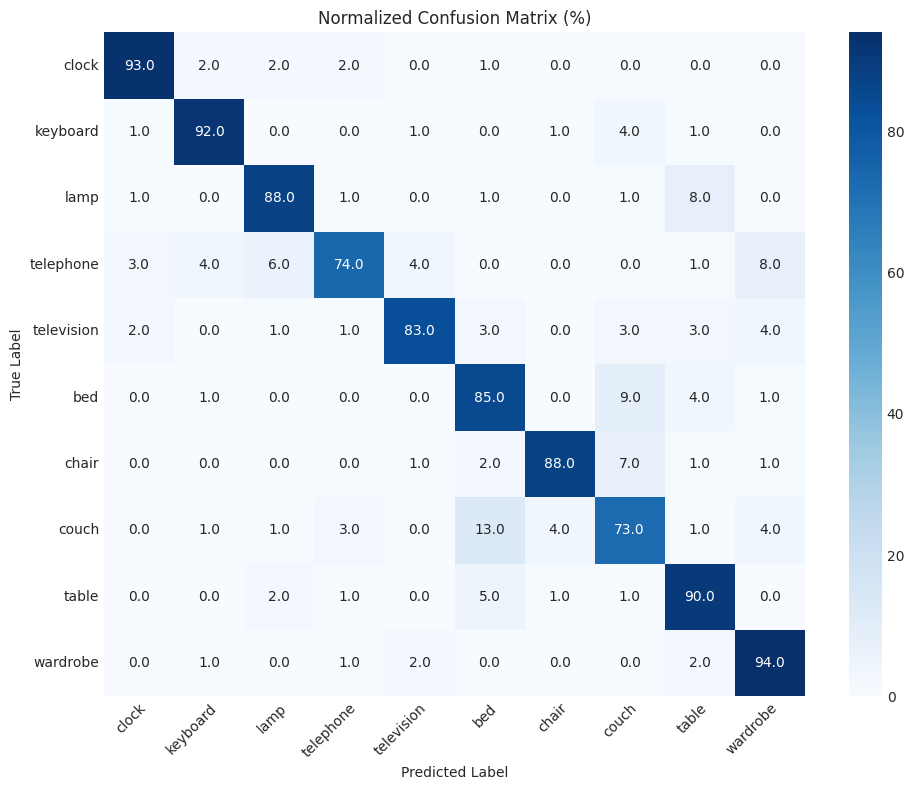


Optimized Model Metrics (pipeline/pipeline_a_prune_fx_ptq/step01_post_pruning):
Accuracy: 86.00%
Model Size: 5.96 MB
CPU Inference Time: 139.00 ms (7.19 FPS)
CUDA Inference Time: 5.23 ms (191.10 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:27<00:00,  3.40s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:30<00:00,  3.81s/it]


Model comparison plot saved to ../results/pipeline/pipeline_a_prune_fx_ptq/step01_post_pruning/comparison.png


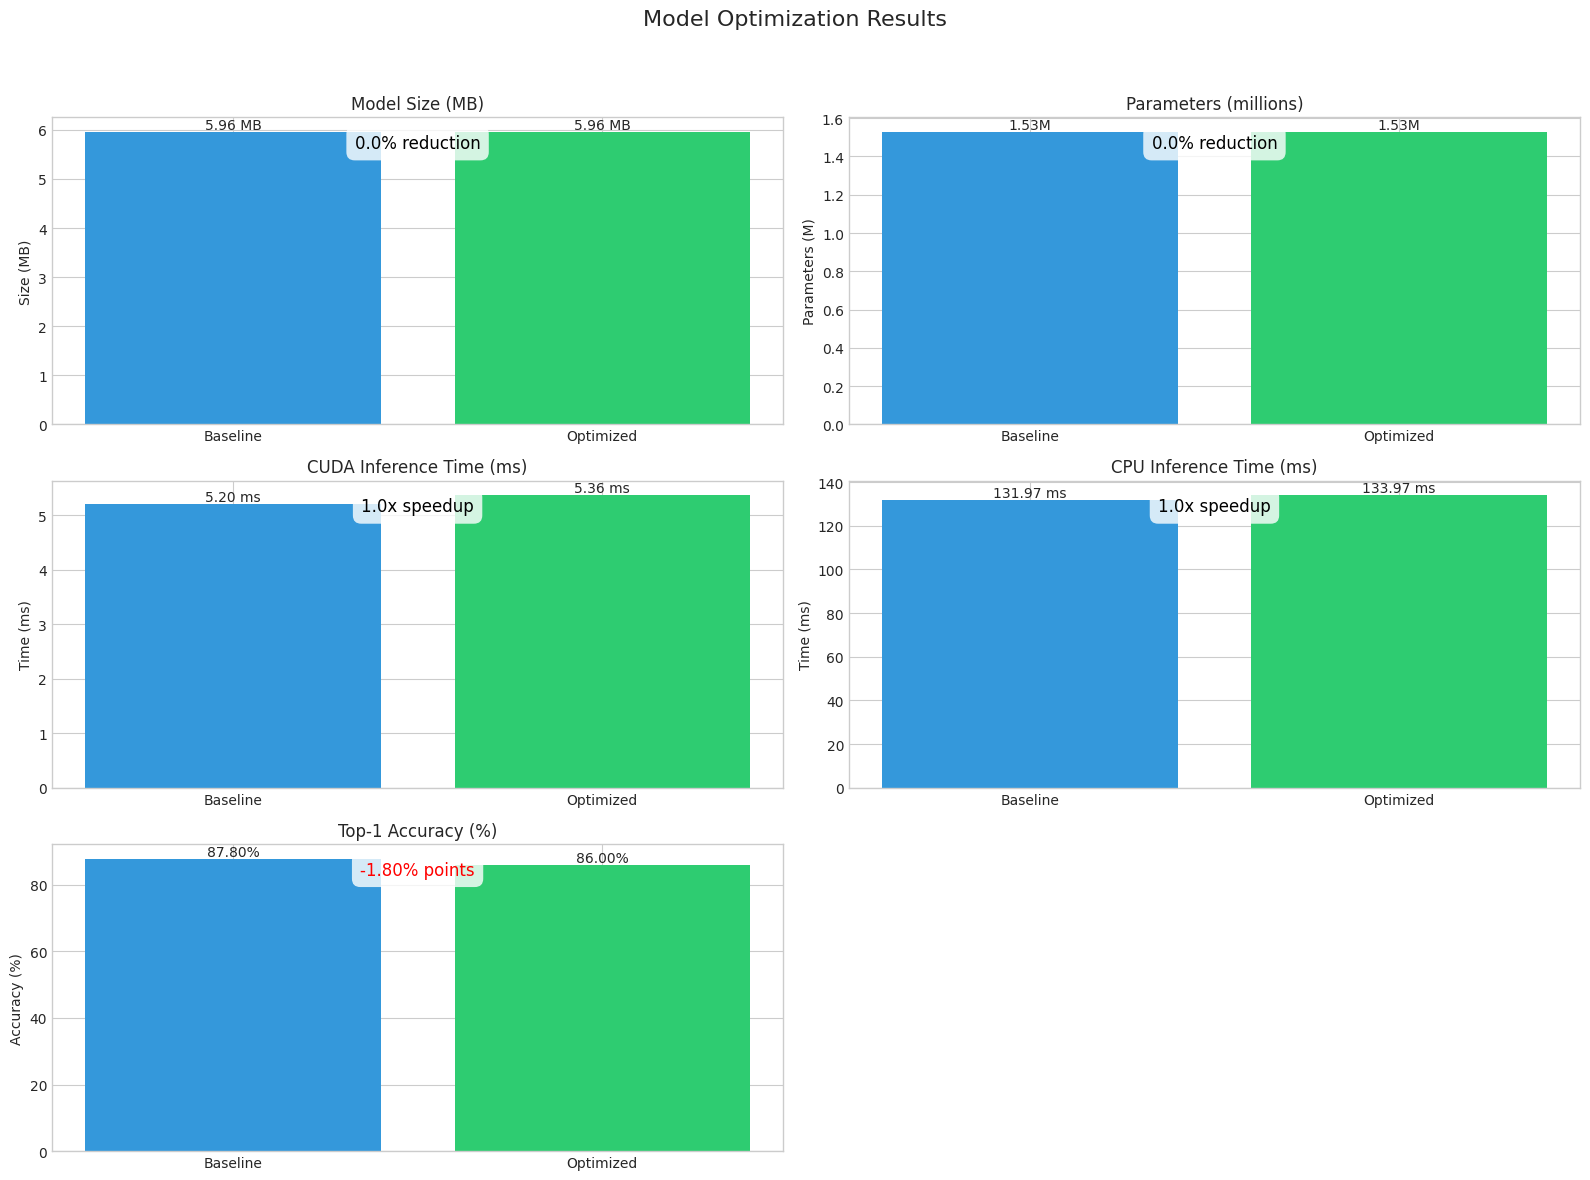


pipeline/pipeline_a_prune_fx_ptq/step01_post_pruning Results:
Model Size: 5.96 MB (0.0% reduction)
Parameters: 1,528,106 (0.0% reduction)
CPU Inference Time: 133.97 ms (1.0x speedup)
CUDA Inference Time: 5.36 ms (1.0x speedup)
Accuracy: 86.00% (-1.80% change)
Requirements met: False
Completed post_pruning in 272.73s

--------------------------------------------------
Step 2: graph_fx
--------------------------------------------------


Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:32<00:00,  4.09s/it]


Baseline metrics saved at ../results/pipeline/pipeline_a_prune_fx_ptq/step02_graph_fx/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:33<00:00,  4.14s/it]


Confusion matrix saved to ../results/pipeline/pipeline_a_prune_fx_ptq/step02_graph_fx/confusion_matrix.png


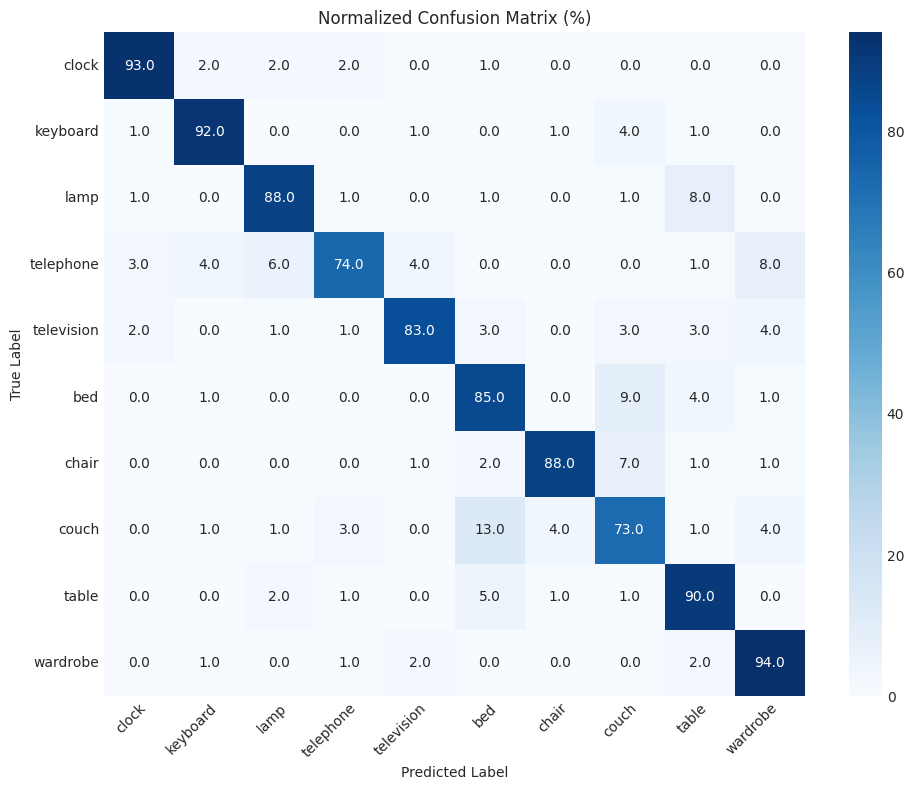


Optimized Model Metrics (pipeline/pipeline_a_prune_fx_ptq/step02_graph_fx):
Accuracy: 86.00%
Model Size: 5.85 MB
CPU Inference Time: 151.01 ms (6.62 FPS)
CUDA Inference Time: 4.02 ms (248.72 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:34<00:00,  4.27s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:33<00:00,  4.21s/it]


Model comparison plot saved to ../results/pipeline/pipeline_a_prune_fx_ptq/step02_graph_fx/comparison.png


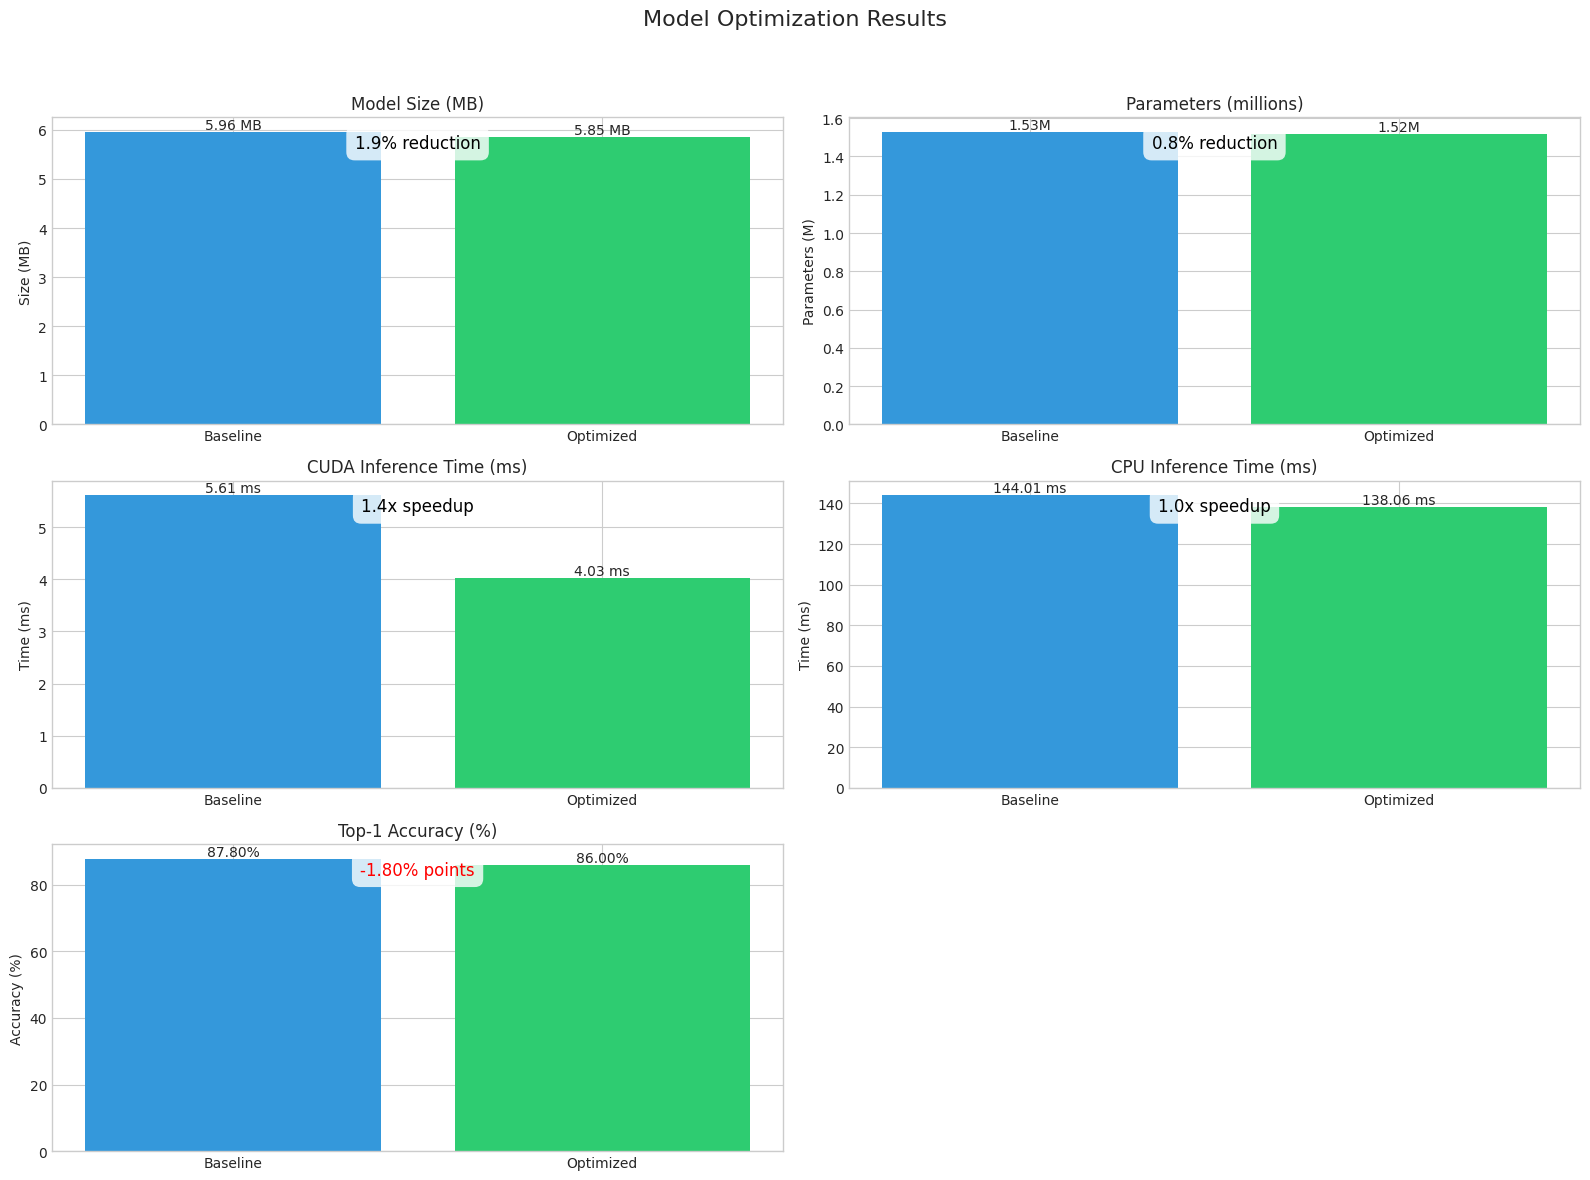


pipeline/pipeline_a_prune_fx_ptq/step02_graph_fx Results:
Model Size: 5.85 MB (1.9% reduction)
Parameters: 1,515,994 (0.8% reduction)
CPU Inference Time: 138.06 ms (1.0x speedup)
CUDA Inference Time: 4.03 ms (1.4x speedup)
Accuracy: 86.00% (-1.80% change)
Requirements met: False
Completed graph_fx in 286.99s

--------------------------------------------------
Step 3: static_quant
--------------------------------------------------

Applying static quantization...


/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


Calibrating on 10 batch(es)...


Calibration: 100%|██████████| 10/10 [01:11<00:00,  7.17s/it]



Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:16<00:00,  2.01s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Baseline metrics saved at ../results/pipeline/pipeline_a_prune_fx_ptq/step03_static_quant/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:16<00:00,  2.02s/it]


Confusion matrix saved to ../results/pipeline/pipeline_a_prune_fx_ptq/step03_static_quant/confusion_matrix.png


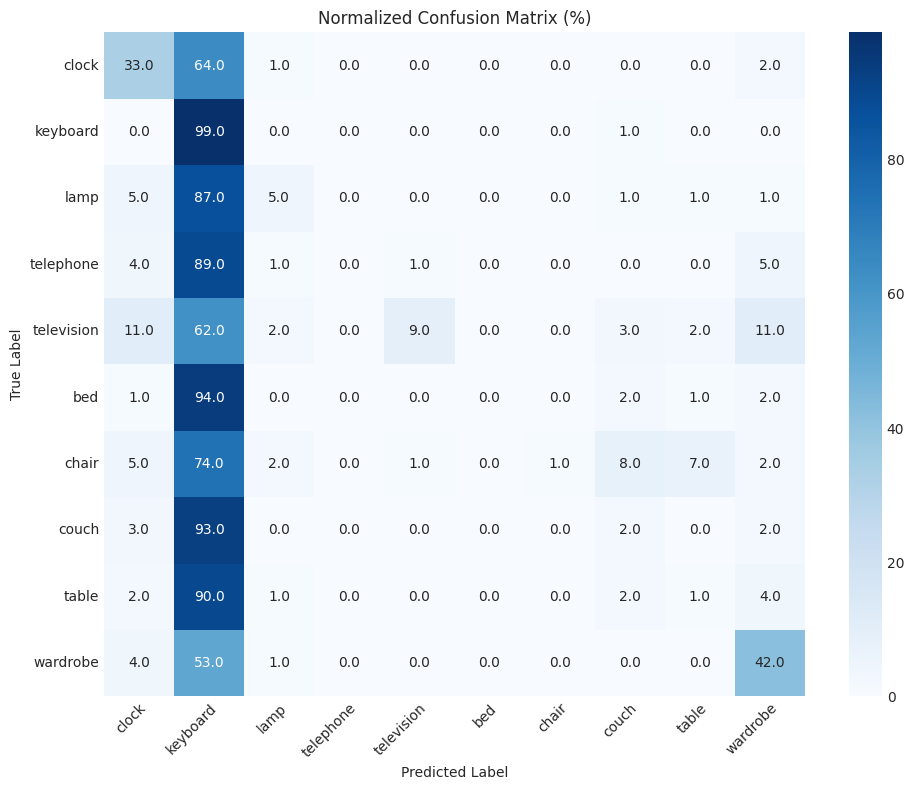


Optimized Model Metrics (pipeline/pipeline_a_prune_fx_ptq/step03_static_quant):
Accuracy: 18.90%
Model Size: 1.75 MB
CPU Inference Time: 82.08 ms (12.18 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:30<00:00,  3.82s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:15<00:00,  1.94s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Model comparison plot saved to ../results/pipeline/pipeline_a_prune_fx_ptq/step03_static_quant/comparison.png


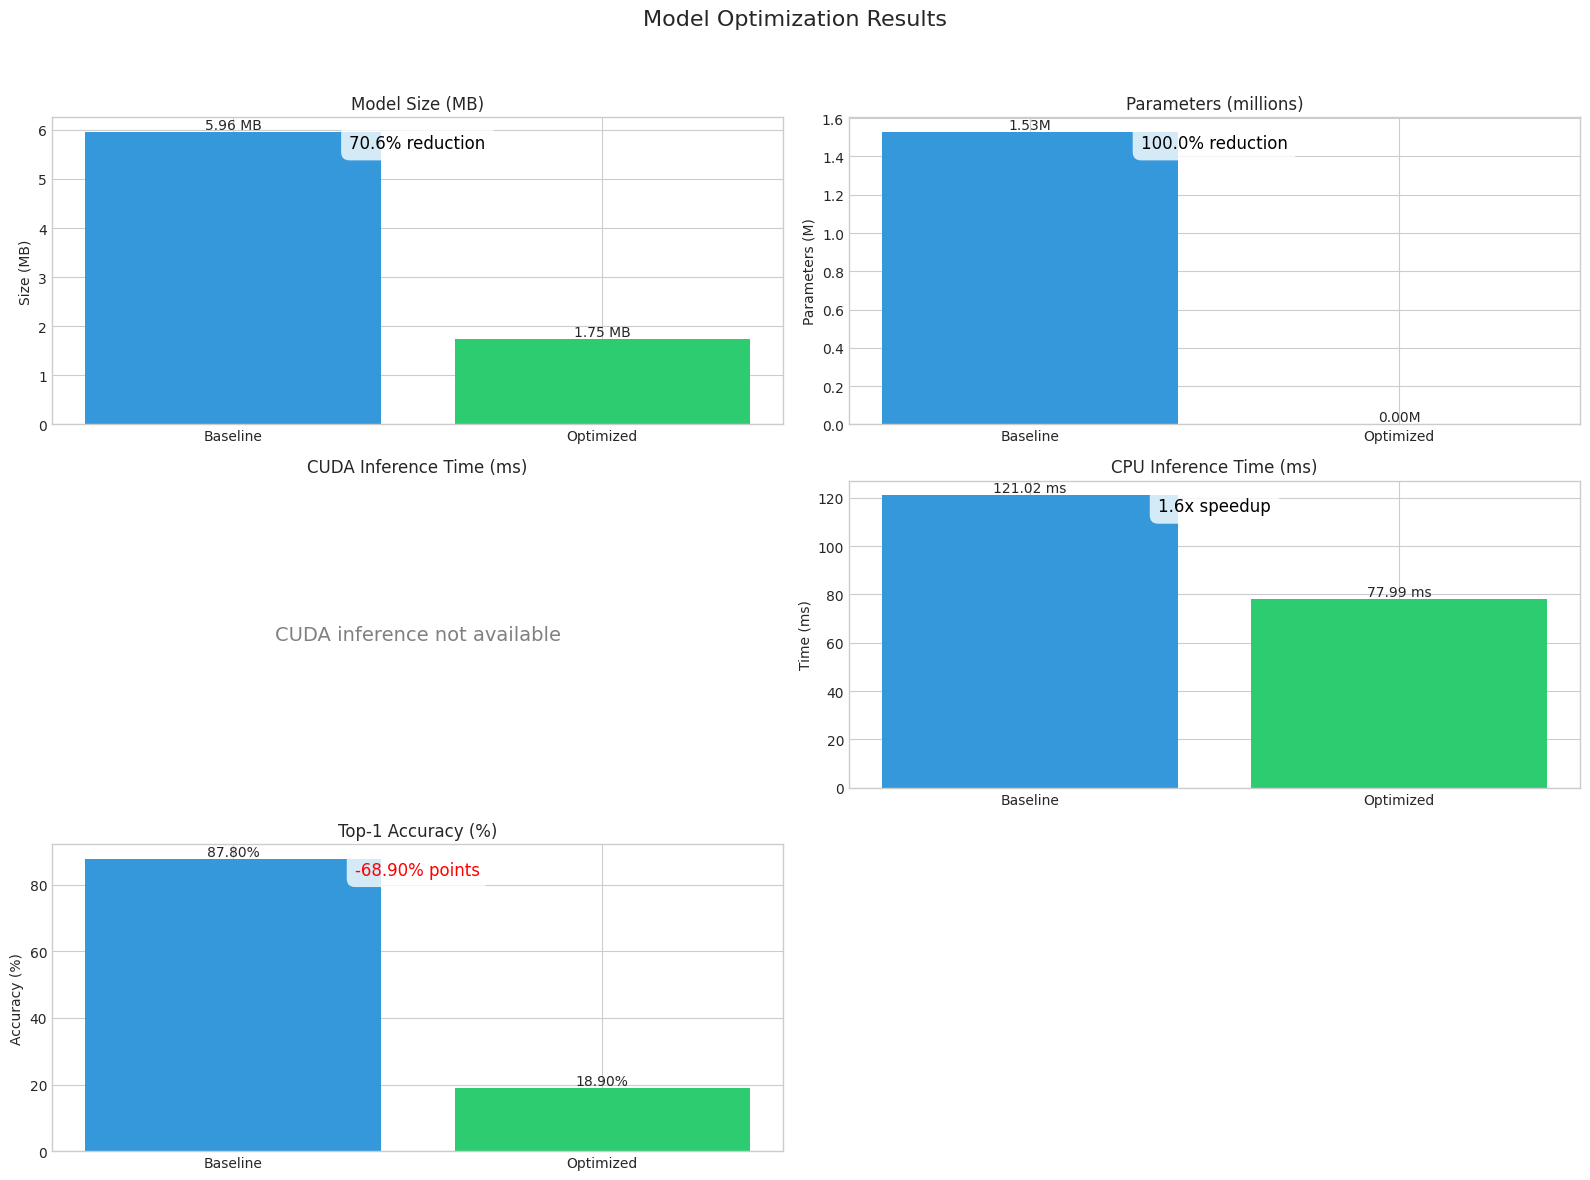


pipeline/pipeline_a_prune_fx_ptq/step03_static_quant Results:
Model Size: 1.75 MB (70.6% reduction)
Parameters: 0 (100.0% reduction)
CPU Inference Time: 77.99 ms (1.6x speedup)
Accuracy: 18.90% (-68.90% change)
Requirements met: False
Completed static_quant in 252.54s
Model saved to ../models/pipeline/pipeline_a_prune_fx_ptq/model.pth

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:16<00:00,  2.11s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Baseline metrics saved at ../results/pipeline/pipeline_a_prune_fx_ptq/final/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:15<00:00,  1.98s/it]


Confusion matrix saved to ../results/pipeline/pipeline_a_prune_fx_ptq/final/confusion_matrix.png


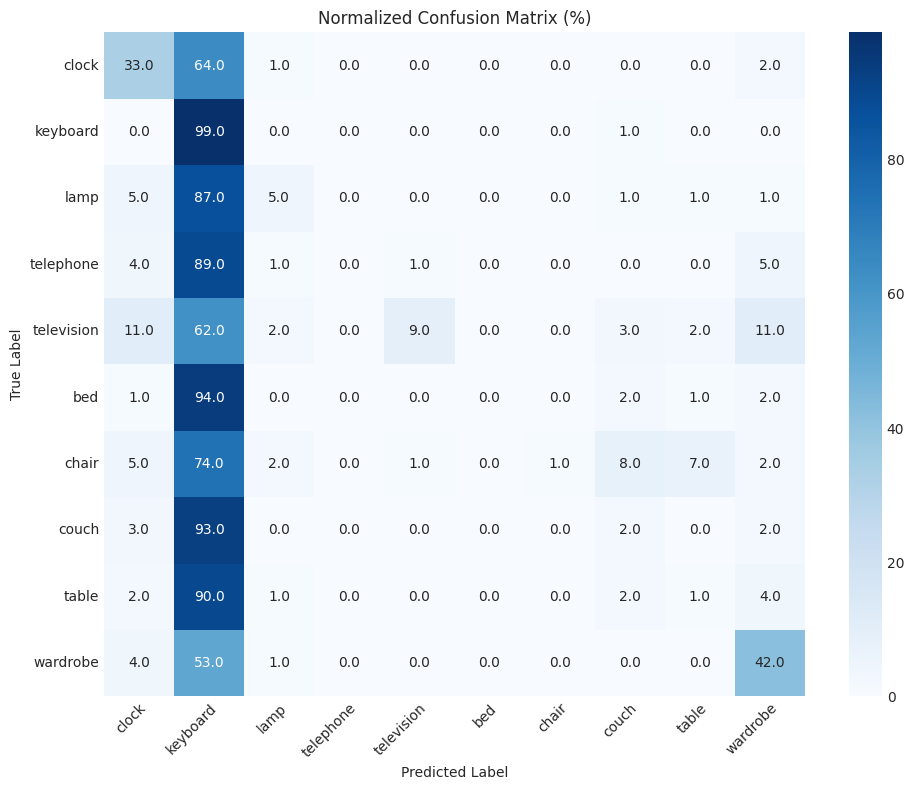


Optimized Model Metrics (pipeline/pipeline_a_prune_fx_ptq/final):
Accuracy: 18.90%
Model Size: 1.75 MB
CPU Inference Time: 85.98 ms (11.63 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:28<00:00,  3.61s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:17<00:00,  2.14s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Model comparison plot saved to ../results/pipeline/pipeline_a_prune_fx_ptq/final/comparison.png


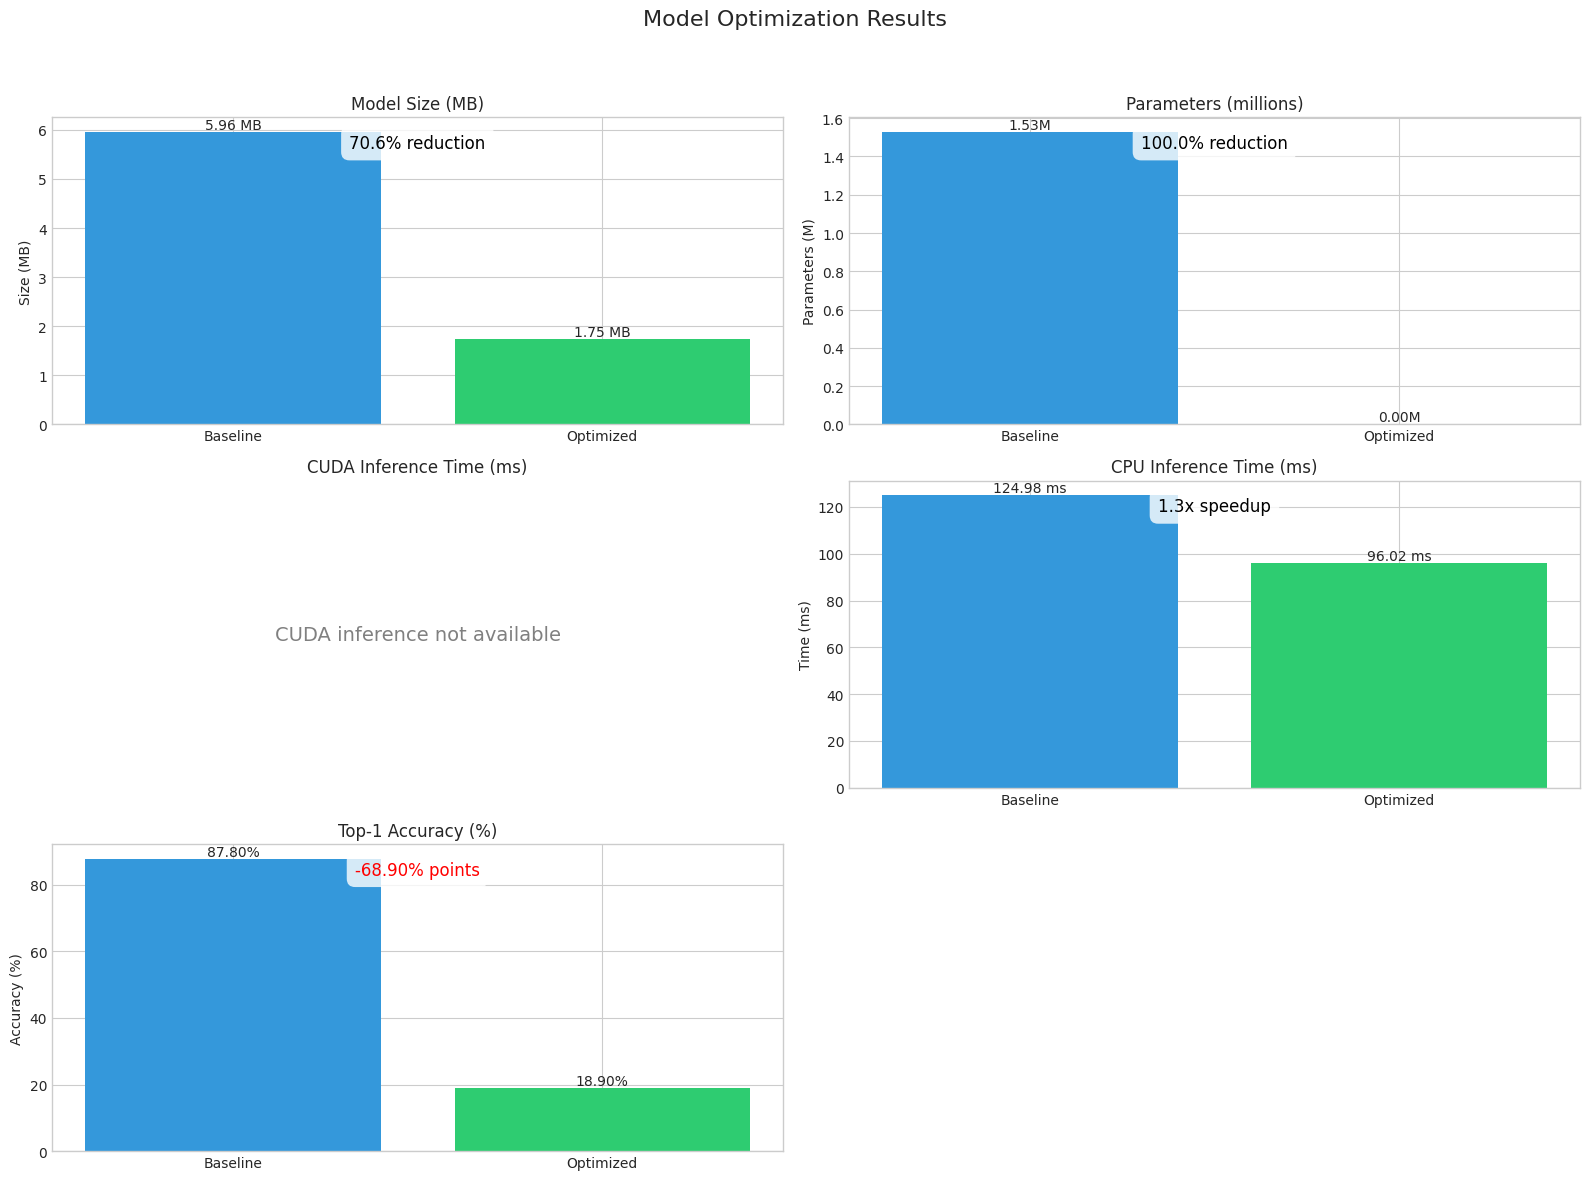


pipeline/pipeline_a_prune_fx_ptq/final Results:
Model Size: 1.75 MB (70.6% reduction)
Parameters: 0 (100.0% reduction)
CPU Inference Time: 96.02 ms (1.3x speedup)
Accuracy: 18.90% (-68.90% change)
Requirements met: False

Pipeline pipeline_a_prune_fx_ptq completed
Final model path: ../models/pipeline/pipeline_a_prune_fx_ptq/model.pth



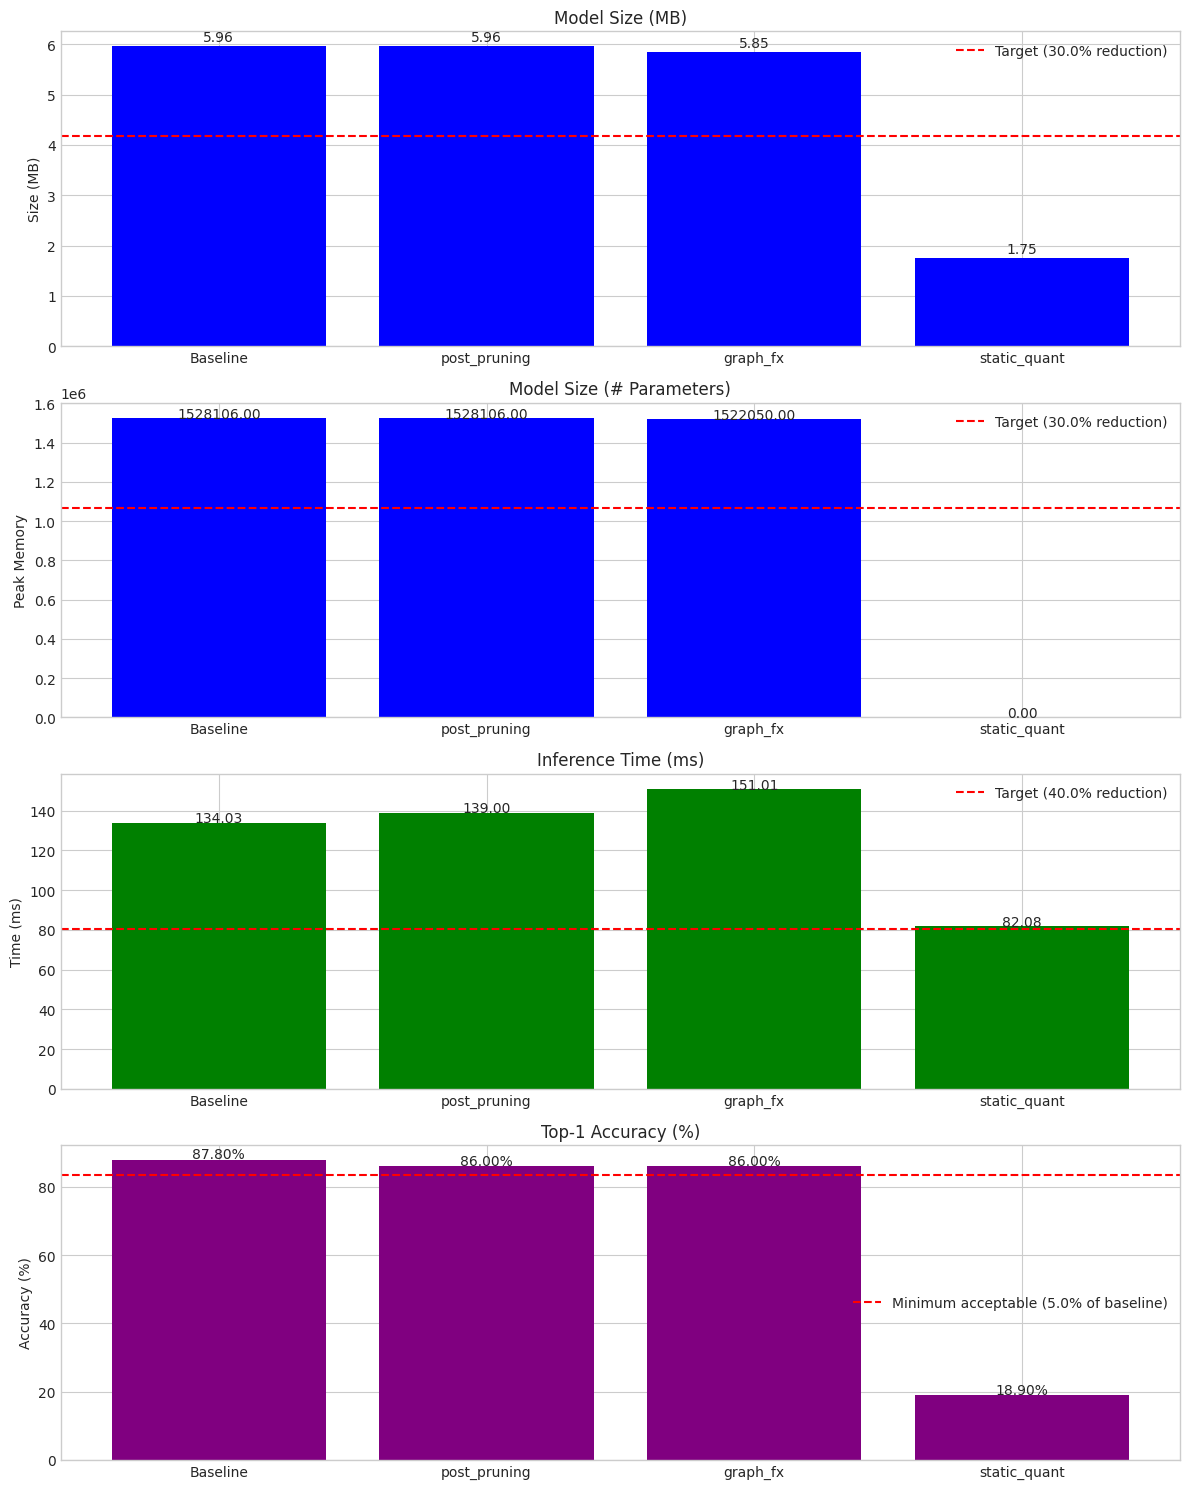


Pipeline pipeline_a_prune_fx_ptq Results Summary

Model Size (MB):
  Baseline: 5.96 MB
  Final: 1.75 MB
  Reduction: 70.63%
  Meets target (30.0% reduction)

Model Size (# Parameters):
  Baseline: 1528106.00 MB
  Final: 0.00 MB
  Reduction: 100.00%
  Meets target (30.0% reduction)

Inference Time (CPU):
  Baseline: 134.03 ms
  Final: 82.08 ms
  Reduction: 38.76%
  Does not meet target (Goal: 80.42 ms)

Accuracy:
  Baseline: 87.80%
  Final: 18.90%
  Change: -78.47%
  Does not meet target (Goal: >=83.41%)

Overall Assessment:
  Pipeline does not meet all requirements

Running pipeline: pipeline_b_distill_fx_ptq


--------------------------------------------------
Step 1: distillation
--------------------------------------------------

Student parameters: 444,706
Teacher parameters: 1,528,106
Training with knowledge distillation for 20 epochs
Temperature: 4.0, Alpha: 0.7


Epoch 1/20 [Test]: 100%|██████████| 8/8 [00:00<00:00, 10.12it/s, loss=3.52, acc=26]  


Epoch 1/20 - Train Loss: 10.8103, Train Acc: 20.38%, Test Loss: 2.1970, Test Acc: 26.00%, LR: 0.000994, Time: 10.57s
New best student model! Saving... (26.00%)
Model saved to ../models/pipeline/pipeline_b_distill_fx_ptq/checkpoints/pipeline_b_distill_fx_ptq_distill.pth


Epoch 2/20 [Test]: 100%|██████████| 8/8 [00:00<00:00, 11.61it/s, loss=2.01, acc=33.8]


Epoch 2/20 - Train Loss: 9.4243, Train Acc: 29.24%, Test Loss: 2.0078, Test Acc: 33.80%, LR: 0.000976, Time: 9.28s
New best student model! Saving... (33.80%)
Model saved to ../models/pipeline/pipeline_b_distill_fx_ptq/checkpoints/pipeline_b_distill_fx_ptq_distill.pth


...

Epoch 20/20 - Train Loss: 3.7163, Train Acc: 69.32%, Test Loss: 1.4805, Test Acc: 62.80%, LR: 0.000000, Time: 8.81s
Distillation completed. Best student accuracy: 63.00%
Best student model saved as '../models/pipeline/pipeline_b_distill_fx_ptq/checkpoints/pipeline_b_distill_fx_ptq_distill.pth' at epoch 19

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:24<00:00,  3.08s/it]


Baseline metrics saved at ../results/pipeline/pipeline_b_distill_fx_ptq/step01_distillation/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:26<00:00,  3.28s/it]


Confusion matrix saved to ../results/pipeline/pipeline_b_distill_fx_ptq/step01_distillation/confusion_matrix.png


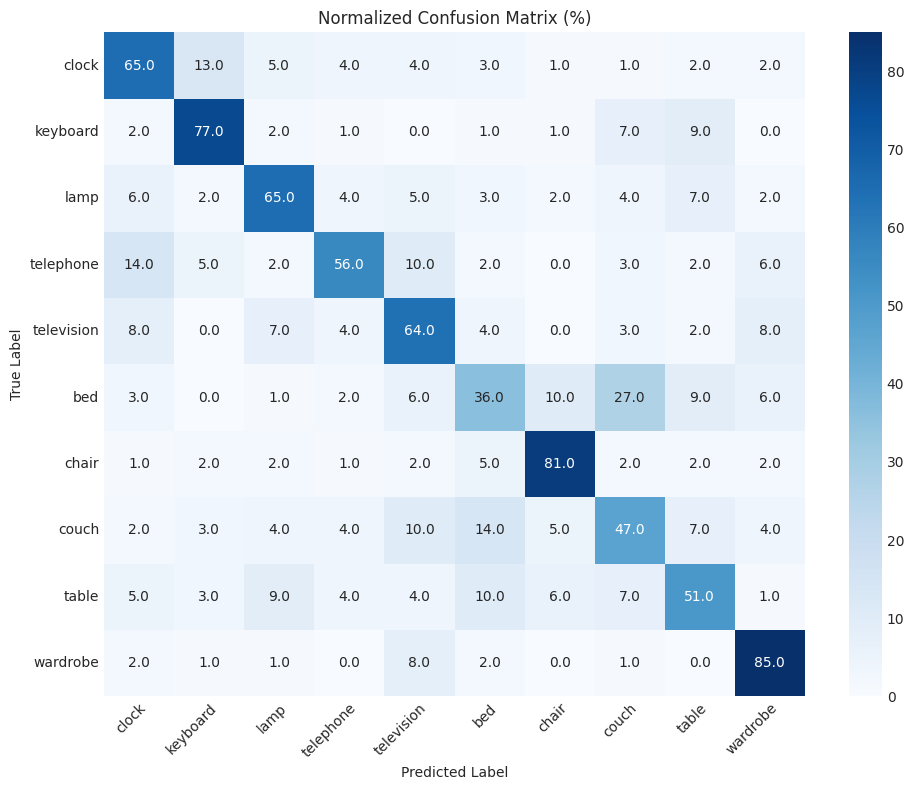


Optimized Model Metrics (pipeline/pipeline_b_distill_fx_ptq/step01_distillation):
Accuracy: 62.70%
Model Size: 1.80 MB
CPU Inference Time: 173.93 ms (5.75 FPS)
CUDA Inference Time: 5.45 ms (183.60 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:28<00:00,  3.61s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:21<00:00,  2.71s/it]


Model comparison plot saved to ../results/pipeline/pipeline_b_distill_fx_ptq/step01_distillation/comparison.png


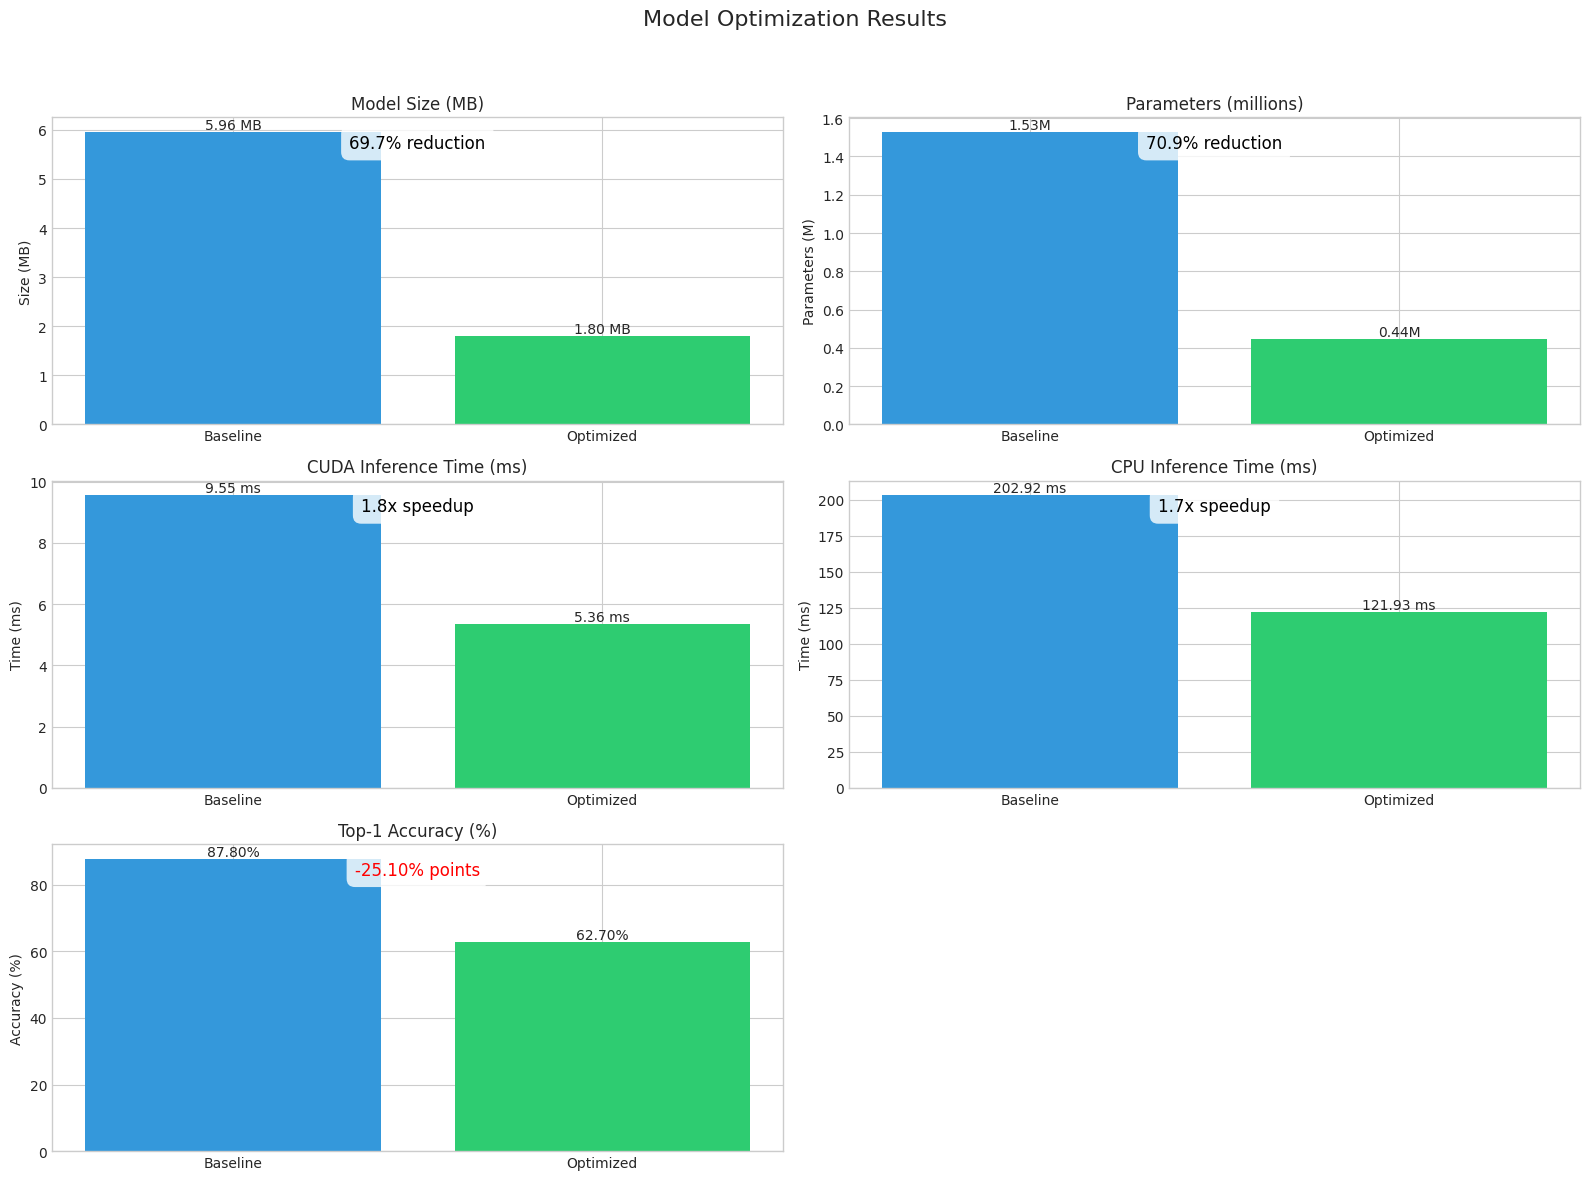


pipeline/pipeline_b_distill_fx_ptq/step01_distillation Results:
Model Size: 1.80 MB (69.7% reduction)
Parameters: 444,706 (70.9% reduction)
CPU Inference Time: 121.93 ms (1.7x speedup)
CUDA Inference Time: 5.36 ms (1.8x speedup)
Accuracy: 62.70% (-25.10% change)
Requirements met: False
Completed distillation in 438.17s

--------------------------------------------------
Step 2: graph_fx
--------------------------------------------------


Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:19<00:00,  2.40s/it]


Baseline metrics saved at ../results/pipeline/pipeline_b_distill_fx_ptq/step02_graph_fx/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:22<00:00,  2.75s/it]


Confusion matrix saved to ../results/pipeline/pipeline_b_distill_fx_ptq/step02_graph_fx/confusion_matrix.png


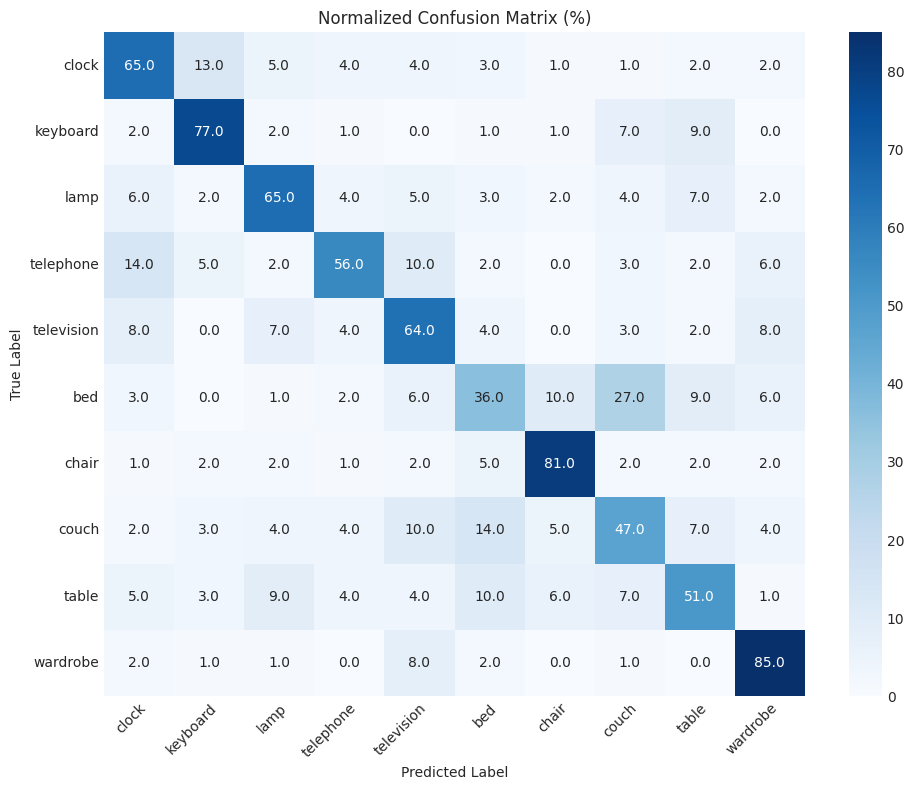


Optimized Model Metrics (pipeline/pipeline_b_distill_fx_ptq/step02_graph_fx):
Accuracy: 62.70%
Model Size: 1.72 MB
CPU Inference Time: 135.98 ms (7.35 FPS)
CUDA Inference Time: 4.78 ms (209.15 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:30<00:00,  3.77s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:23<00:00,  2.89s/it]


Model comparison plot saved to ../results/pipeline/pipeline_b_distill_fx_ptq/step02_graph_fx/comparison.png


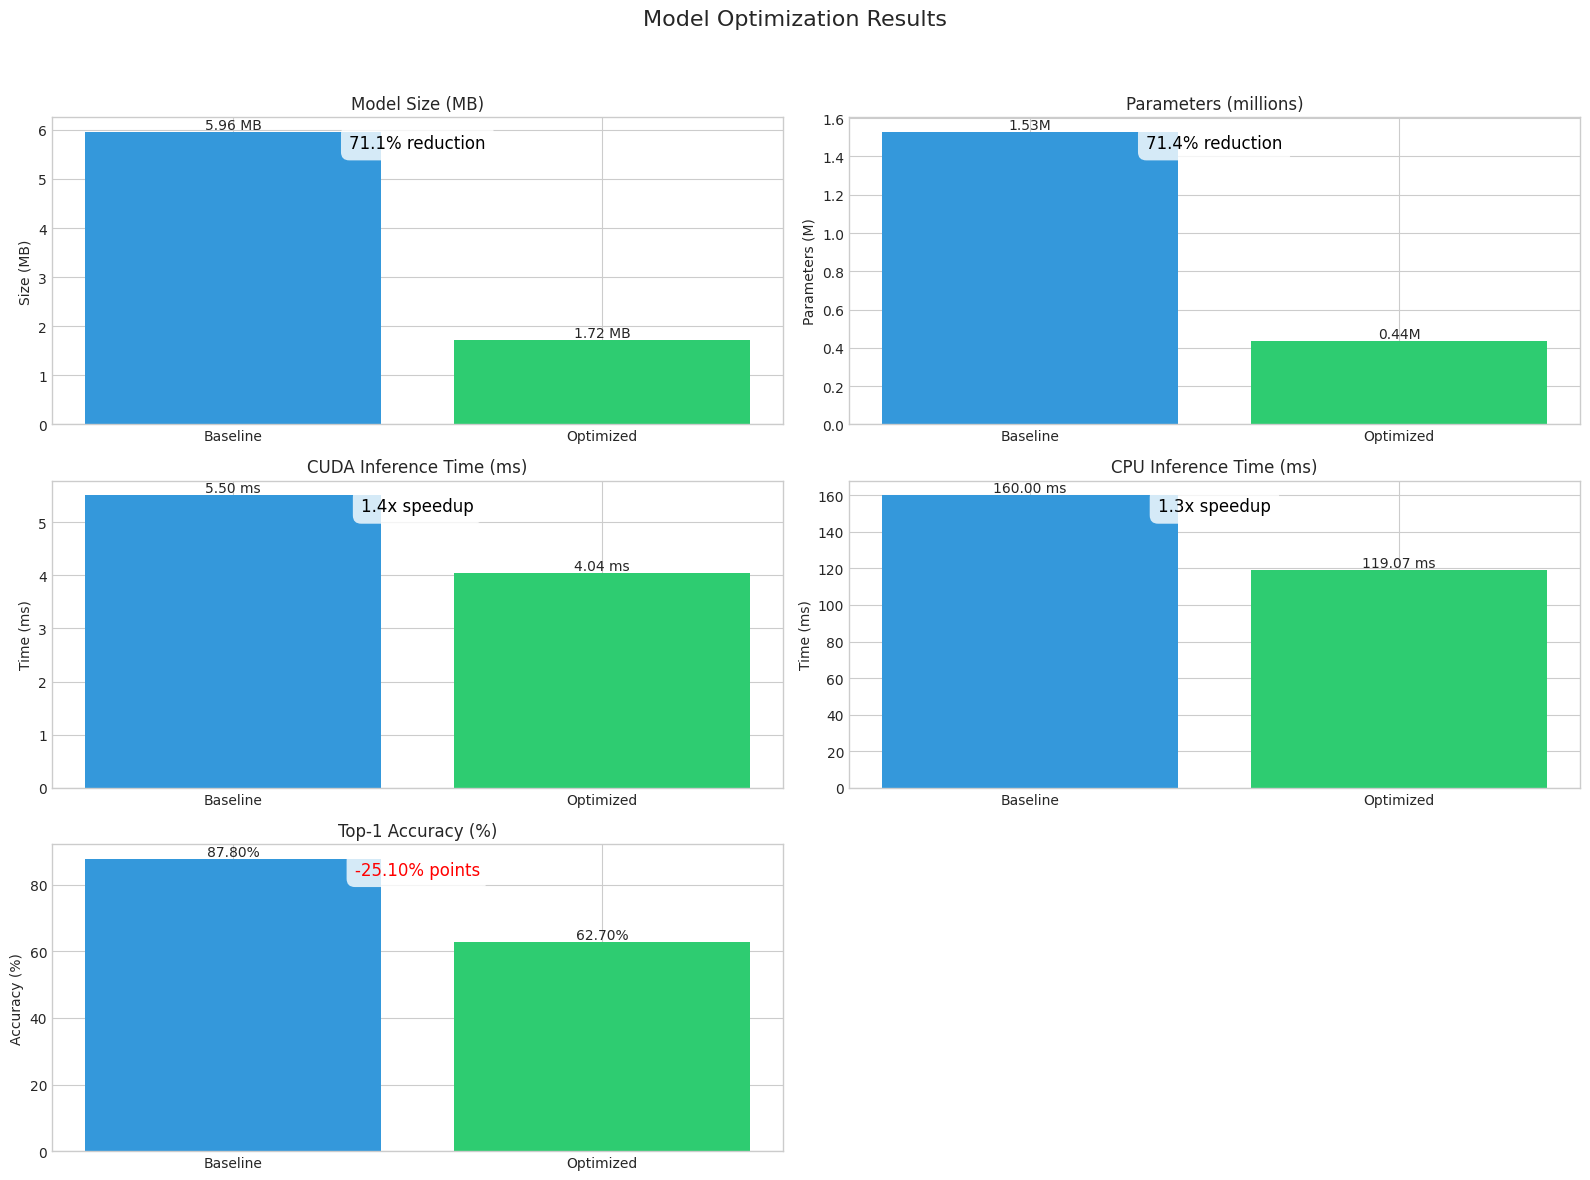


pipeline/pipeline_b_distill_fx_ptq/step02_graph_fx Results:
Model Size: 1.72 MB (71.1% reduction)
Parameters: 437,410 (71.4% reduction)
CPU Inference Time: 119.07 ms (1.3x speedup)
CUDA Inference Time: 4.04 ms (1.4x speedup)
Accuracy: 62.70% (-25.10% change)
Requirements met: False
Completed graph_fx in 220.22s

--------------------------------------------------
Step 3: static_quant
--------------------------------------------------

Applying static quantization...


/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


Calibrating on 10 batch(es)...


Calibration: 100%|██████████| 10/10 [00:59<00:00,  5.94s/it]



Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:16<00:00,  2.03s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Baseline metrics saved at ../results/pipeline/pipeline_b_distill_fx_ptq/step03_static_quant/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:16<00:00,  2.09s/it]


Confusion matrix saved to ../results/pipeline/pipeline_b_distill_fx_ptq/step03_static_quant/confusion_matrix.png


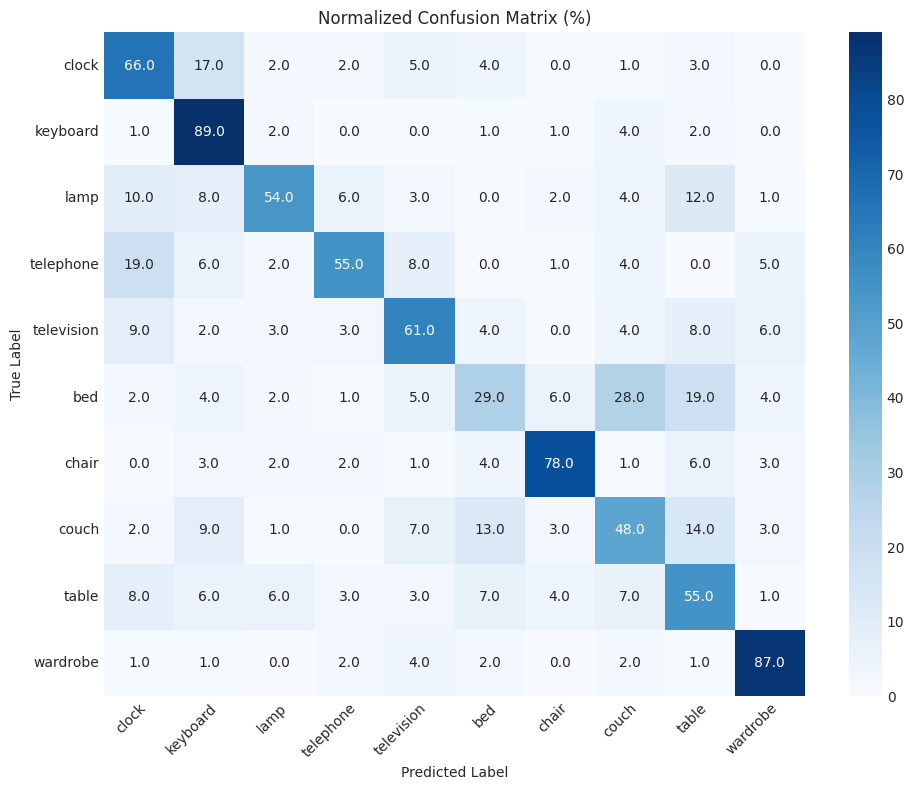


Optimized Model Metrics (pipeline/pipeline_b_distill_fx_ptq/step03_static_quant):
Accuracy: 62.10%
Model Size: 0.64 MB
CPU Inference Time: 110.03 ms (9.09 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:34<00:00,  4.27s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:16<00:00,  2.00s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Model comparison plot saved to ../results/pipeline/pipeline_b_distill_fx_ptq/step03_static_quant/comparison.png


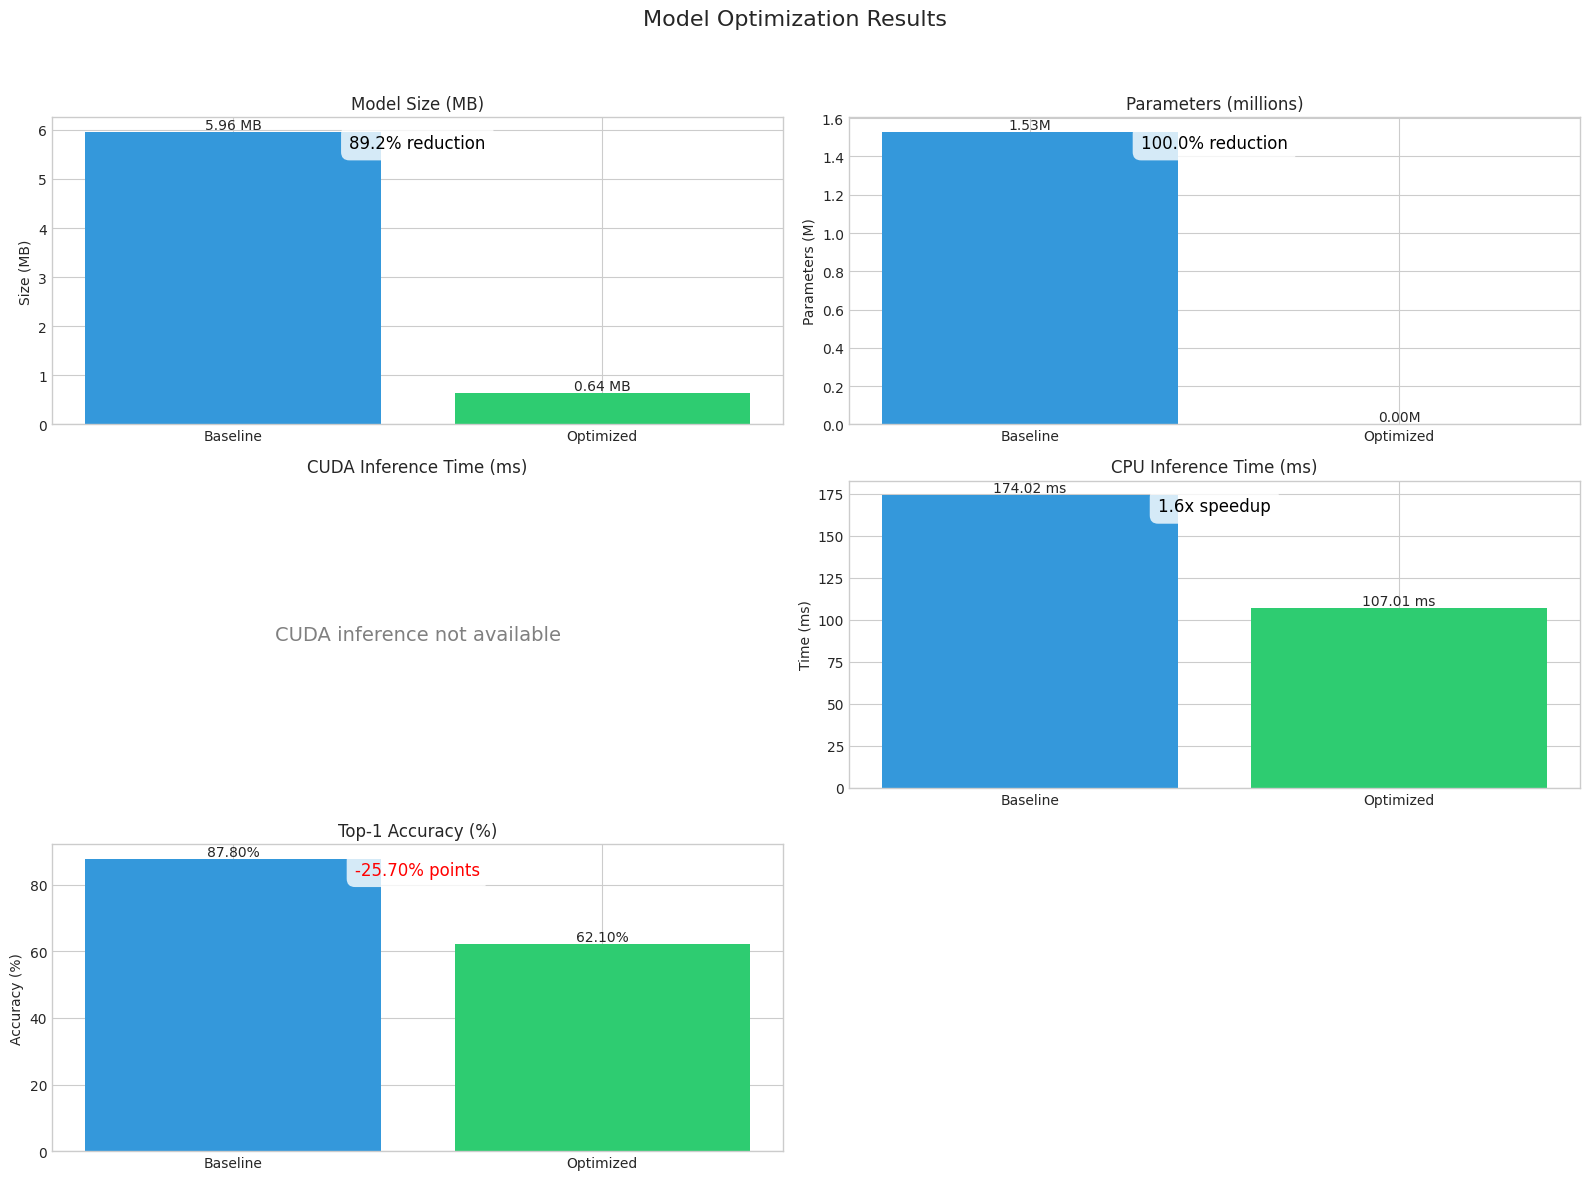


pipeline/pipeline_b_distill_fx_ptq/step03_static_quant Results:
Model Size: 0.64 MB (89.2% reduction)
Parameters: 0 (100.0% reduction)
CPU Inference Time: 107.01 ms (1.6x speedup)
Accuracy: 62.10% (-25.70% change)
Requirements met: False
Completed static_quant in 265.23s
Model saved to ../models/pipeline/pipeline_b_distill_fx_ptq/model.pth

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:16<00:00,  2.12s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Baseline metrics saved at ../results/pipeline/pipeline_b_distill_fx_ptq/final/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:17<00:00,  2.18s/it]


Confusion matrix saved to ../results/pipeline/pipeline_b_distill_fx_ptq/final/confusion_matrix.png


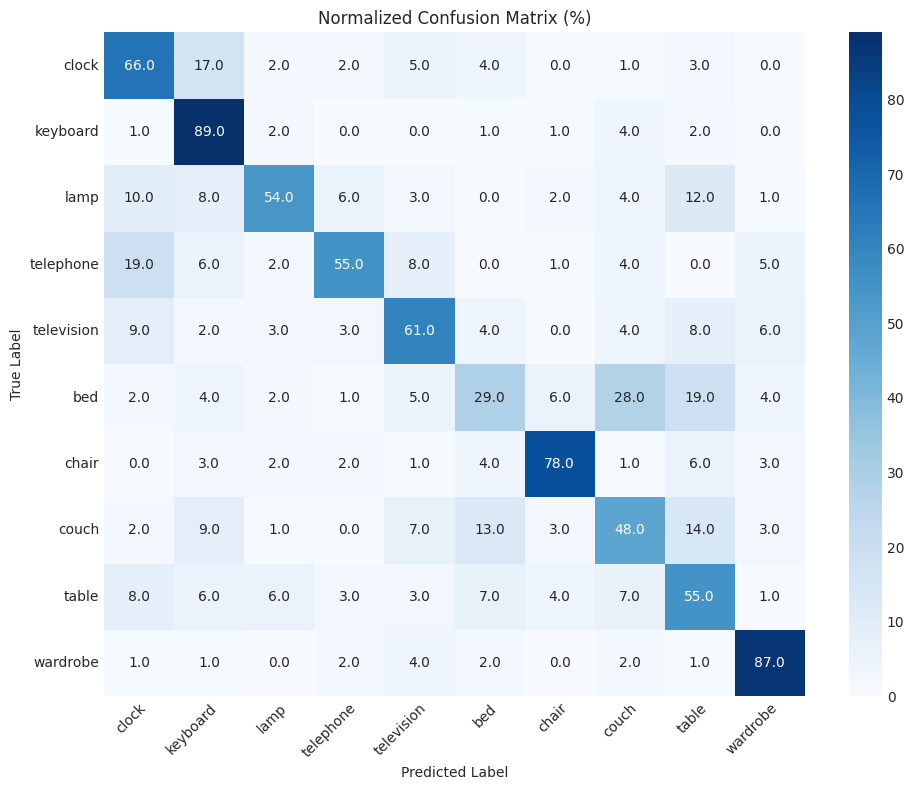


Optimized Model Metrics (pipeline/pipeline_b_distill_fx_ptq/final):
Accuracy: 62.10%
Model Size: 0.64 MB
CPU Inference Time: 118.99 ms (8.40 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:30<00:00,  3.79s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:17<00:00,  2.13s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Model comparison plot saved to ../results/pipeline/pipeline_b_distill_fx_ptq/final/comparison.png


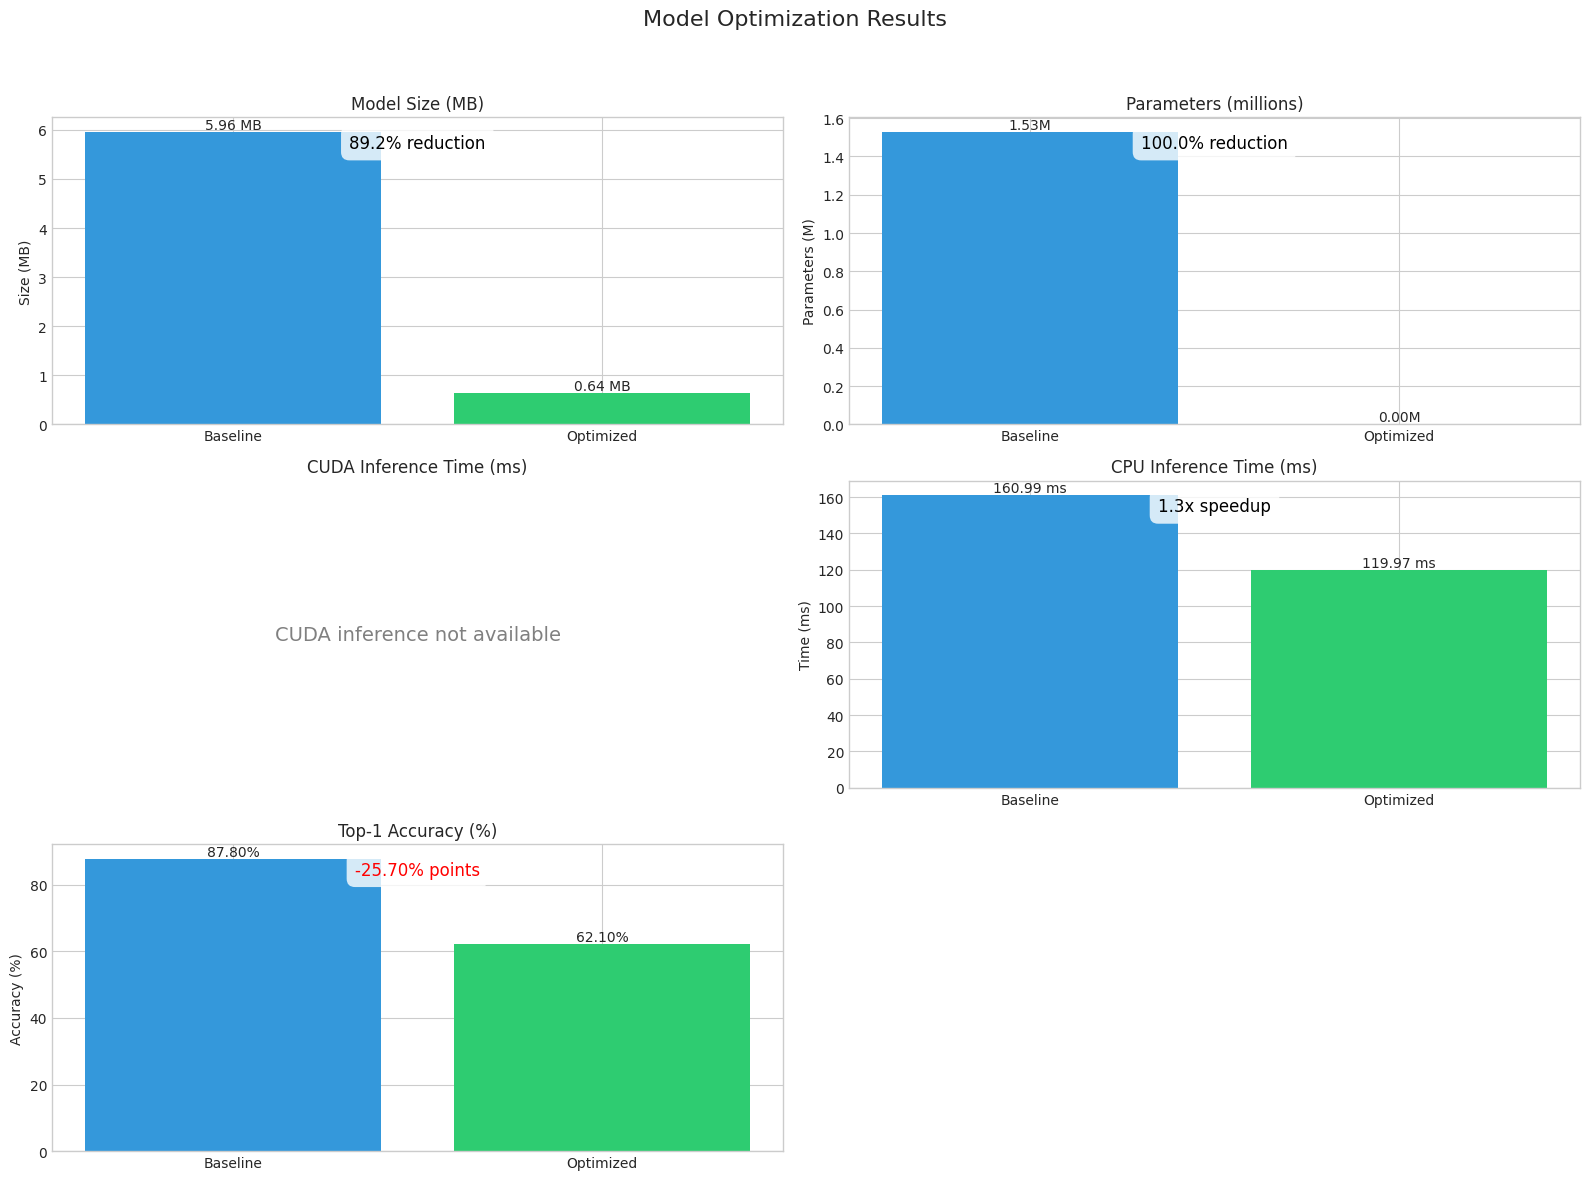


pipeline/pipeline_b_distill_fx_ptq/final Results:
Model Size: 0.64 MB (89.2% reduction)
Parameters: 0 (100.0% reduction)
CPU Inference Time: 119.97 ms (1.3x speedup)
Accuracy: 62.10% (-25.70% change)
Requirements met: False

Pipeline pipeline_b_distill_fx_ptq completed
Final model path: ../models/pipeline/pipeline_b_distill_fx_ptq/model.pth



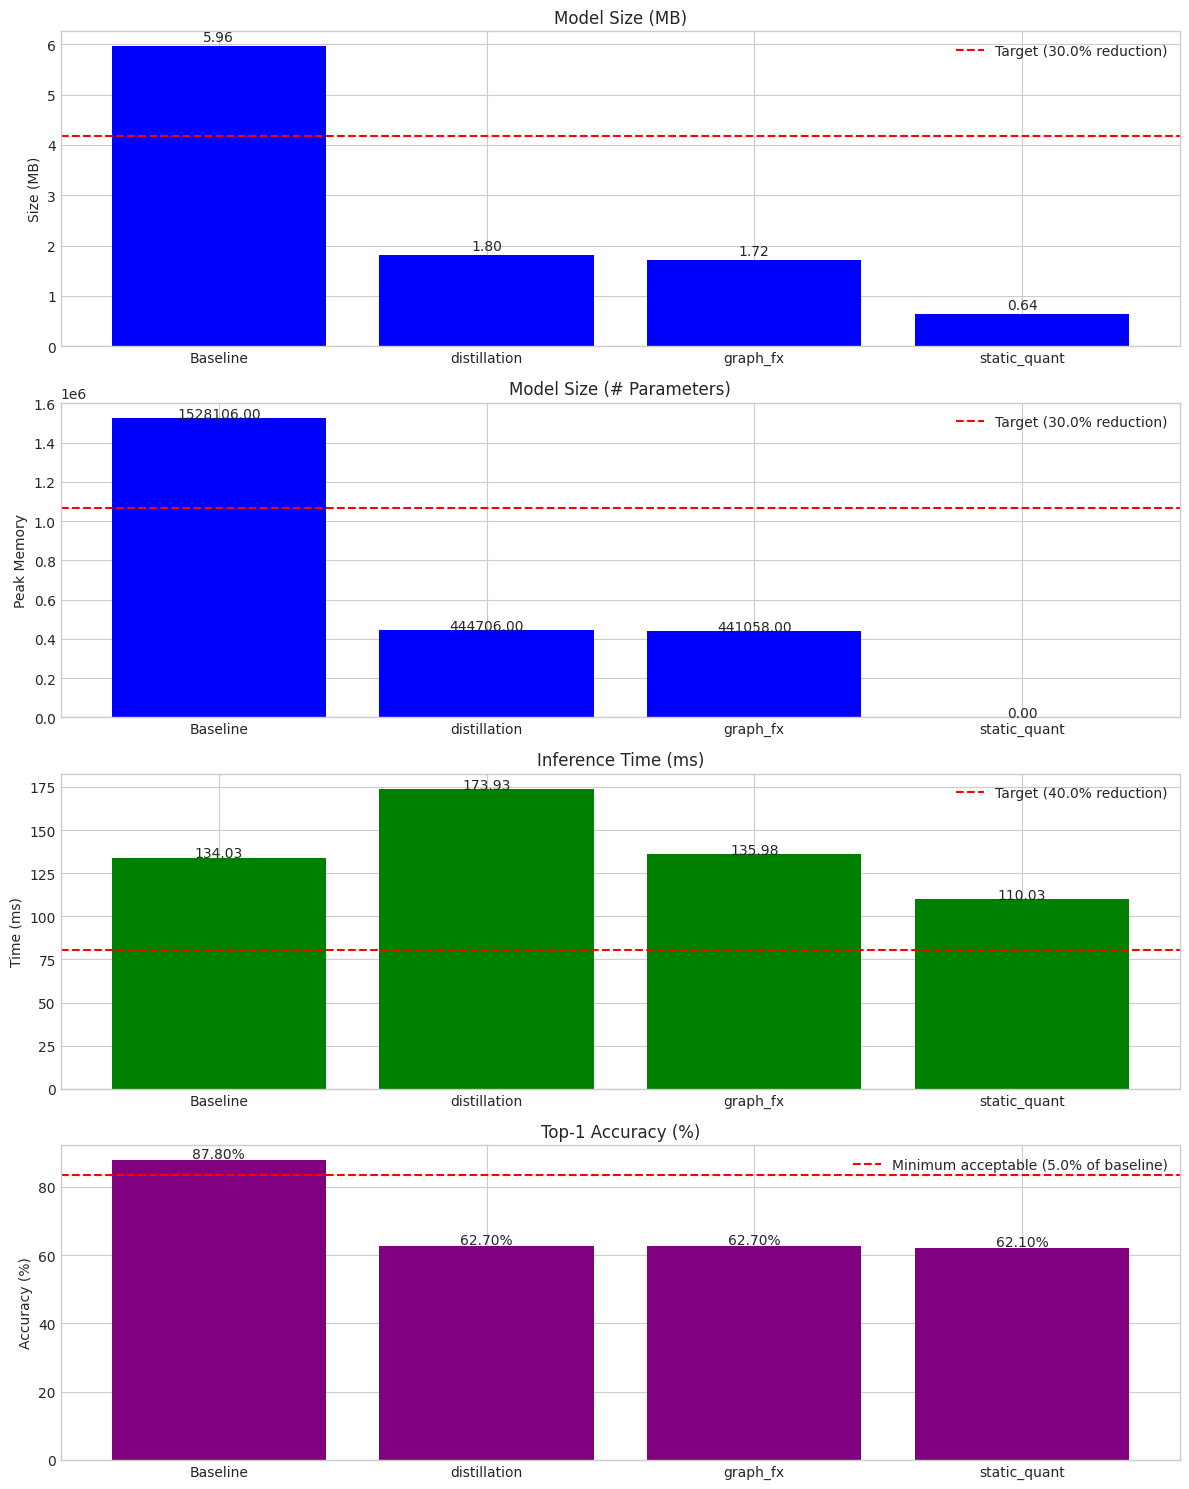


Pipeline pipeline_b_distill_fx_ptq Results Summary

Model Size (MB):
  Baseline: 5.96 MB
  Final: 0.64 MB
  Reduction: 89.24%
  Meets target (30.0% reduction)

Model Size (# Parameters):
  Baseline: 1528106.00 MB
  Final: 0.00 MB
  Reduction: 100.00%
  Meets target (30.0% reduction)

Inference Time (CPU):
  Baseline: 134.03 ms
  Final: 110.03 ms
  Reduction: 17.91%
  Does not meet target (Goal: 80.42 ms)

Accuracy:
  Baseline: 87.80%
  Final: 62.10%
  Change: -29.27%
  Does not meet target (Goal: >=83.41%)

Overall Assessment:
  Pipeline does not meet all requirements

Running pipeline: pipeline_c_distill_prune_fx_ptq


--------------------------------------------------
Step 1: distillation
--------------------------------------------------

Student parameters: 444,706
Teacher parameters: 1,528,106
Training with knowledge distillation for 20 epochs
Temperature: 4.0, Alpha: 0.7


Epoch 1/20 [Test]: 100%|██████████| 8/8 [00:00<00:00, 10.10it/s, loss=2.14, acc=25.7]


Epoch 1/20 - Train Loss: 10.6232, Train Acc: 20.76%, Test Loss: 2.1406, Test Acc: 25.70%, LR: 0.000994, Time: 10.32s
New best student model! Saving... (25.70%)
Model saved to ../models/pipeline/pipeline_c_distill_prune_fx_ptq/checkpoints/pipeline_c_distill_prune_fx_ptq_distill.pth


Epoch 2/20 [Test]: 100%|██████████| 8/8 [00:00<00:00,  9.11it/s, loss=1.99, acc=34.7]


Epoch 2/20 - Train Loss: 9.4231, Train Acc: 28.96%, Test Loss: 1.9882, Test Acc: 34.70%, LR: 0.000976, Time: 10.43s
New best student model! Saving... (34.70%)
Model saved to ../models/pipeline/pipeline_c_distill_prune_fx_ptq/checkpoints/pipeline_c_distill_prune_fx_ptq_distill.pth


...

Epoch 20/20 - Train Loss: 3.5642, Train Acc: 70.10%, Test Loss: 1.3717, Test Acc: 66.40%, LR: 0.000000, Time: 8.56s
Distillation completed. Best student accuracy: 67.00%
Best student model saved as '../models/pipeline/pipeline_c_distill_prune_fx_ptq/checkpoints/pipeline_c_distill_prune_fx_ptq_distill.pth' at epoch 17

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:28<00:00,  3.61s/it]


Baseline metrics saved at ../results/pipeline/pipeline_c_distill_prune_fx_ptq/step01_distillation/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:27<00:00,  3.41s/it]


Confusion matrix saved to ../results/pipeline/pipeline_c_distill_prune_fx_ptq/step01_distillation/confusion_matrix.png


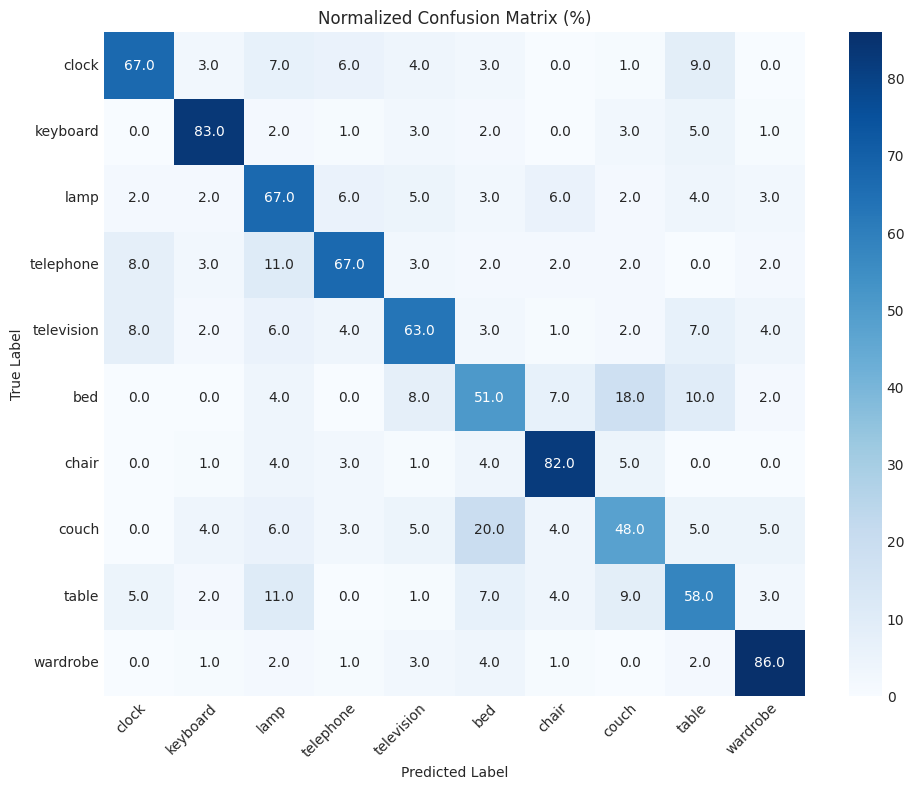


Optimized Model Metrics (pipeline/pipeline_c_distill_prune_fx_ptq/step01_distillation):
Accuracy: 67.20%
Model Size: 1.80 MB
CPU Inference Time: 152.07 ms (6.58 FPS)
CUDA Inference Time: 6.32 ms (158.15 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:39<00:00,  4.88s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:28<00:00,  3.53s/it]


Model comparison plot saved to ../results/pipeline/pipeline_c_distill_prune_fx_ptq/step01_distillation/comparison.png


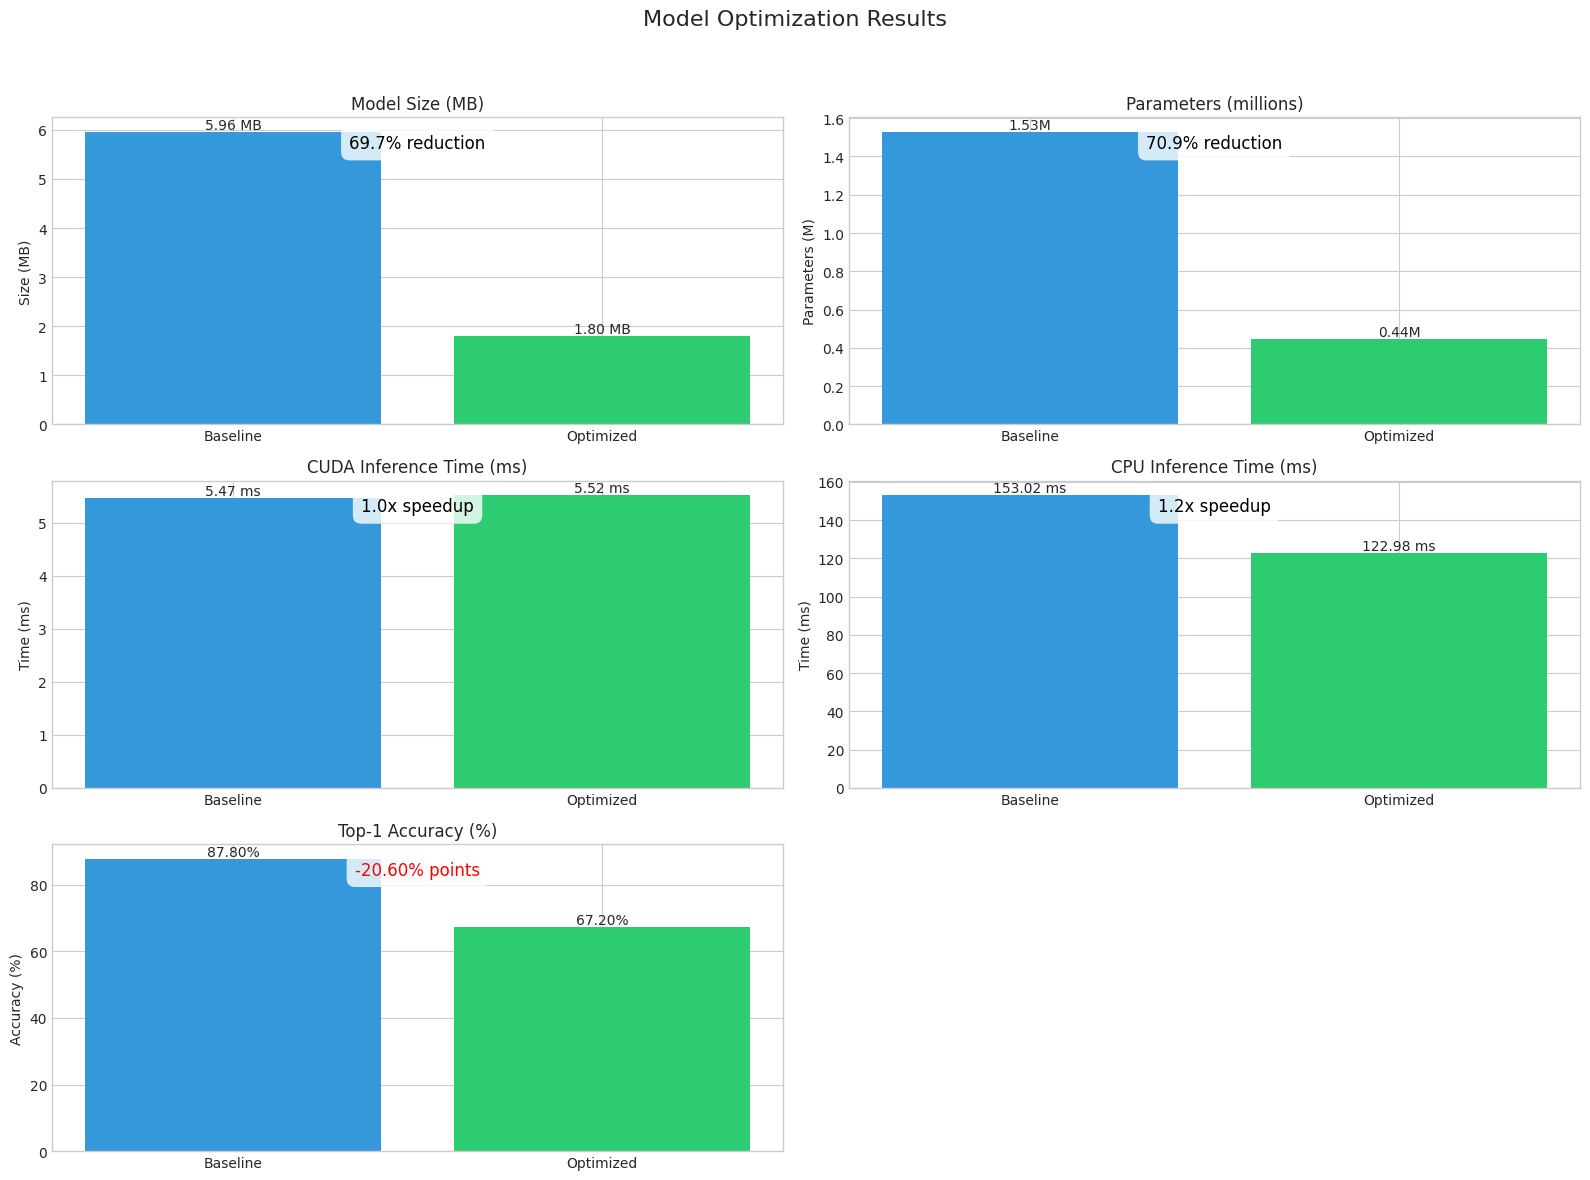


pipeline/pipeline_c_distill_prune_fx_ptq/step01_distillation Results:
Model Size: 1.80 MB (69.7% reduction)
Parameters: 444,706 (70.9% reduction)
CPU Inference Time: 122.98 ms (1.2x speedup)
CUDA Inference Time: 5.52 ms (1.0x speedup)
Accuracy: 67.20% (-20.60% change)
Requirements met: False
Completed distillation in 467.45s

--------------------------------------------------
Step 2: in_train_pruning
--------------------------------------------------

Total parameters: 444,706
Training with gradual pruning for 10 epochs
Pruning schedule: 0.00% → 50.00% sparsity from epoch 1 to 8


Epoch 1/10 [Test]: 100%|██████████| 8/8 [00:01<00:00,  6.58it/s, loss=2.79, acc=44.6]


Epoch 1/10 - Train Loss: 1.1611, Train Acc: 62.12%, Test Loss: 2.0956, Test Acc: 44.60%, Sparsity: 0.00%, LR: 0.000976, Time: 5.99s


Epoch 2/10 [Test]: 100%|██████████| 8/8 [00:00<00:00,  9.61it/s, loss=1.75, acc=54.9]


Epoch 2/10 - Train Loss: 1.0255, Train Acc: 65.00%, Test Loss: 1.7509, Test Acc: 54.90%, Sparsity: 0.00%, LR: 0.000905, Time: 6.18s


...

Epoch 9/10 - Train Loss: 1.0000, Train Acc: 65.86%, Test Loss: 1.8481, Test Acc: 37.90%, Sparsity: 49.62%, LR: 0.000024, Time: 5.98s
Early stopping at epoch 9. No improvement for 5 epochs.
Making pruning permanent on best model...
✅ Model is pruned
Model saved to ../models/pipeline/pipeline_c_distill_prune_fx_ptq/checkpoints/pipeline_c_distill_prune_fx_ptq_in_train_prune.pth
Training completed. Best accuracy: 61.50%
Best model saved as '../models/pipeline/pipeline_c_distill_prune_fx_ptq/checkpoints/pipeline_c_distill_prune_fx_ptq_in_train_prune.pth' at epoch 4
Final model sparsity: 31.63%

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:22<00:00,  2.82s/it]


Baseline metrics saved at ../results/pipeline/pipeline_c_distill_prune_fx_ptq/step02_in_train_pruning/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:21<00:00,  2.67s/it]


Confusion matrix saved to ../results/pipeline/pipeline_c_distill_prune_fx_ptq/step02_in_train_pruning/confusion_matrix.png


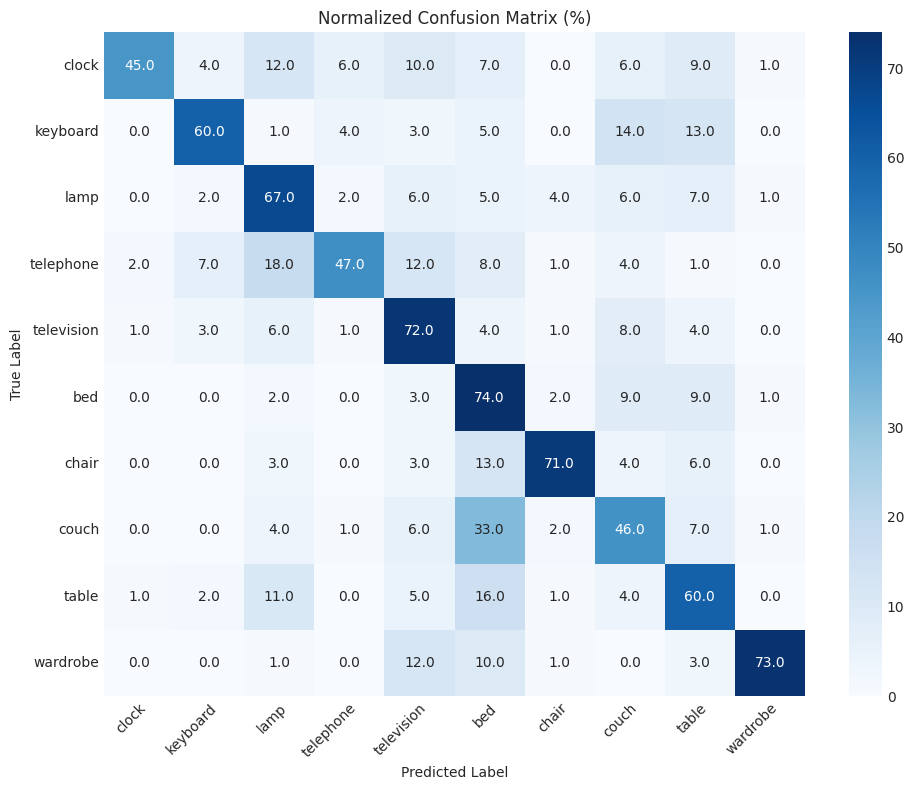


Optimized Model Metrics (pipeline/pipeline_c_distill_prune_fx_ptq/step02_in_train_pruning):
Accuracy: 61.50%
Model Size: 1.80 MB
CPU Inference Time: 140.94 ms (7.10 FPS)
CUDA Inference Time: 5.74 ms (174.23 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:27<00:00,  3.49s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:22<00:00,  2.75s/it]


Model comparison plot saved to ../results/pipeline/pipeline_c_distill_prune_fx_ptq/step02_in_train_pruning/comparison.png


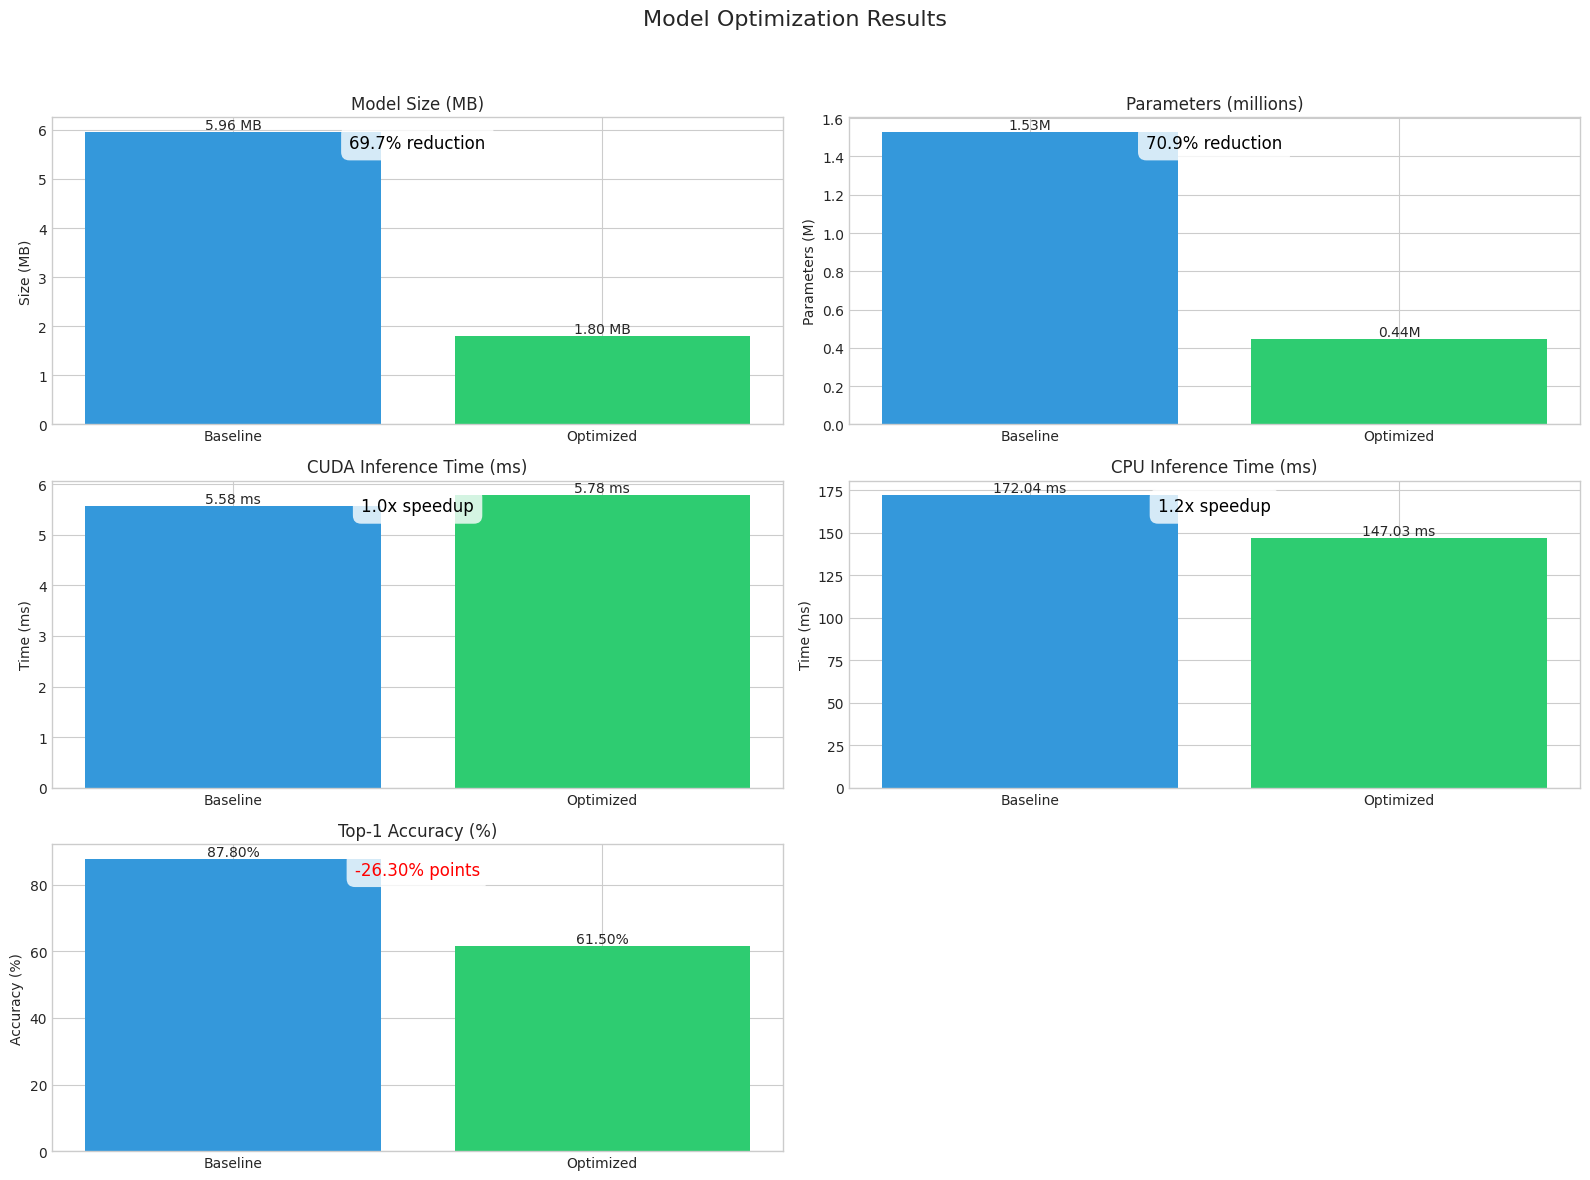


pipeline/pipeline_c_distill_prune_fx_ptq/step02_in_train_pruning Results:
Model Size: 1.80 MB (69.7% reduction)
Parameters: 444,706 (70.9% reduction)
CPU Inference Time: 147.03 ms (1.2x speedup)
CUDA Inference Time: 5.78 ms (1.0x speedup)
Accuracy: 61.50% (-26.30% change)
Requirements met: False
Completed in_train_pruning in 276.44s

--------------------------------------------------
Step 3: graph_fx
--------------------------------------------------


Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:19<00:00,  2.44s/it]


Baseline metrics saved at ../results/pipeline/pipeline_c_distill_prune_fx_ptq/step03_graph_fx/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:17<00:00,  2.14s/it]


Confusion matrix saved to ../results/pipeline/pipeline_c_distill_prune_fx_ptq/step03_graph_fx/confusion_matrix.png


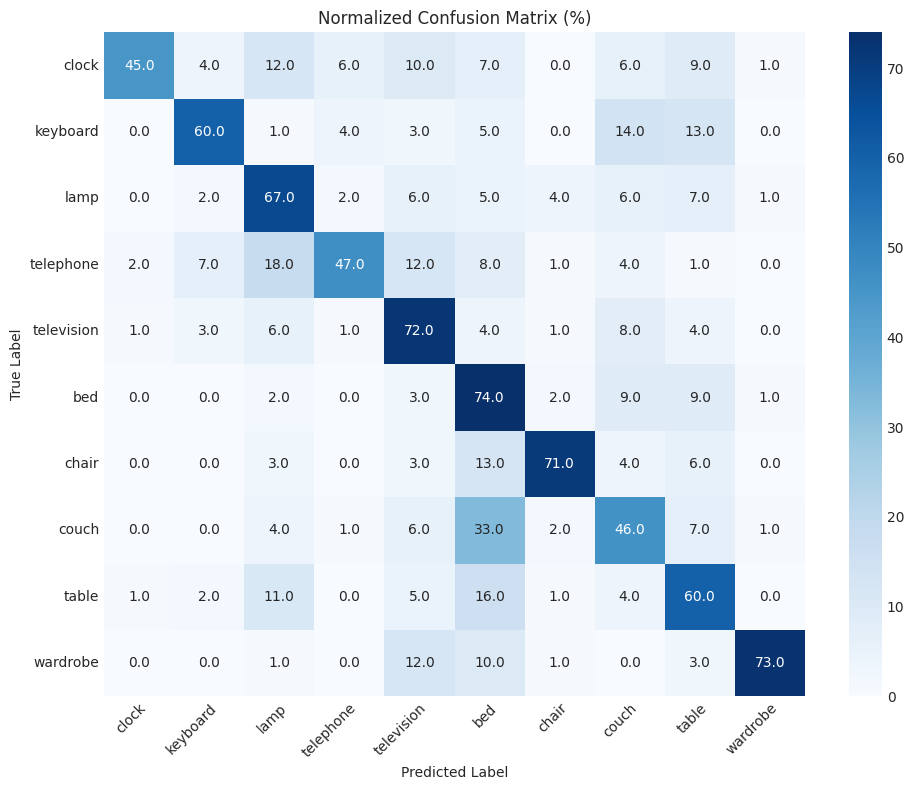


Optimized Model Metrics (pipeline/pipeline_c_distill_prune_fx_ptq/step03_graph_fx):
Accuracy: 61.50%
Model Size: 1.72 MB
CPU Inference Time: 129.98 ms (7.69 FPS)
CUDA Inference Time: 5.50 ms (181.86 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:29<00:00,  3.66s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:19<00:00,  2.40s/it]


Model comparison plot saved to ../results/pipeline/pipeline_c_distill_prune_fx_ptq/step03_graph_fx/comparison.png


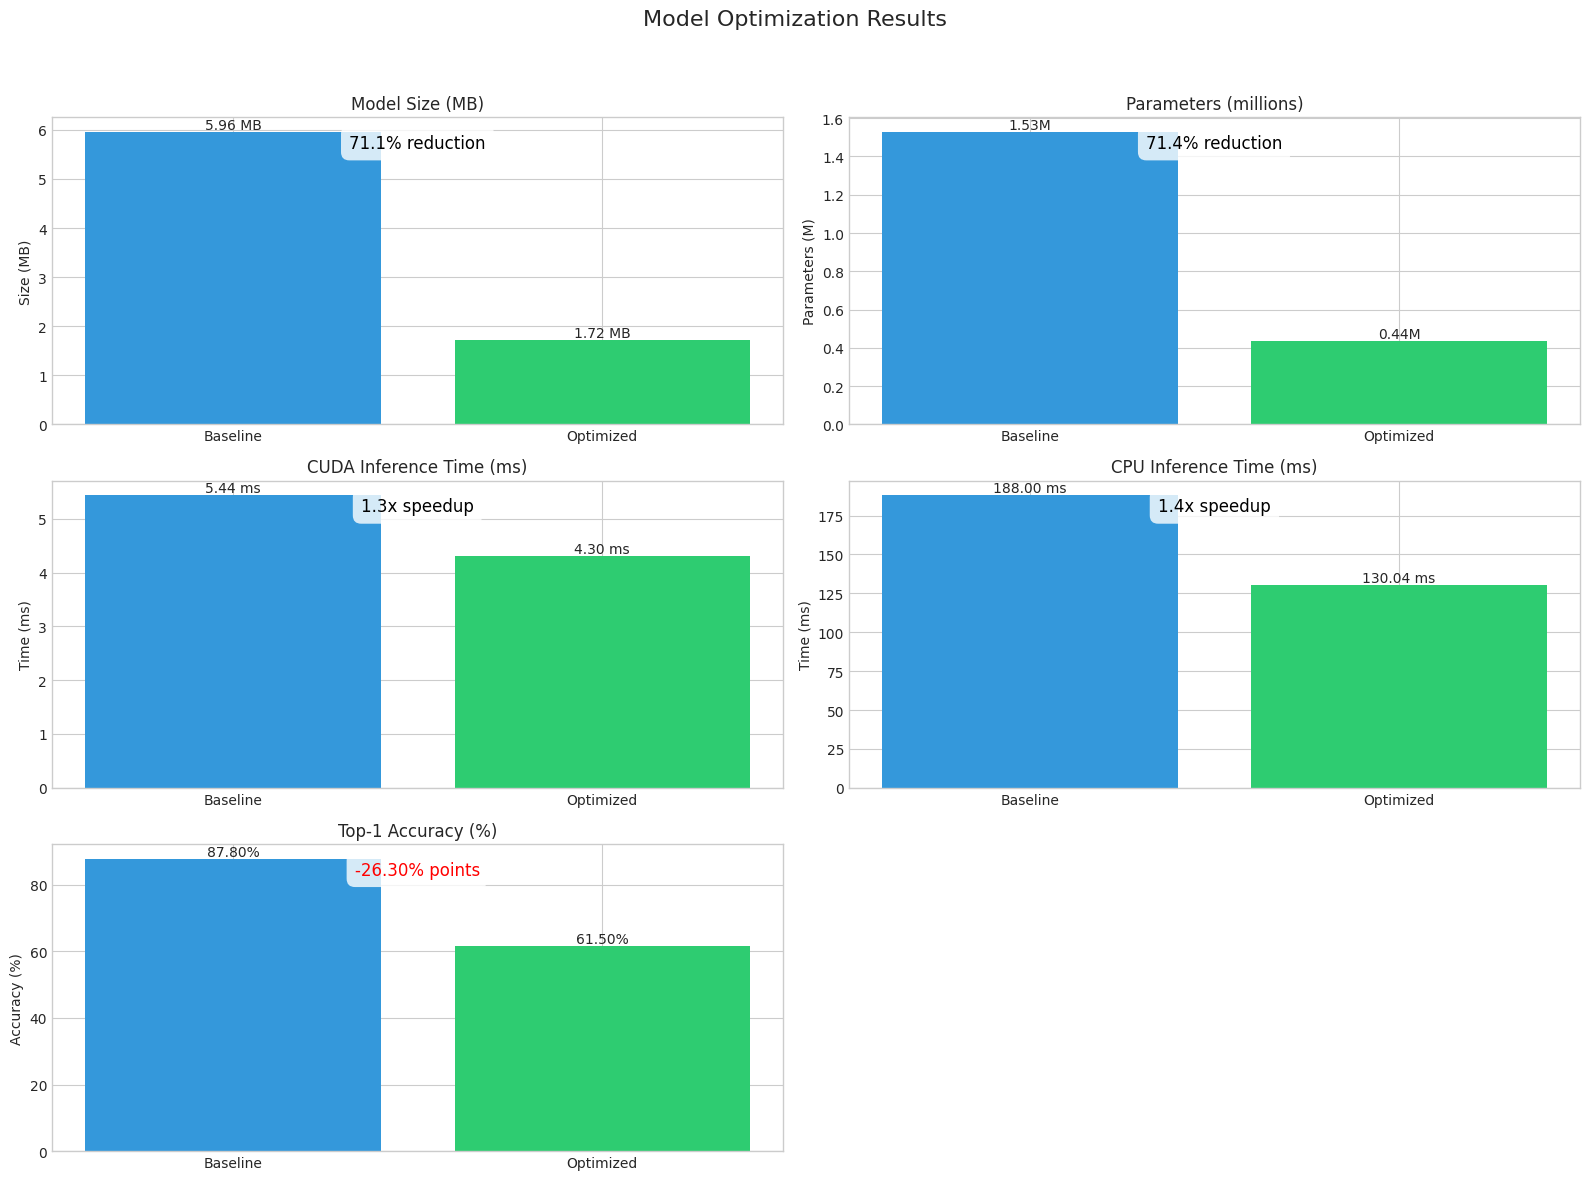


pipeline/pipeline_c_distill_prune_fx_ptq/step03_graph_fx Results:
Model Size: 1.72 MB (71.1% reduction)
Parameters: 437,410 (71.4% reduction)
CPU Inference Time: 130.04 ms (1.4x speedup)
CUDA Inference Time: 4.30 ms (1.3x speedup)
Accuracy: 61.50% (-26.30% change)
Requirements met: False
Completed graph_fx in 205.81s

--------------------------------------------------
Step 4: static_quant
--------------------------------------------------

Applying static quantization...


/usr/local/lib/python3.12/dist-packages/torch/ao/quantization/observer.py:229: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


Calibrating on 10 batch(es)...


Calibration: 100%|██████████| 10/10 [00:54<00:00,  5.41s/it]



Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:14<00:00,  1.83s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Baseline metrics saved at ../results/pipeline/pipeline_c_distill_prune_fx_ptq/step04_static_quant/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:12<00:00,  1.61s/it]


Confusion matrix saved to ../results/pipeline/pipeline_c_distill_prune_fx_ptq/step04_static_quant/confusion_matrix.png


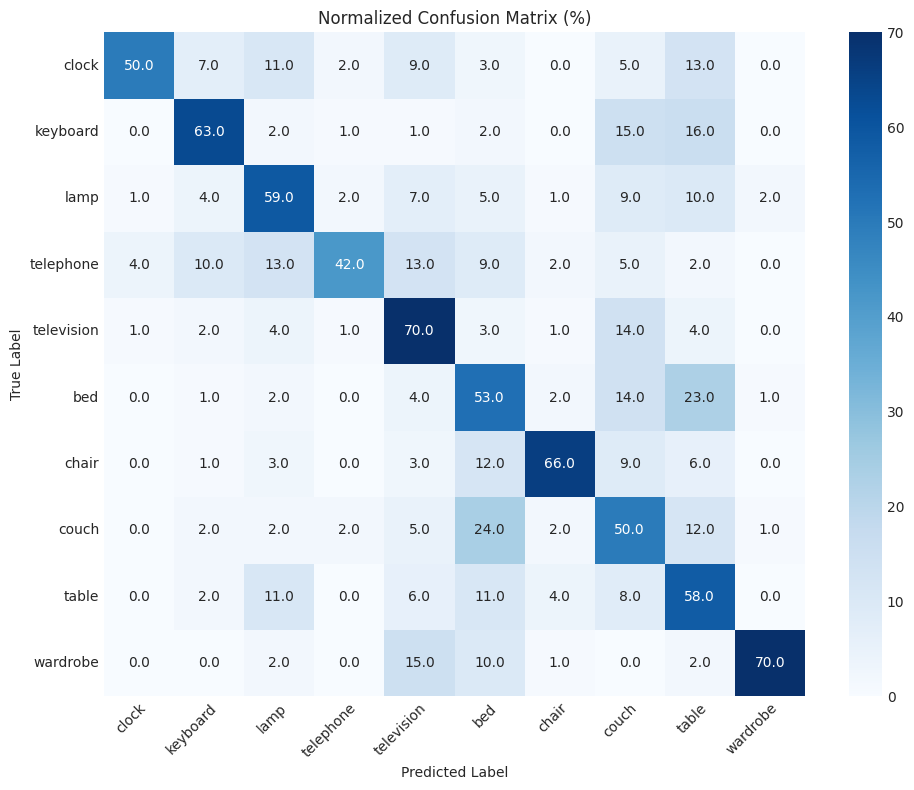


Optimized Model Metrics (pipeline/pipeline_c_distill_prune_fx_ptq/step04_static_quant):
Accuracy: 57.60%
Model Size: 0.64 MB
CPU Inference Time: 124.05 ms (8.06 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:34<00:00,  4.36s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:14<00:00,  1.76s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Model comparison plot saved to ../results/pipeline/pipeline_c_distill_prune_fx_ptq/step04_static_quant/comparison.png


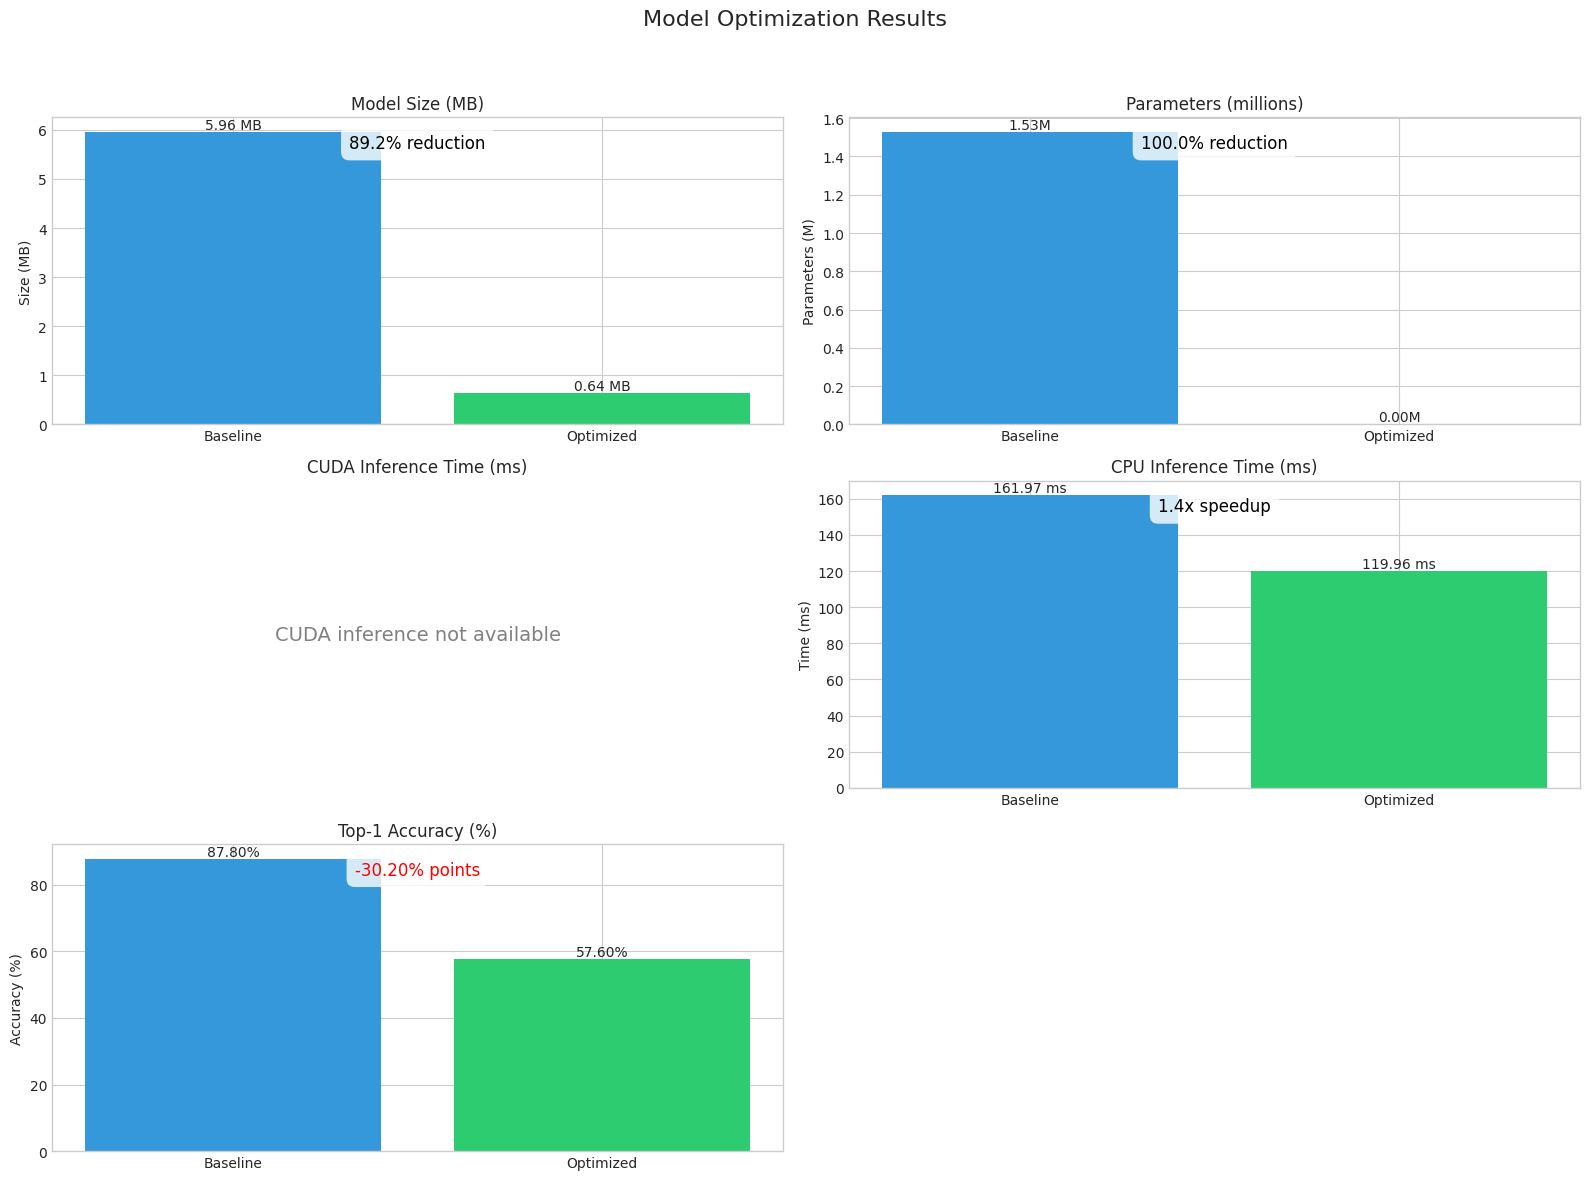


pipeline/pipeline_c_distill_prune_fx_ptq/step04_static_quant Results:
Model Size: 0.64 MB (89.2% reduction)
Parameters: 0 (100.0% reduction)
CPU Inference Time: 119.96 ms (1.4x speedup)
Accuracy: 57.60% (-30.20% change)
Requirements met: False
Completed static_quant in 252.08s
Model saved to ../models/pipeline/pipeline_c_distill_prune_fx_ptq/model.pth

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:13<00:00,  1.70s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Baseline metrics saved at ../results/pipeline/pipeline_c_distill_prune_fx_ptq/final/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:13<00:00,  1.63s/it]


Confusion matrix saved to ../results/pipeline/pipeline_c_distill_prune_fx_ptq/final/confusion_matrix.png


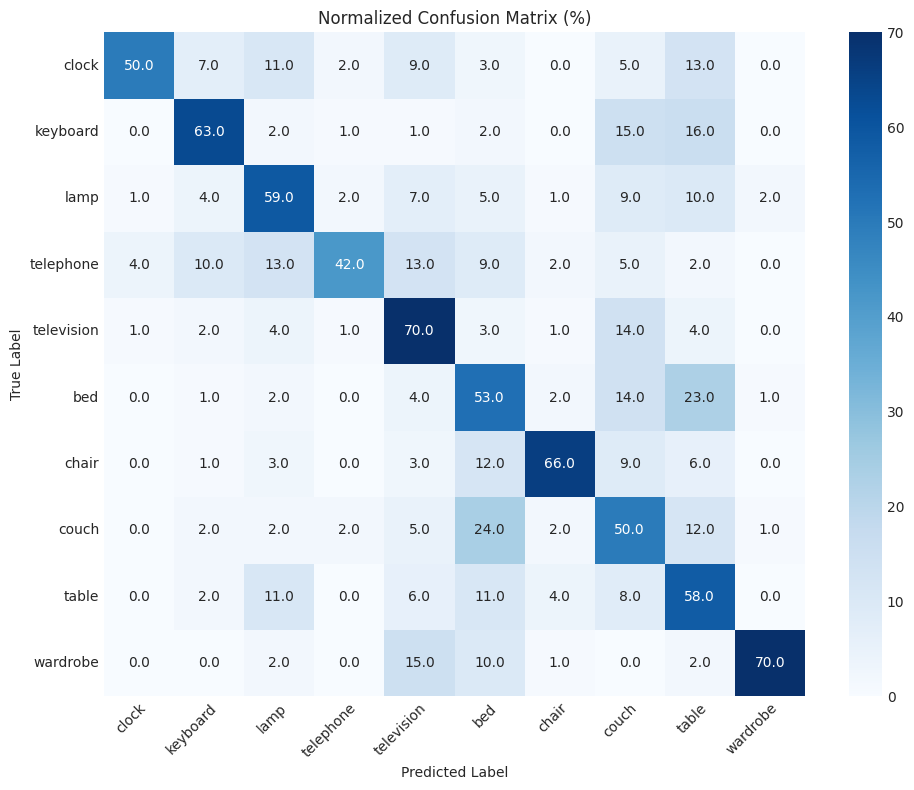


Optimized Model Metrics (pipeline/pipeline_c_distill_prune_fx_ptq/final):
Accuracy: 57.60%
Model Size: 0.64 MB
CPU Inference Time: 120.00 ms (8.33 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:38<00:00,  4.86s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:13<00:00,  1.73s/it]


INFO: Detected quantized CPU-only model. Skipping CUDA latency evaluation.
Model comparison plot saved to ../results/pipeline/pipeline_c_distill_prune_fx_ptq/final/comparison.png


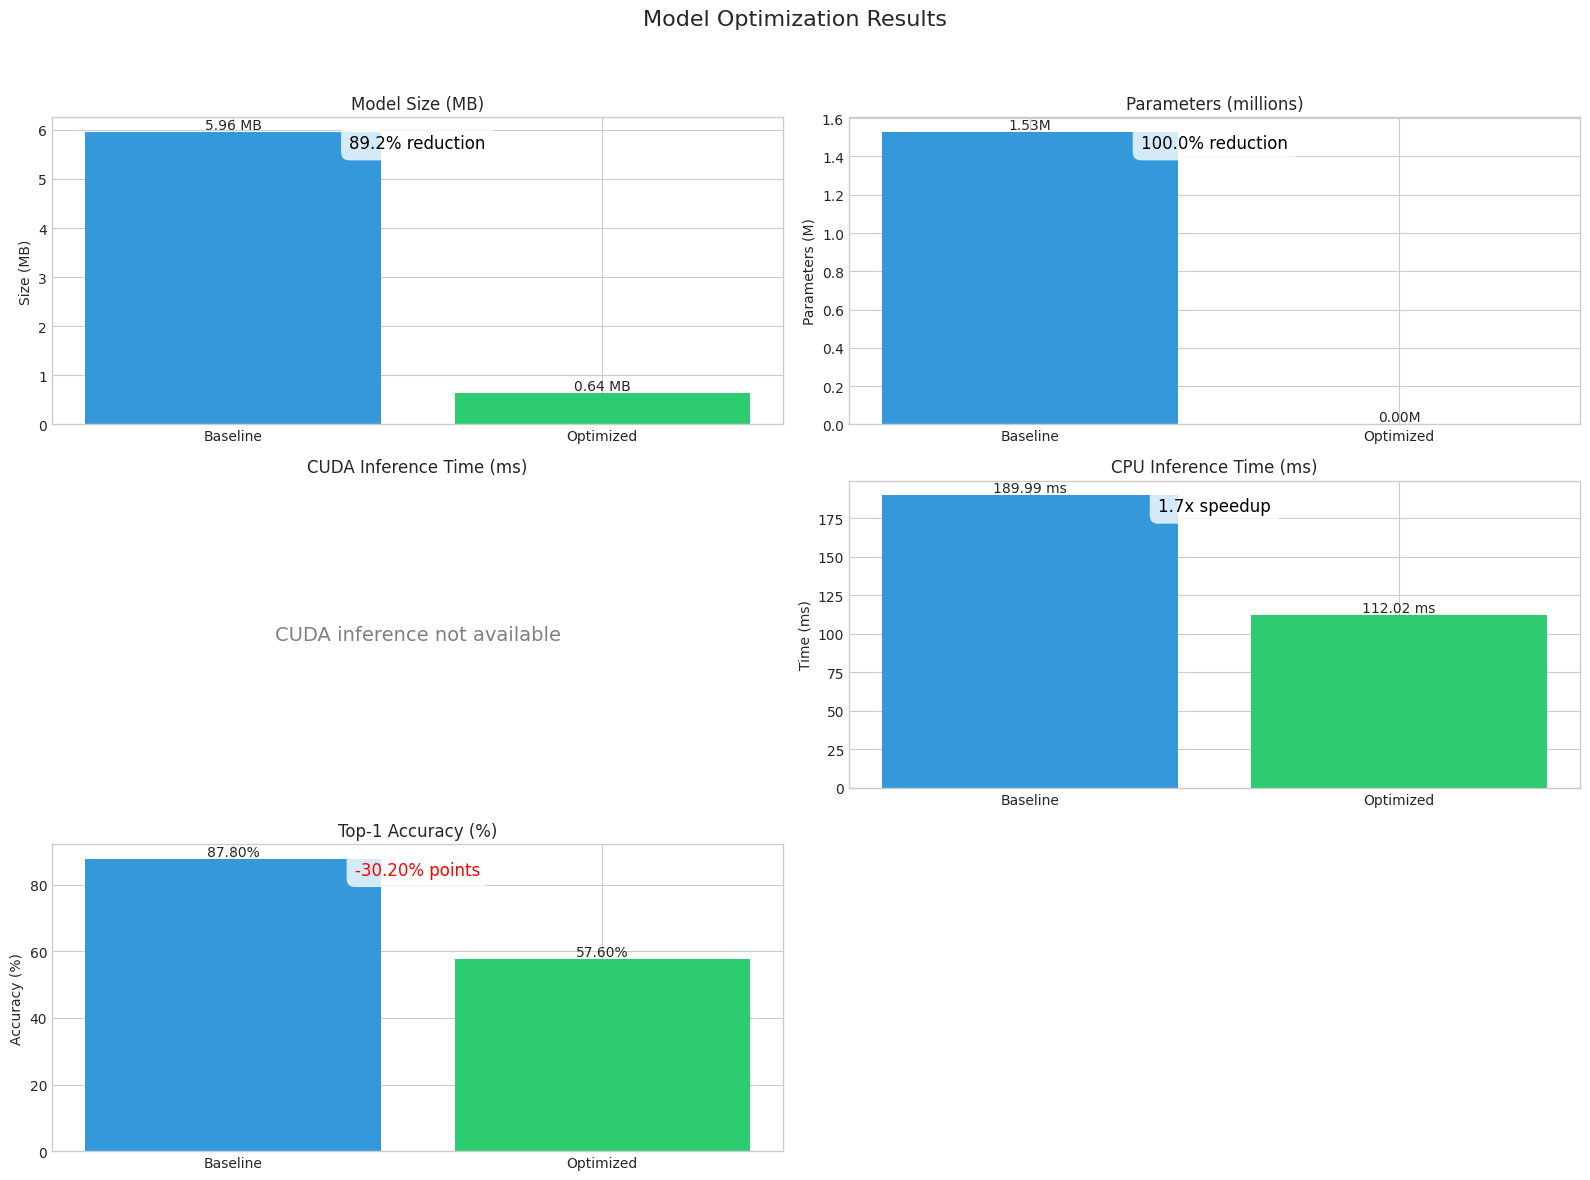


pipeline/pipeline_c_distill_prune_fx_ptq/final Results:
Model Size: 0.64 MB (89.2% reduction)
Parameters: 0 (100.0% reduction)
CPU Inference Time: 112.02 ms (1.7x speedup)
Accuracy: 57.60% (-30.20% change)
Requirements met: False

Pipeline pipeline_c_distill_prune_fx_ptq completed
Final model path: ../models/pipeline/pipeline_c_distill_prune_fx_ptq/model.pth



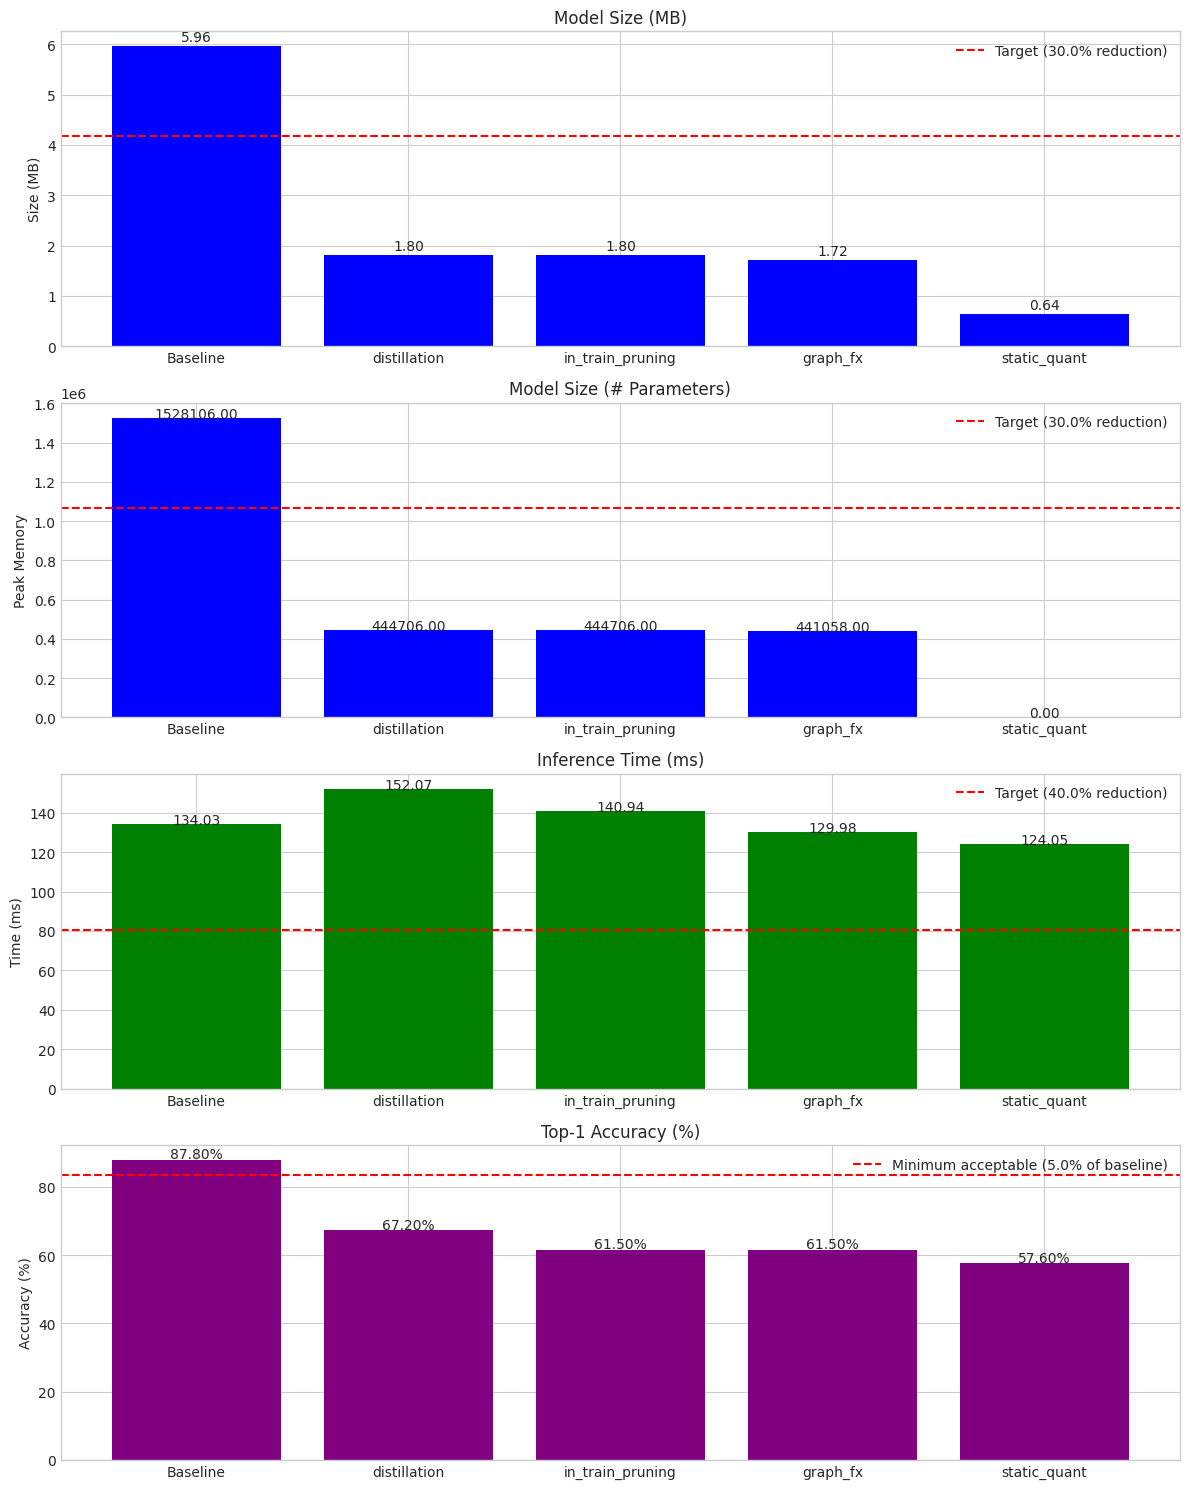


Pipeline pipeline_c_distill_prune_fx_ptq Results Summary

Model Size (MB):
  Baseline: 5.96 MB
  Final: 0.64 MB
  Reduction: 89.24%
  Meets target (30.0% reduction)

Model Size (# Parameters):
  Baseline: 1528106.00 MB
  Final: 0.00 MB
  Reduction: 100.00%
  Meets target (30.0% reduction)

Inference Time (CPU):
  Baseline: 134.03 ms
  Final: 124.05 ms
  Reduction: 7.45%
  Does not meet target (Goal: 80.42 ms)

Accuracy:
  Baseline: 87.80%
  Final: 57.60%
  Change: -34.40%
  Does not meet target (Goal: >=83.41%)

Overall Assessment:
  Pipeline does not meet all requirements


,pipeline,size_mb,cpu_ms,top1_acc,size_reduction,cpu_speedup,accuracy_change
0,pipeline_a_prune_fx_ptq,None,None,None,None,None,None
1,pipeline_b_distill_fx_ptq,None,None,None,None,None,None
2,pipeline_c_distill_prune_fx_ptq,None,None,None,None,None,None


Recommended final pipeline: pipeline_a_prune_fx_ptq


/tmp/ipykernel_357435/2703954077.py:163: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  2.0 * ranked["size_reduction"].fillna(0.0)
/tmp/ipykernel_357435/2703954077.py:164: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  + 1.5 * ((ranked["cpu_speedup"].fillna(0.0) - 1.0) / 2.0)
/tmp/ipykernel_357435/2703954077.py:165: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_d

In [7]:
# Create and run multiple pipelines, then compare with clear metrics.

# Use the backend diagnosed in Step 4.0 (fbgemm on x86, qnnpack on ARM) instead of
# the naive "qnnpack if listed" heuristic, which selects slow x86 reference kernels.
# Run the Step 4.0 diagnosis cell first so RECOMMENDED_BACKEND is defined; fall back
# to a platform check if it was skipped.
import platform as _platform
backend = globals().get(
    "RECOMMENDED_BACKEND",
    "qnnpack" if any(k in _platform.machine().lower() for k in ("arm", "aarch")) else "fbgemm",
)
print(f"Pipelines A/B/C will quantize with backend = '{backend}'")
train_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
report_device = torch.device('cpu')

all_pipelines = {}

# Pipeline A: Balanced (fast + reliable)
pipeline_name_a = "pipeline_a_prune_fx_ptq"
pipeline_a = OptimizationPipeline(
    name=pipeline_name_a,
    baseline_model=baseline_model,
    train_loader=train_loader,
    test_loader=test_loader,
    class_names=class_names,
    input_size=input_size,
)
pipeline_a.add_step(
    "post_pruning",
    apply_post_training_pruning,
    amount=0.35,
    pruning_method="global_unstructured",
).add_step(
    "graph_fx",
    apply_graph_optimization,
    optimization_method="torch_fx",
).add_step(
    "static_quant",
    apply_static_quantization,
    backend=backend,
    calibration_num_batches=10,
)
optimized_model_a = pipeline_a.run(device=report_device)
pipeline_a.visualize_results(baseline_metrics, report_device)
all_pipelines[pipeline_name_a] = pipeline_a

# Pipeline B: Accuracy-preserving student-first
pipeline_name_b = "pipeline_b_distill_fx_ptq"
pipeline_b = OptimizationPipeline(
    name=pipeline_name_b,
    baseline_model=baseline_model,
    train_loader=train_loader,
    test_loader=test_loader,
    class_names=class_names,
    input_size=input_size,
)
pipeline_b.add_step(
    "distillation",
    apply_knowledge_distillation,
    device=train_device,
    width_mult=0.6,
    linear_size=256,
    dropout=0.2,
    num_epochs=20,
    alpha=0.7,
    temperature=4.0,
).add_step(
    "graph_fx",
    apply_graph_optimization,
    optimization_method="torch_fx",
).add_step(
    "static_quant",
    apply_static_quantization,
    backend=backend,
    calibration_num_batches=10,
)
optimized_model_b = pipeline_b.run(device=report_device)
pipeline_b.visualize_results(baseline_metrics, report_device)
all_pipelines[pipeline_name_b] = pipeline_b

# Pipeline C: Aggressive stacked pipeline
pipeline_name_c = "pipeline_c_distill_prune_fx_ptq"
pipeline_c = OptimizationPipeline(
    name=pipeline_name_c,
    baseline_model=baseline_model,
    train_loader=train_loader,
    test_loader=test_loader,
    class_names=class_names,
    input_size=input_size,
)
pipeline_c.add_step(
    "distillation",
    apply_knowledge_distillation,
    device=train_device,
    width_mult=0.6,
    linear_size=256,
    dropout=0.2,
    num_epochs=20,
    alpha=0.7,
    temperature=4.0,
).add_step(
    "in_train_pruning",
    apply_in_training_pruning,
    device=train_device,
    num_epochs=10,
    initial_sparsity=0.0,
    final_sparsity=0.5,
    start_epoch=1,
    end_epoch=8,
    pruning_frequency=1,
    pruning_method="global_unstructured",
    schedule_type="cubic",
).add_step(
    "graph_fx",
    apply_graph_optimization,
    optimization_method="torch_fx",
).add_step(
    "static_quant",
    apply_static_quantization,
    backend=backend,
    calibration_num_batches=10,
)
optimized_model_c = pipeline_c.run(device=report_device)
pipeline_c.visualize_results(baseline_metrics, report_device)
all_pipelines[pipeline_name_c] = pipeline_c

# Summarize all pipeline finals in a compact table.
summary_rows = []
for name, p in all_pipelines.items():
    # compare_optimized_model_to_baseline() returns a FLAT result dict, not a
    # nested {"improvements": ..., "optimized": ...} structure. Read the flat keys.
    final_cmp = p.results.get("final_comparison", {})
    summary_rows.append({
        "pipeline": name,
        "size_mb": final_cmp.get("model_size_mb"),
        "cpu_ms": final_cmp.get("cpu_inference_time_ms"),
        "top1_acc": final_cmp.get("accuracy"),
        "size_reduction": final_cmp.get("size_reduction"),
        "cpu_speedup": final_cmp.get("cpu_inference_speedup"),
        "accuracy_change": final_cmp.get("accuracy_change"),
    })

pipeline_summary_df = pd.DataFrame(summary_rows)
if not pipeline_summary_df.empty:
    display(pipeline_summary_df.sort_values(by=["size_reduction", "cpu_speedup"], ascending=False))

# Pick a final recommended pipeline that satisfies all CTO constraints when possible.
final_pipeline_name = None
if not pipeline_summary_df.empty:
    meets = pipeline_summary_df[
        (pipeline_summary_df["size_reduction"] >= TARGET_MODEL_COMPRESSION)
        & (pipeline_summary_df["cpu_speedup"] >= 1.0 / (1.0 - TARGET_INFERENCE_SPEEDUP))
        & (pipeline_summary_df["accuracy_change"] >= -MAX_ALLOWED_ACCURACY_DROP)
    ]
    if not meets.empty:
        # Prefer higher accuracy among those meeting all constraints.
        final_pipeline_name = meets.sort_values(by=["top1_acc", "cpu_speedup"], ascending=False).iloc[0]["pipeline"]
    else:
        # Fallback: rank by weighted objective.
        ranked = pipeline_summary_df.copy()
        ranked["score"] = (
            2.0 * ranked["size_reduction"].fillna(0.0)
            + 1.5 * ((ranked["cpu_speedup"].fillna(0.0) - 1.0) / 2.0)
            + 2.0 * ranked["accuracy_change"].fillna(-1.0)
        )
        final_pipeline_name = ranked.sort_values(by="score", ascending=False).iloc[0]["pipeline"]

print(f"Recommended final pipeline: {final_pipeline_name}")

#### Distillation-first pipeline (Pipeline D)

The Step 4.0 diagnosis settled the quantization question with measured numbers on this
x86 CPU:

| backend | int8 acc | int8 latency | vs fp32 |
|---|---|---|---|
| fp32 baseline | 87.80% | 120.14 ms | 1.00x |
| fbgemm (correct for x86) | 16.10% | 115.28 ms | **1.04x** |
| qnnpack (naive heuristic) | 13.40% | 5294.95 ms | **0.02x (~44x slower)** |

Two independent facts fall out of this:

1. The ~36x slowdown seen in notebook 02 was purely a **backend mismatch** — the
   `"qnnpack" if listed else "fbgemm"` heuristic selects qnnpack on x86, where it runs
   slow reference kernels. `fbgemm` restores normal latency.
2. Even with the correct backend, int8 delivers **only 1.04x speed (short of the 1.67x
   target) and still collapses accuracy to ~16%**. The accuracy loss is architectural:
   the default qconfig mis-quantizes MobileNetV3's hard-swish / SE blocks, independent of
   backend.

**Conclusion:** on this model/CPU, static quantization is a net loss (no real speedup +
accuracy collapse), so Pipeline D **drops the int8 stage** and relies on the two levers
that actually work here — **distillation** (a smaller, well-trained student) plus
**graph fusion**. The student network is where the size and latency reduction comes from;
fusion adds a low-risk latency trim without touching accuracy. We give the student a wider
width (0.75 vs 0.6) and a longer 40-epoch schedule to fix the ~69% under-training seen in
Pipelines B/C.

(If int8 is ever required, it needs a custom qconfig for hard-swish/SE or QAT — tracked as
future work, not used in the recommended path.)

#### Probe: verify the BatchNorm recalibration fix (run after kernel restart)

`%autoreload 2` does not reliably reload already-bound module functions, so after editing
`distillation.py` you must **Restart Kernel** and re-run the imports. This short 3-epoch
probe confirms the fix cheaply before committing to the full 40-epoch Pipeline D run:
if `recalibrate_bn` is working, **Test Acc climbs well above 10%** within a couple of epochs
instead of staying frozen at 10.00%.

In [10]:
# --- [PROBE] Confirm the BatchNorm recalibration fix works before the full run ---
# Expectation: with the fix loaded, Test Acc rises above 10% within ~3 epochs.
# If it stays frozen at exactly 10.00%, the edited distillation.py was NOT reloaded
# (Restart Kernel, then re-run the import cell and this probe).
import inspect
from compression.in_training import distillation as _distmod
assert hasattr(_distmod, 'recalibrate_bn'), (
    'recalibrate_bn missing -> stale module. Restart Kernel and re-run imports.'
)
assert 'recalibrate_bn' in inspect.getsource(_distmod.train_with_distillation), (
    'train_with_distillation does not call recalibrate_bn -> stale module. '
    'Restart Kernel and re-run imports.'
)
print('recalibrate_bn is loaded and wired into train_with_distillation.\n')

_probe_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_probe_teacher = copy.deepcopy(baseline_model).to(_probe_device).eval()
_probe_student = MobileNetV3_Household_Small(
    num_classes=len(class_names), width_mult=0.75, linear_size=256, dropout=0.2,
).to(_probe_device)
_probe_opt = torch.optim.AdamW(_probe_student.parameters(), lr=1e-3, weight_decay=1e-4)
_probe_cfg = {
    'num_epochs': 3,
    'criterion': nn.CrossEntropyLoss(),
    'optimizer': _probe_opt,
    'scheduler': torch.optim.lr_scheduler.CosineAnnealingLR(_probe_opt, T_max=3),
    'alpha': 0.7,
    'temperature': 4.0,
    'patience': 3,
    'device': _probe_device,
    'grad_clip_norm': 1.0,
}
_probe_model, _probe_stats, _probe_best, _probe_epoch = train_with_distillation(
    _probe_student, _probe_teacher, train_loader, test_loader, _probe_cfg,
    checkpoint_path='../models/pipeline/_probe/probe_distill.pth',
)
print(f'\nPROBE best test acc over 3 epochs: {_probe_best:.2f}% (epoch {_probe_epoch})')
if _probe_best > 20.0:
    print('FIX CONFIRMED: eval accuracy recovered -> run the full Pipeline D below.')
else:
    print('STILL COLLAPSED: module likely stale -> Restart Kernel and re-run imports.')
del _probe_teacher, _probe_student, _probe_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

recalibrate_bn is loaded and wired into train_with_distillation.

Student parameters: 665,794
Teacher parameters: 1,528,106
Training with knowledge distillation for 3 epochs
Temperature: 4.0, Alpha: 0.7


Epoch 1/3 [Test]: 100%|██████████| 8/8 [00:01<00:00,  6.31it/s, loss=2.49, acc=25.3]


Epoch 1/3 - Train Loss: 10.8349, Train Acc: 17.18%, Test Loss: 2.1747, Test Acc: 25.30%, LR: 0.000750, Time: 12.42s
New best student model! Saving... (25.30%)
Model saved to ../models/pipeline/_probe/probe_distill.pth


Epoch 2/3 [Test]: 100%|██████████| 8/8 [00:00<00:00,  9.43it/s, loss=3.04, acc=33]  


Epoch 2/3 - Train Loss: 9.5274, Train Acc: 28.52%, Test Loss: 2.2804, Test Acc: 33.00%, LR: 0.000250, Time: 11.03s
New best student model! Saving... (33.00%)
Model saved to ../models/pipeline/_probe/probe_distill.pth


Epoch 3/3 [Test]: 100%|██████████| 8/8 [00:00<00:00,  9.00it/s, loss=3.36, acc=39.6]
/workspace/code/project/starter-kit/utils/model.py:103: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experiment

Epoch 3/3 - Train Loss: 8.6747, Train Acc: 35.74%, Test Loss: 2.0994, Test Acc: 39.60%, LR: 0.000000, Time: 11.19s
New best student model! Saving... (39.60%)
Model saved to ../models/pipeline/_probe/probe_distill.pth
Distillation completed. Best student accuracy: 39.60%
Best student model saved as '../models/pipeline/_probe/probe_distill.pth' at epoch 3

PROBE best test acc over 3 epochs: 39.60% (epoch 3)
FIX CONFIRMED: eval accuracy recovered -> run the full Pipeline D below.



Running pipeline: pipeline_d_distill_first_fx


--------------------------------------------------
Step 1: distillation
--------------------------------------------------

Student parameters: 665,794
Teacher parameters: 1,528,106
Training with knowledge distillation for 40 epochs
Temperature: 4.0, Alpha: 0.7


Epoch 1/40 [Test]: 100%|██████████| 8/8 [00:00<00:00,  8.00it/s, loss=2.87, acc=27.5]


Epoch 1/40 - Train Loss: 10.7596, Train Acc: 20.04%, Test Loss: 2.1529, Test Acc: 27.50%, LR: 0.000998, Time: 10.92s
New best student model! Saving... (27.50%)
Model saved to ../models/pipeline/pipeline_d_distill_first_fx/checkpoints/pipeline_d_distill_first_fx_distill.pth


Epoch 2/40 [Test]: 100%|██████████| 8/8 [00:00<00:00,  9.00it/s, loss=2.63, acc=35]  


Epoch 2/40 - Train Loss: 9.4345, Train Acc: 29.52%, Test Loss: 1.9691, Test Acc: 35.00%, LR: 0.000994, Time: 10.93s
New best student model! Saving... (35.00%)
Model saved to ../models/pipeline/pipeline_d_distill_first_fx/checkpoints/pipeline_d_distill_first_fx_distill.pth


...

Epoch 40/40 - Train Loss: 1.5801, Train Acc: 86.98%, Test Loss: 1.0922, Test Acc: 75.70%, LR: 0.000000, Time: 10.80s
Distillation completed. Best student accuracy: 76.20%
Best student model saved as '../models/pipeline/pipeline_d_distill_first_fx/checkpoints/pipeline_d_distill_first_fx_distill.pth' at epoch 36

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:33<00:00,  4.20s/it]


Baseline metrics saved at ../results/pipeline/pipeline_d_distill_first_fx/step01_distillation/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:33<00:00,  4.15s/it]


Confusion matrix saved to ../results/pipeline/pipeline_d_distill_first_fx/step01_distillation/confusion_matrix.png


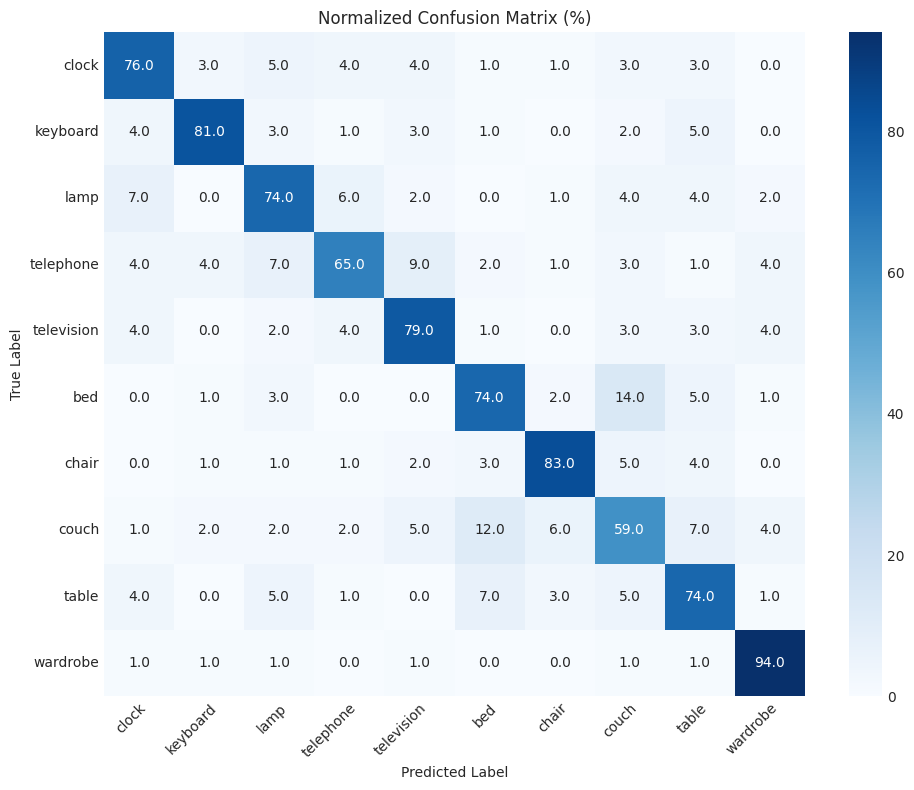


Optimized Model Metrics (pipeline/pipeline_d_distill_first_fx/step01_distillation):
Accuracy: 75.90%
Model Size: 2.65 MB
CPU Inference Time: 177.05 ms (5.65 FPS)
CUDA Inference Time: 5.84 ms (171.14 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:36<00:00,  4.52s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:28<00:00,  3.51s/it]


Model comparison plot saved to ../results/pipeline/pipeline_d_distill_first_fx/step01_distillation/comparison.png


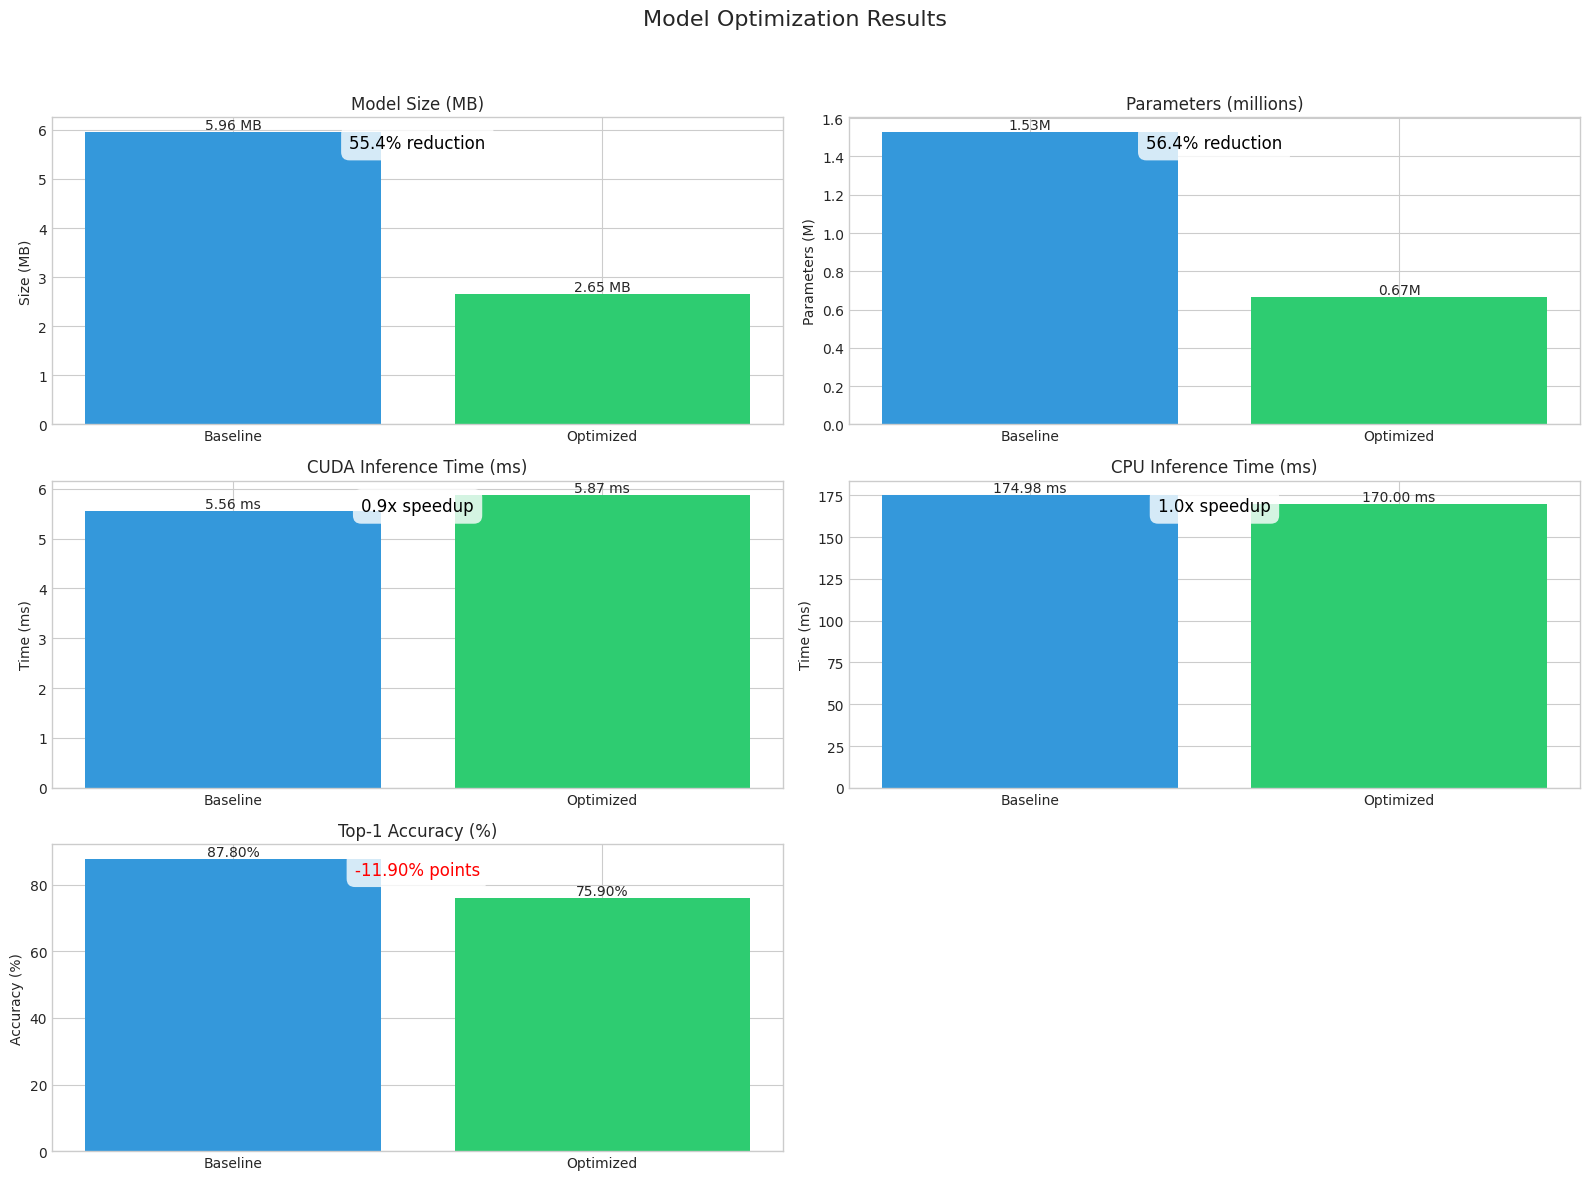


pipeline/pipeline_d_distill_first_fx/step01_distillation Results:
Model Size: 2.65 MB (55.4% reduction)
Parameters: 665,794 (56.4% reduction)
CPU Inference Time: 170.00 ms (1.0x speedup)
CUDA Inference Time: 5.87 ms (0.9x speedup)
Accuracy: 75.90% (-11.90% change)
Requirements met: False
Completed distillation in 717.97s

--------------------------------------------------
Step 2: graph_fx
--------------------------------------------------


Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:18<00:00,  2.31s/it]


Baseline metrics saved at ../results/pipeline/pipeline_d_distill_first_fx/step02_graph_fx/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:18<00:00,  2.26s/it]


Confusion matrix saved to ../results/pipeline/pipeline_d_distill_first_fx/step02_graph_fx/confusion_matrix.png


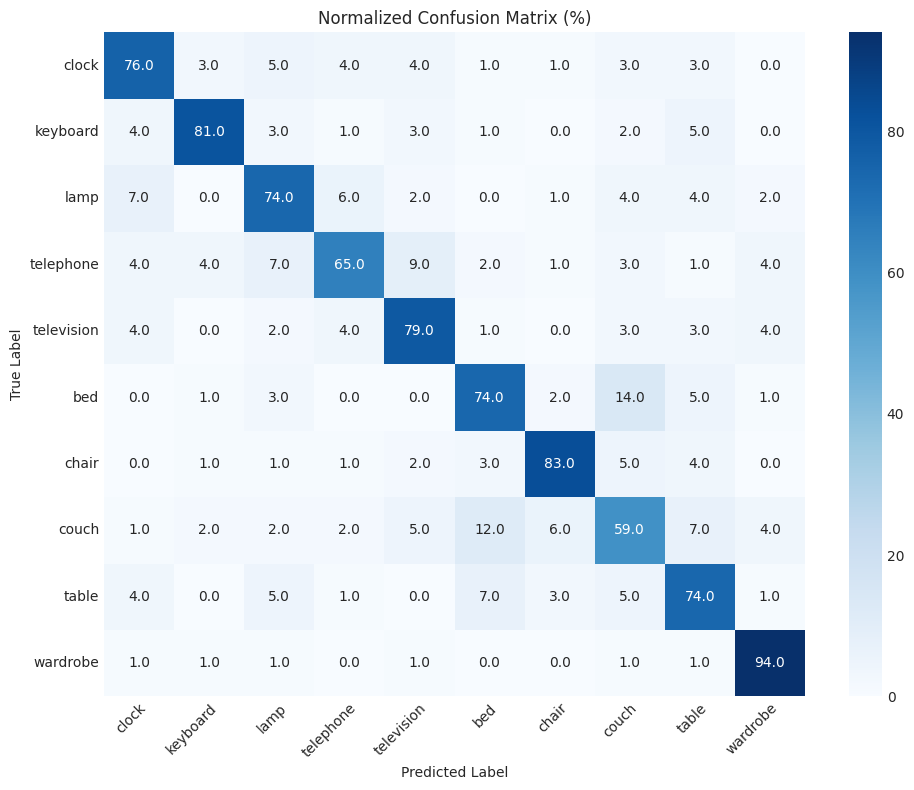


Optimized Model Metrics (pipeline/pipeline_d_distill_first_fx/step02_graph_fx):
Accuracy: 75.90%
Model Size: 2.56 MB
CPU Inference Time: 129.04 ms (7.75 FPS)
CUDA Inference Time: 4.33 ms (230.98 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:36<00:00,  4.51s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:19<00:00,  2.46s/it]


Model comparison plot saved to ../results/pipeline/pipeline_d_distill_first_fx/step02_graph_fx/comparison.png


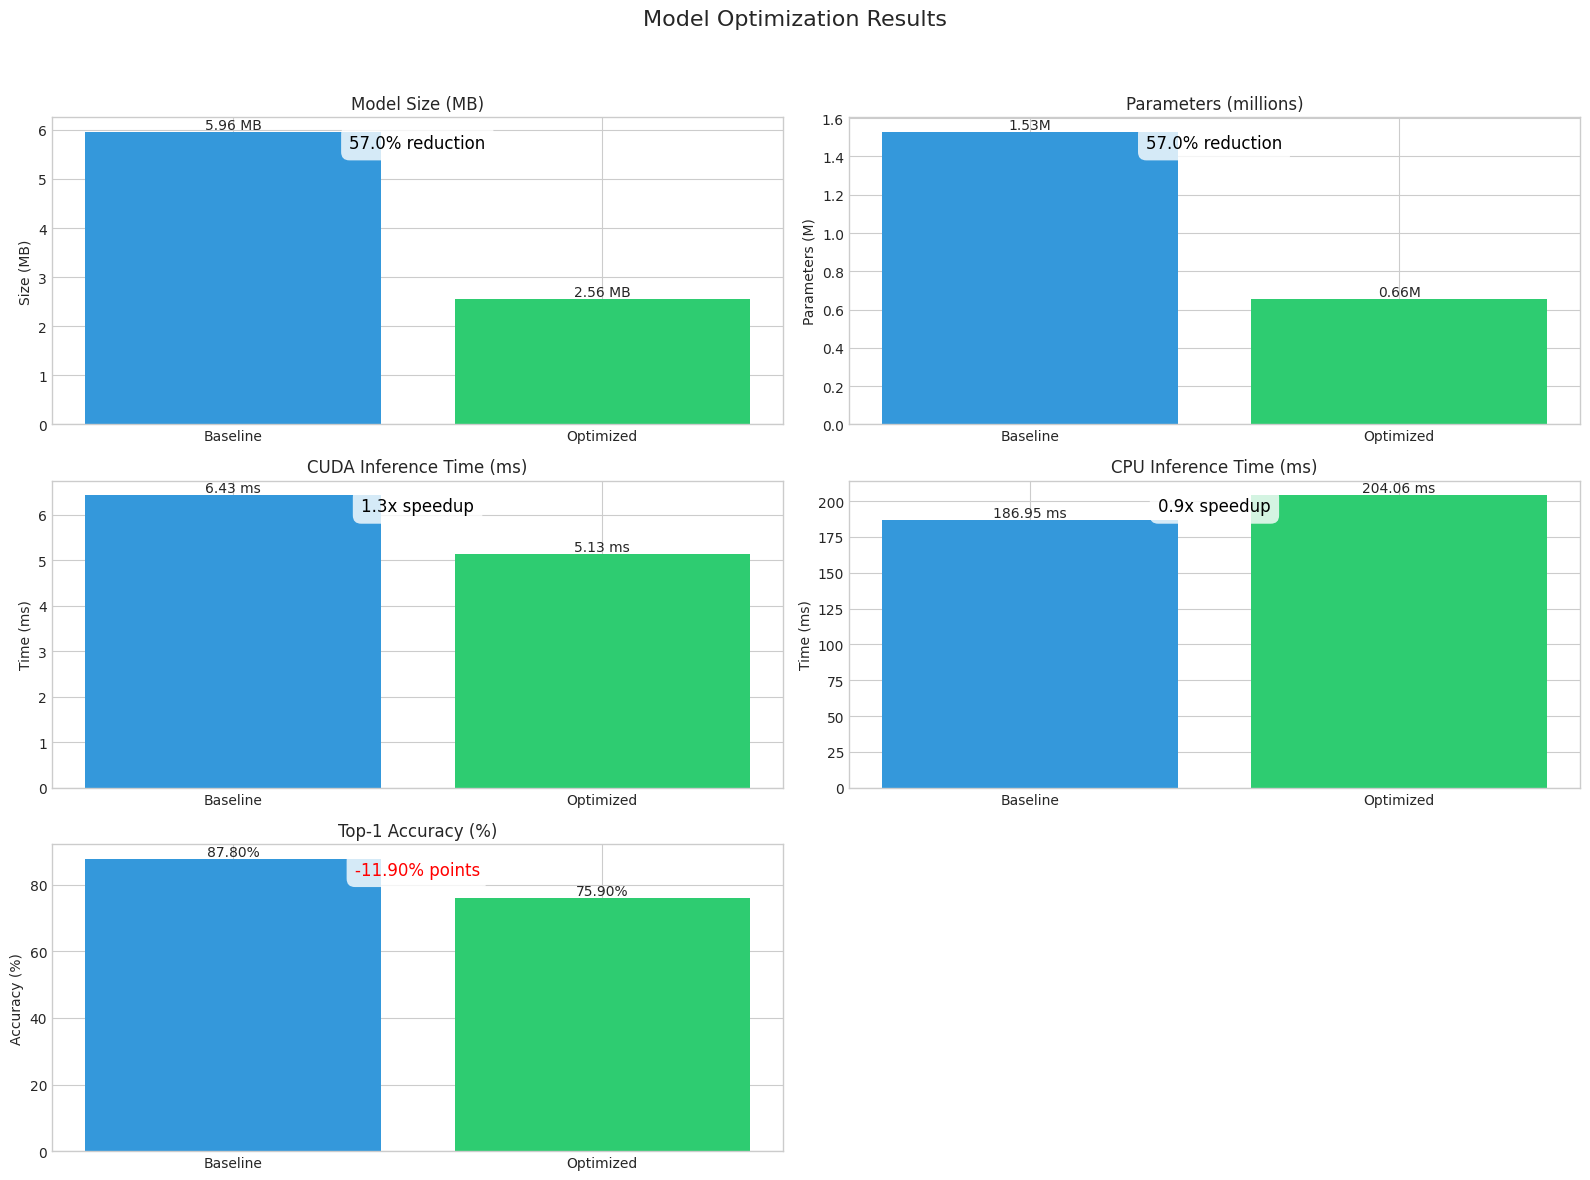


pipeline/pipeline_d_distill_first_fx/step02_graph_fx Results:
Model Size: 2.56 MB (57.0% reduction)
Parameters: 656,594 (57.0% reduction)
CPU Inference Time: 204.06 ms (0.9x speedup)
CUDA Inference Time: 5.13 ms (1.3x speedup)
Accuracy: 75.90% (-11.90% change)
Requirements met: False
Completed graph_fx in 236.75s
Model saved to ../models/pipeline/pipeline_d_distill_first_fx/model.pth

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:20<00:00,  2.62s/it]


Baseline metrics saved at ../results/pipeline/pipeline_d_distill_first_fx/final/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:23<00:00,  2.99s/it]


Confusion matrix saved to ../results/pipeline/pipeline_d_distill_first_fx/final/confusion_matrix.png


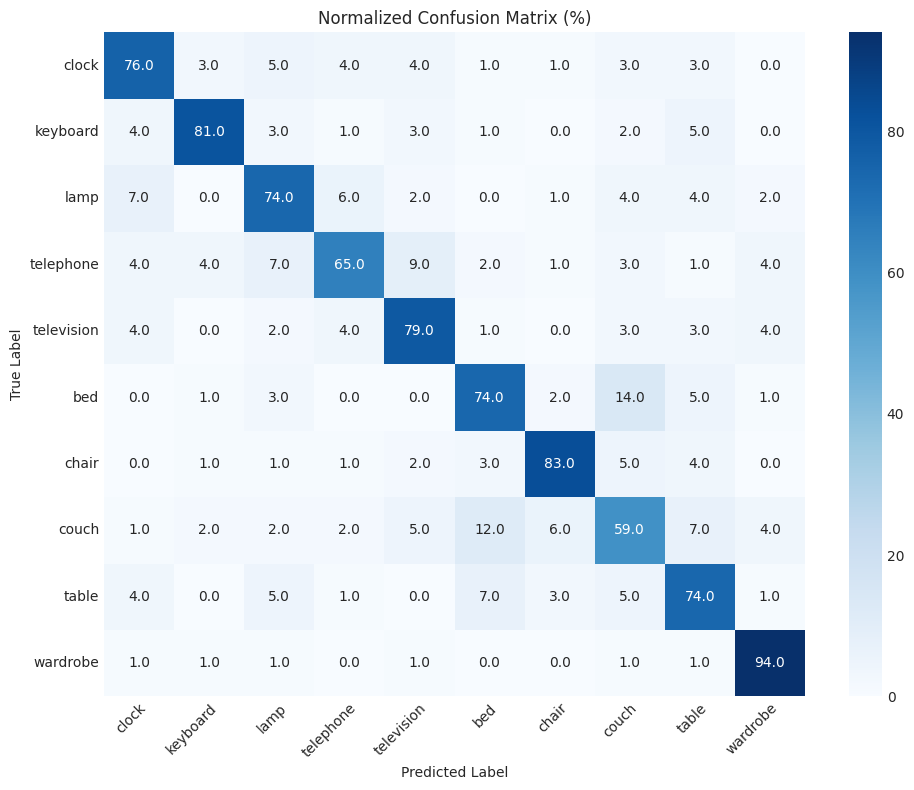


Optimized Model Metrics (pipeline/pipeline_d_distill_first_fx/final):
Accuracy: 75.90%
Model Size: 2.56 MB
CPU Inference Time: 141.01 ms (7.09 FPS)
CUDA Inference Time: 4.35 ms (229.64 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:28<00:00,  3.51s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:22<00:00,  2.81s/it]


Model comparison plot saved to ../results/pipeline/pipeline_d_distill_first_fx/final/comparison.png


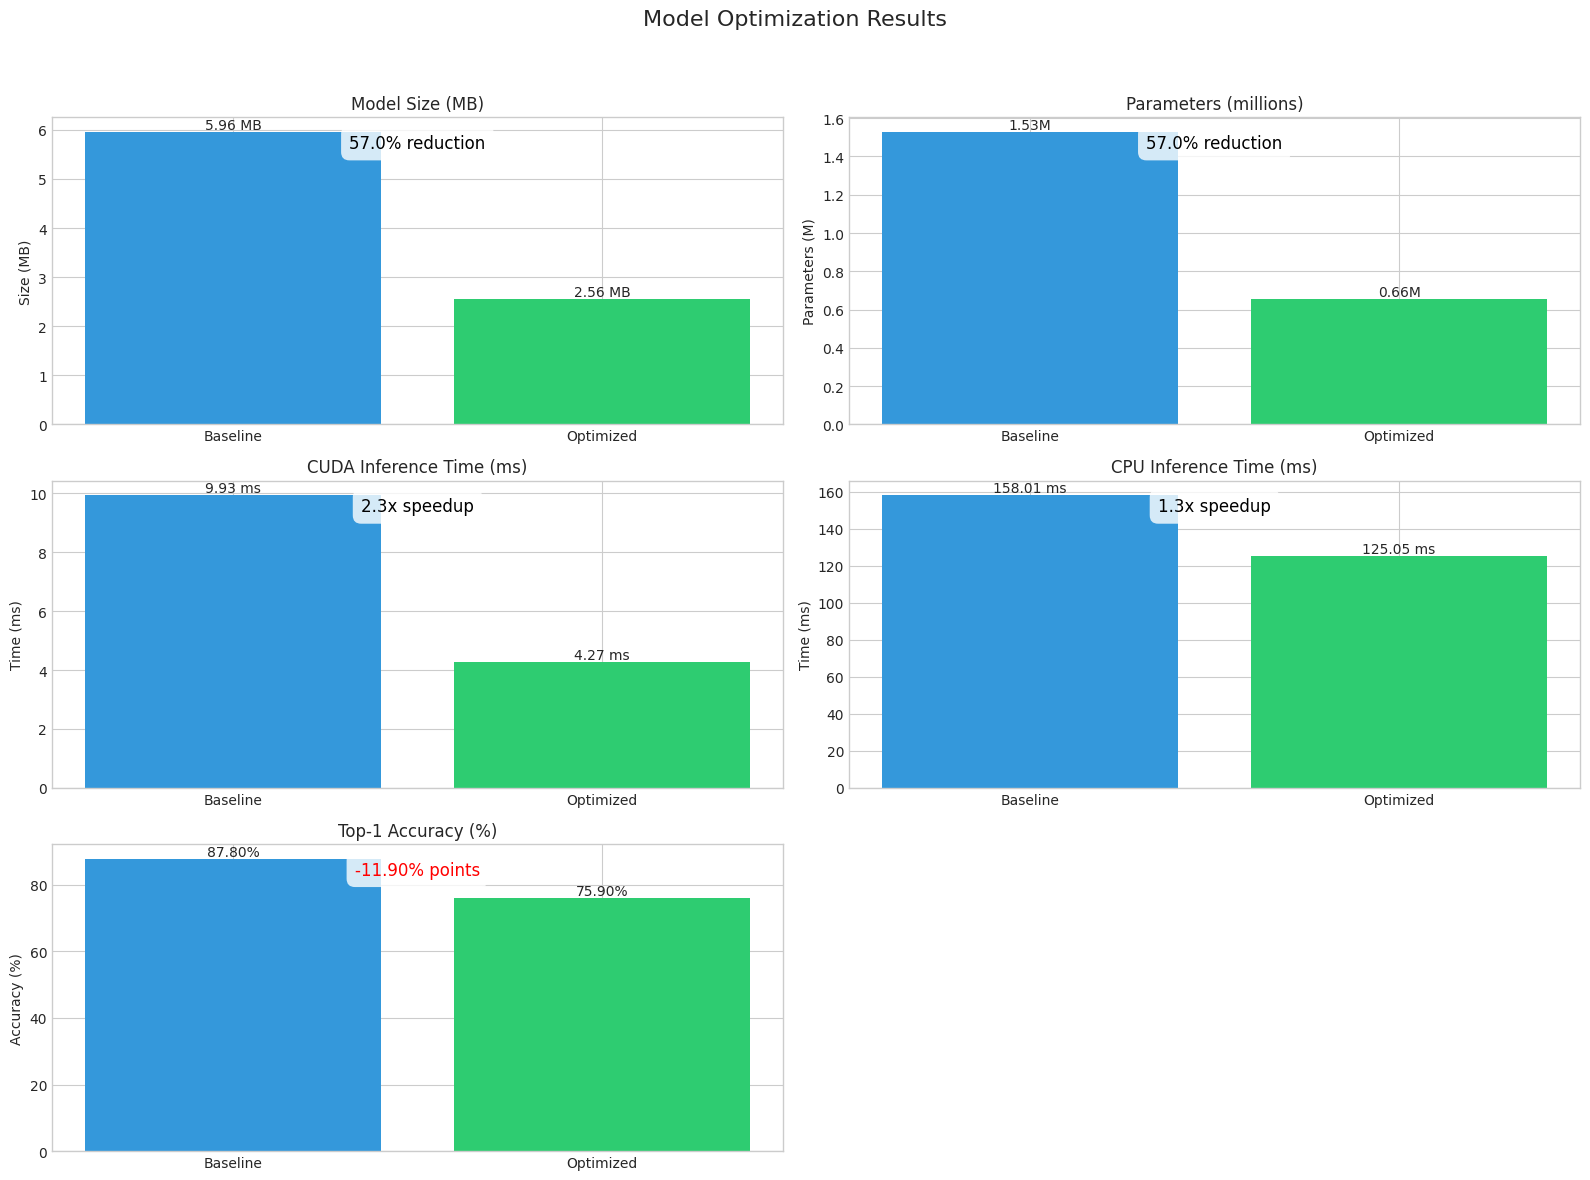


pipeline/pipeline_d_distill_first_fx/final Results:
Model Size: 2.56 MB (57.0% reduction)
Parameters: 656,594 (57.0% reduction)
CPU Inference Time: 125.05 ms (1.3x speedup)
CUDA Inference Time: 4.27 ms (2.3x speedup)
Accuracy: 75.90% (-11.90% change)
Requirements met: False

Pipeline pipeline_d_distill_first_fx completed
Final model path: ../models/pipeline/pipeline_d_distill_first_fx/model.pth



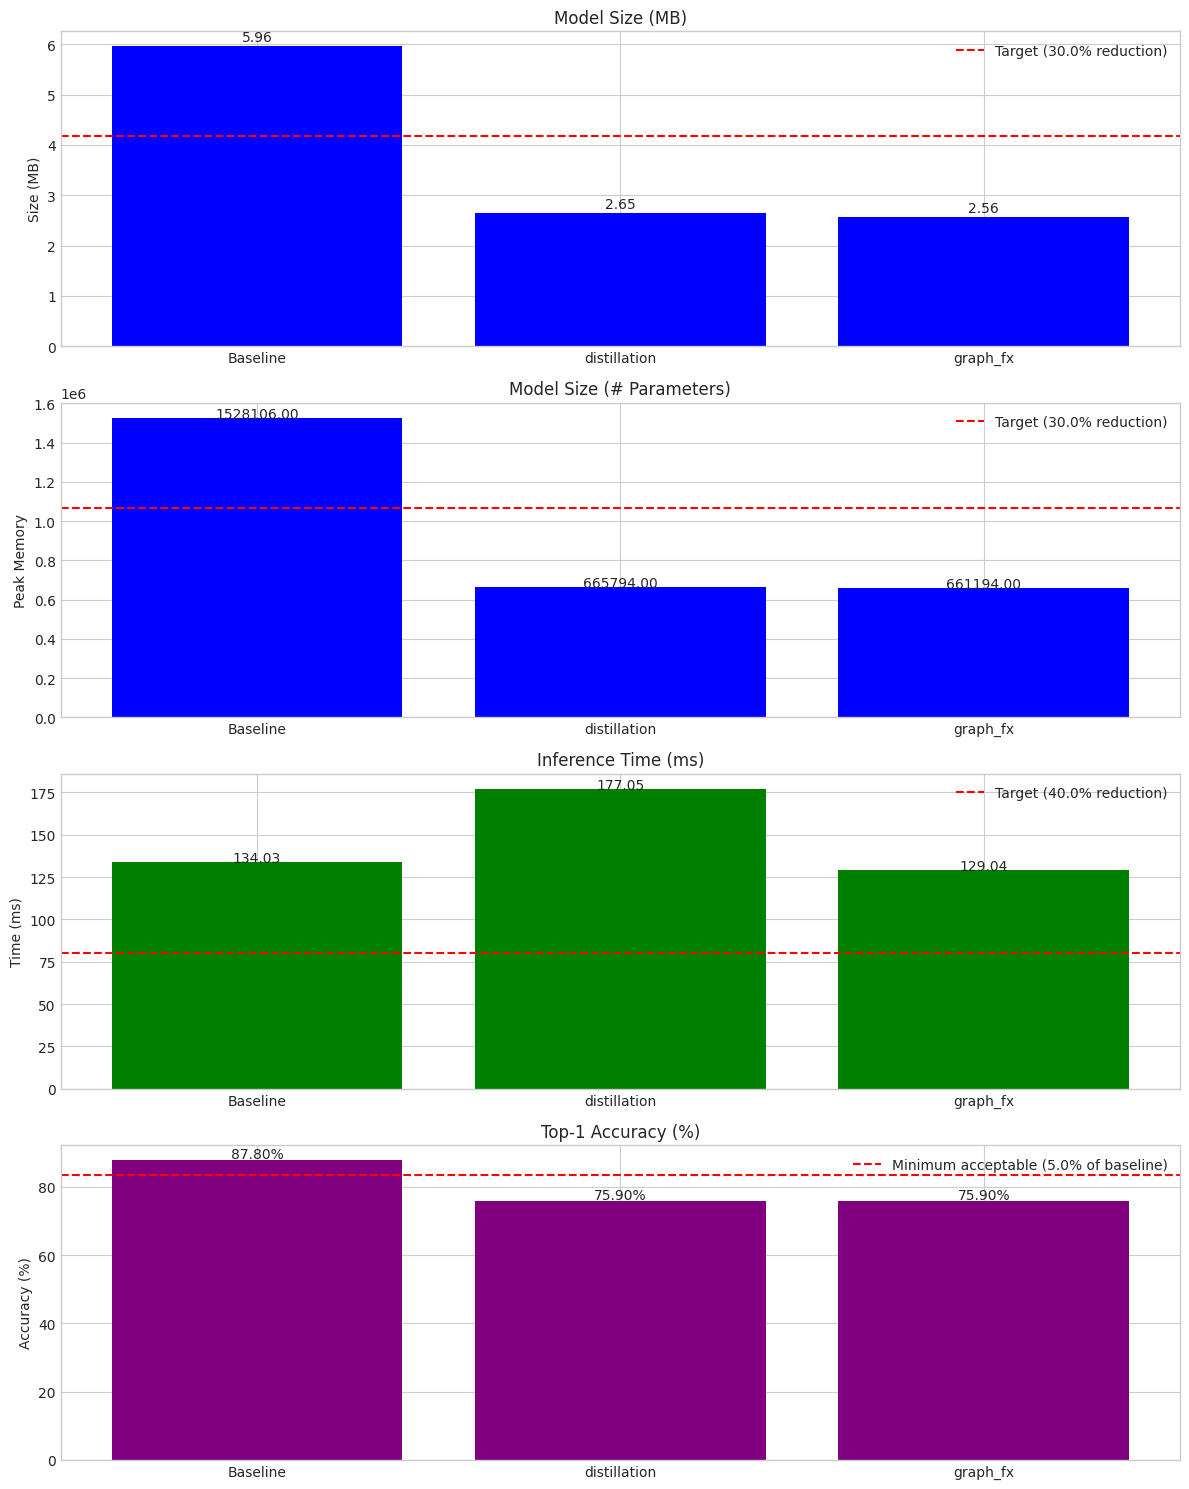


Pipeline pipeline_d_distill_first_fx Results Summary

Model Size (MB):
  Baseline: 5.96 MB
  Final: 2.56 MB
  Reduction: 57.01%
  Meets target (30.0% reduction)

Model Size (# Parameters):
  Baseline: 1528106.00 MB
  Final: 661194.00 MB
  Reduction: 56.73%
  Meets target (30.0% reduction)

Inference Time (CPU):
  Baseline: 134.03 ms
  Final: 129.04 ms
  Reduction: 3.72%
  Does not meet target (Goal: 80.42 ms)

Accuracy:
  Baseline: 87.80%
  Final: 75.90%
  Change: -13.55%
  Does not meet target (Goal: >=83.41%)

Overall Assessment:
  Pipeline does not meet all requirements


In [11]:
# Pipeline D: distillation-first, quantization-free.
# Step 4.0 showed int8 gives no real speedup here (1.04x) and collapses accuracy to ~16%
# regardless of backend, so Pipeline D relies on distillation + graph fusion instead.

train_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
report_device = torch.device('cpu')

pipeline_name_d = "pipeline_d_distill_first_fx"
pipeline_d = OptimizationPipeline(
    name=pipeline_name_d,
    baseline_model=baseline_model,
    train_loader=train_loader,
    test_loader=test_loader,
    class_names=class_names,
    input_size=input_size,
)
pipeline_d.add_step(
    "distillation",
    apply_knowledge_distillation,
    device=train_device,
    width_mult=0.75,      # wider student than B/C (0.6) to retain accuracy
    linear_size=256,
    dropout=0.2,
    num_epochs=40,        # longer schedule: B/C were under-trained at 20 epochs
    alpha=0.7,
    temperature=4.0,
).add_step(
    "graph_fx",
    apply_graph_optimization,
    optimization_method="torch_fx",
)
optimized_model_d = pipeline_d.run(device=report_device)
pipeline_d.visualize_results(baseline_metrics, report_device)
try:
    all_pipelines[pipeline_name_d] = pipeline_d
except NameError:
    all_pipelines = {pipeline_name_d: pipeline_d}

#### Pipeline E: lower input resolution sweep (measure the best, don't assume)

Pipeline D showed distillation + graph fusion keeps accuracy usable (~76%) but leaves
**CPU speed** and **accuracy** short of the CTO targets. The single biggest CPU cost is the
`F.interpolate(x, 224x224)` inside the student's `forward`. Pipeline E attacks that directly by
lowering the backbone's working resolution, and **sweeps two resolutions so the best is measured
rather than assumed**:

- **Resolution sweep 128 vs 112** (`input_size`): fewer pixels cut CPU latency roughly
  quadratically ($\left(\tfrac{128}{224}\right)^2 \approx 0.33$, $\left(\tfrac{112}{224}\right)^2
  = 0.25$). 112 is faster; 128 keeps more spatial detail. We run both and keep the winner.
- **Student `width_mult=0.85`** (vs D's 0.75): a modest capacity bump to offset the smaller input
  *without* inflating model size. Full width (1.0) would risk breaching the $\leq 4.17$ MB size
  target, so 0.85 keeps size headroom while still helping accuracy.
- **No int8 quantization** (Step 4.0 showed it collapses MobileNetV3 accuracy for ~0 real
  speedup) — distillation + `torch_fx` fusion only.

Each config registers into `all_pipelines`, so the final comparison table ranks them alongside
A-D and `final_pipeline_name` picks the overall best. If neither clears the speed target, lower
the sweep further (96); if accuracy is short, raise `num_epochs` or `linear_size`.


############################################################
# Pipeline E sweep: input_size=128  (pipeline_e_res128_distill_fx)
############################################################

Running pipeline: pipeline_e_res128_distill_fx


--------------------------------------------------
Step 1: distillation
--------------------------------------------------

Student parameters: 797,002
Teacher parameters: 1,528,106
Training with knowledge distillation for 40 epochs
Temperature: 4.0, Alpha: 0.7


Epoch 1/40 [Test]: 100%|██████████| 8/8 [00:00<00:00,  9.42it/s, loss=2.57, acc=21.5]


Epoch 1/40 - Train Loss: 10.9472, Train Acc: 17.56%, Test Loss: 2.2519, Test Acc: 21.50%, LR: 0.000998, Time: 8.64s
New best student model! Saving... (21.50%)
Model saved to ../models/pipeline/pipeline_e_res128_distill_fx/checkpoints/pipeline_e_res128_distill_fx_distill.pth


Epoch 2/40 [Test]: 100%|██████████| 8/8 [00:00<00:00, 12.29it/s, loss=2.66, acc=36.3]


Epoch 2/40 - Train Loss: 9.6084, Train Acc: 28.28%, Test Loss: 1.9929, Test Acc: 36.30%, LR: 0.000994, Time: 8.37s
New best student model! Saving... (36.30%)
Model saved to ../models/pipeline/pipeline_e_res128_distill_fx/checkpoints/pipeline_e_res128_distill_fx_distill.pth


...

Epoch 40/40 - Train Loss: 2.0758, Train Acc: 83.06%, Test Loss: 1.3102, Test Acc: 72.30%, LR: 0.000000, Time: 8.07s
Distillation completed. Best student accuracy: 72.40%
Best student model saved as '../models/pipeline/pipeline_e_res128_distill_fx/checkpoints/pipeline_e_res128_distill_fx_distill.pth' at epoch 38

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:11<00:00,  1.47s/it]


Baseline metrics saved at ../results/pipeline/pipeline_e_res128_distill_fx/step01_distillation/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:10<00:00,  1.28s/it]


Confusion matrix saved to ../results/pipeline/pipeline_e_res128_distill_fx/step01_distillation/confusion_matrix.png


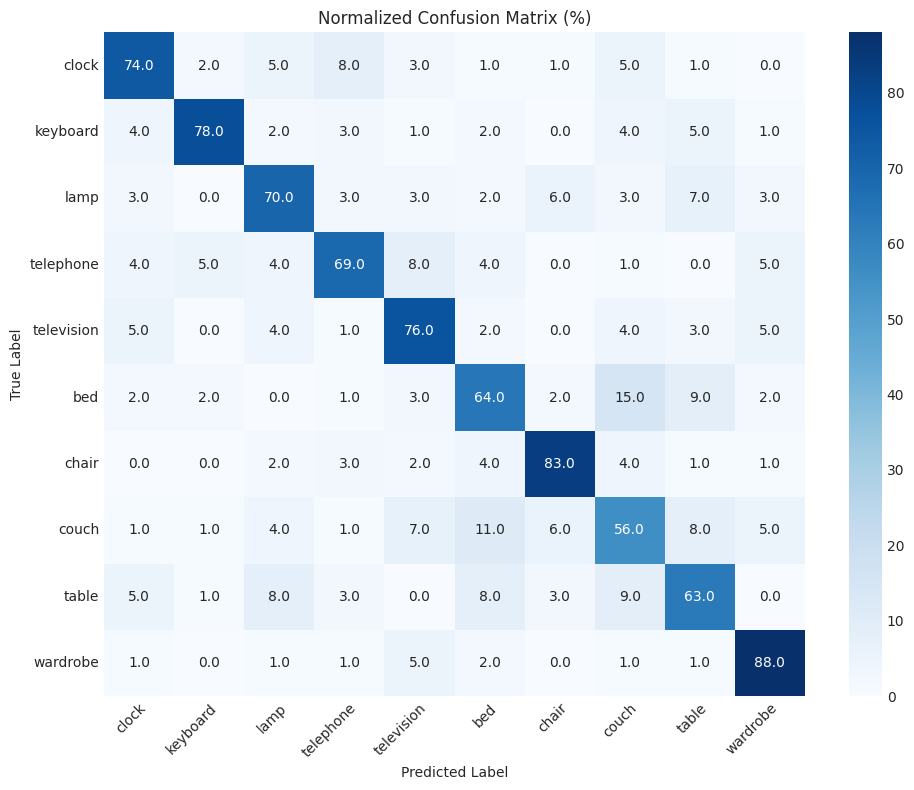


Optimized Model Metrics (pipeline/pipeline_e_res128_distill_fx/step01_distillation):
Accuracy: 72.10%
Model Size: 3.16 MB
CPU Inference Time: 104.02 ms (9.61 FPS)
CUDA Inference Time: 5.76 ms (173.50 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:37<00:00,  4.70s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:13<00:00,  1.66s/it]


Model comparison plot saved to ../results/pipeline/pipeline_e_res128_distill_fx/step01_distillation/comparison.png


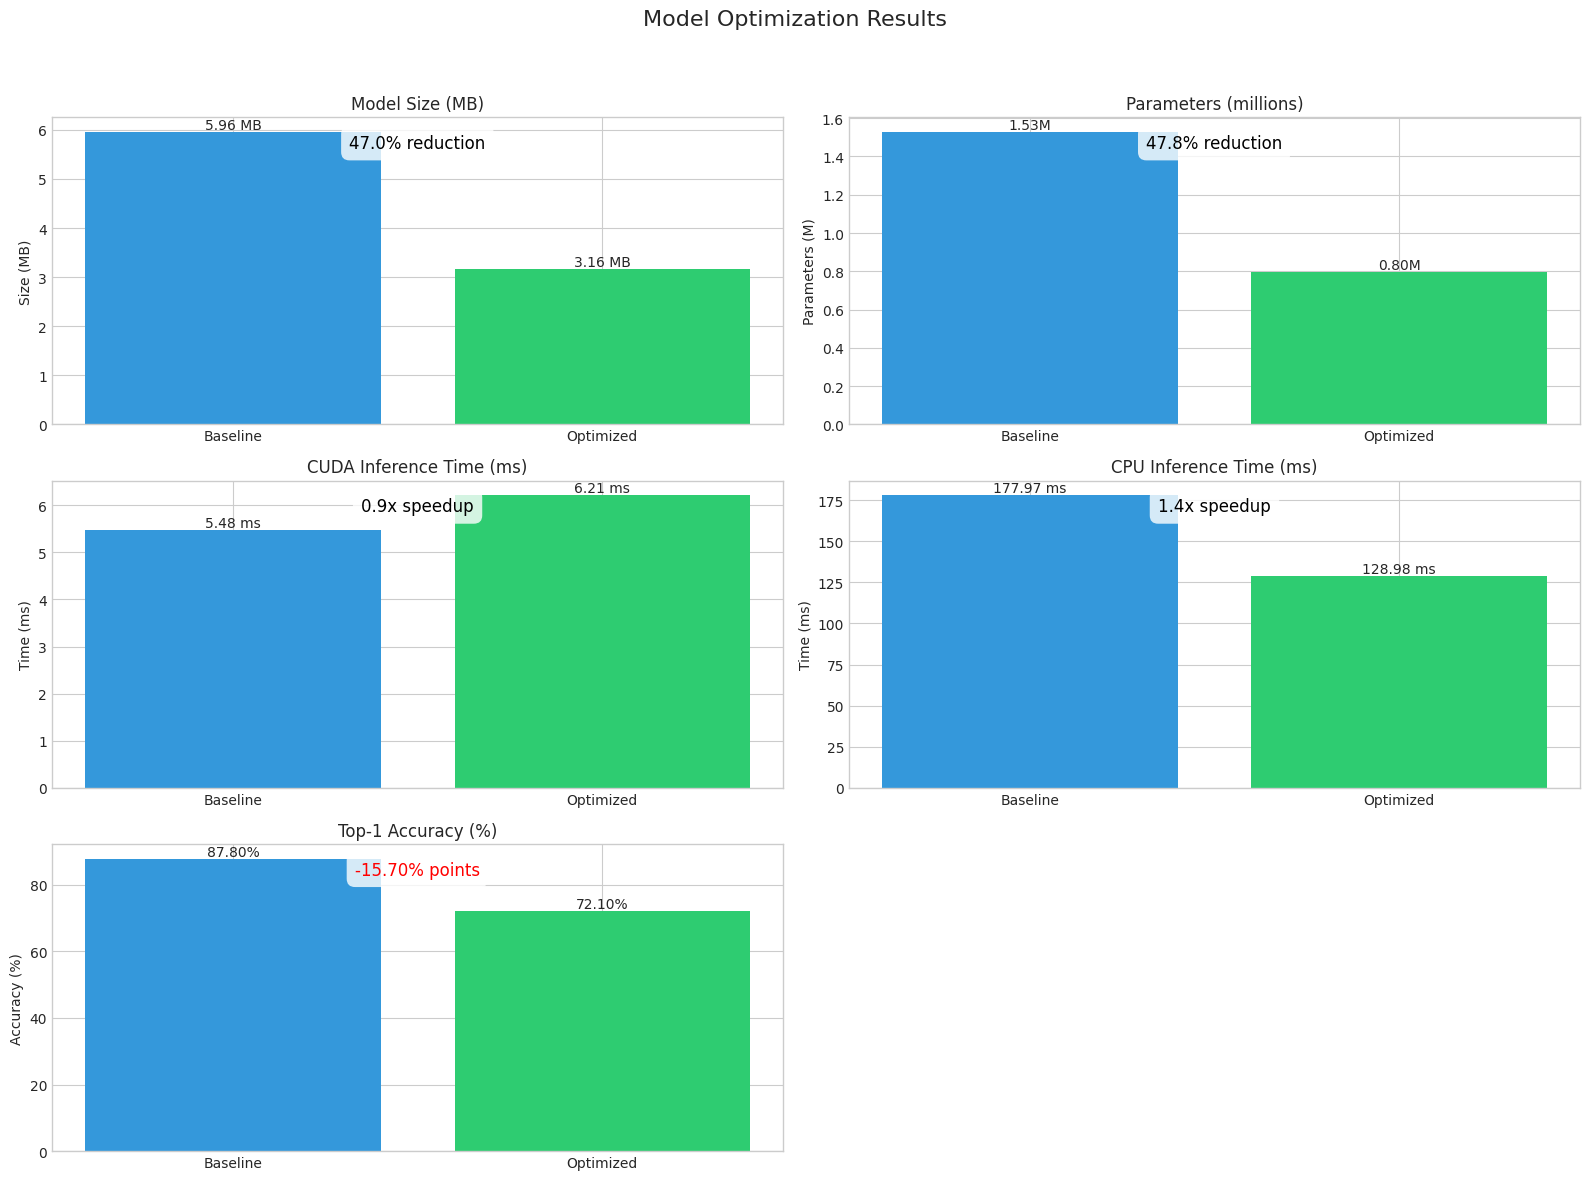


pipeline/pipeline_e_res128_distill_fx/step01_distillation Results:
Model Size: 3.16 MB (47.0% reduction)
Parameters: 797,002 (47.8% reduction)
CPU Inference Time: 128.98 ms (1.4x speedup)
CUDA Inference Time: 6.21 ms (0.9x speedup)
Accuracy: 72.10% (-15.70% change)
Requirements met: False
Completed distillation in 466.94s

--------------------------------------------------
Step 2: graph_fx
--------------------------------------------------

Step failed: graph_fx
symbolically traced variables cannot be used as inputs to control flow
Model saved to ../models/pipeline/pipeline_e_res128_distill_fx/model.pth

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:13<00:00,  1.66s/it]


Baseline metrics saved at ../results/pipeline/pipeline_e_res128_distill_fx/final/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:12<00:00,  1.56s/it]


Confusion matrix saved to ../results/pipeline/pipeline_e_res128_distill_fx/final/confusion_matrix.png


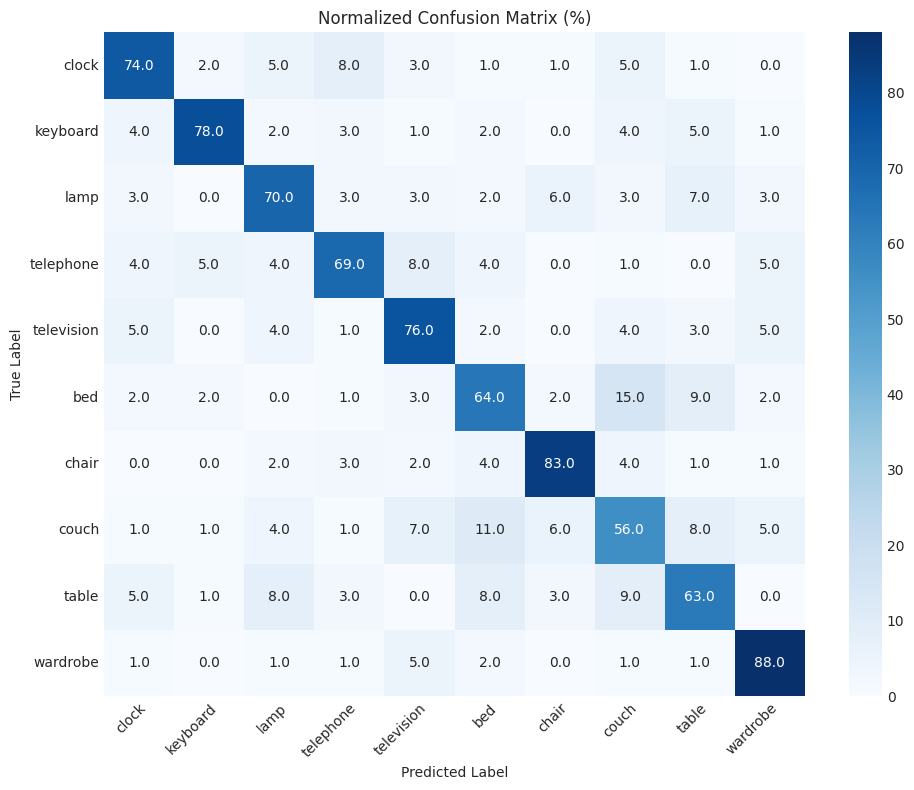


Optimized Model Metrics (pipeline/pipeline_e_res128_distill_fx/final):
Accuracy: 72.10%
Model Size: 3.16 MB
CPU Inference Time: 154.96 ms (6.45 FPS)
CUDA Inference Time: 5.95 ms (168.18 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:38<00:00,  4.76s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:13<00:00,  1.70s/it]


Model comparison plot saved to ../results/pipeline/pipeline_e_res128_distill_fx/final/comparison.png


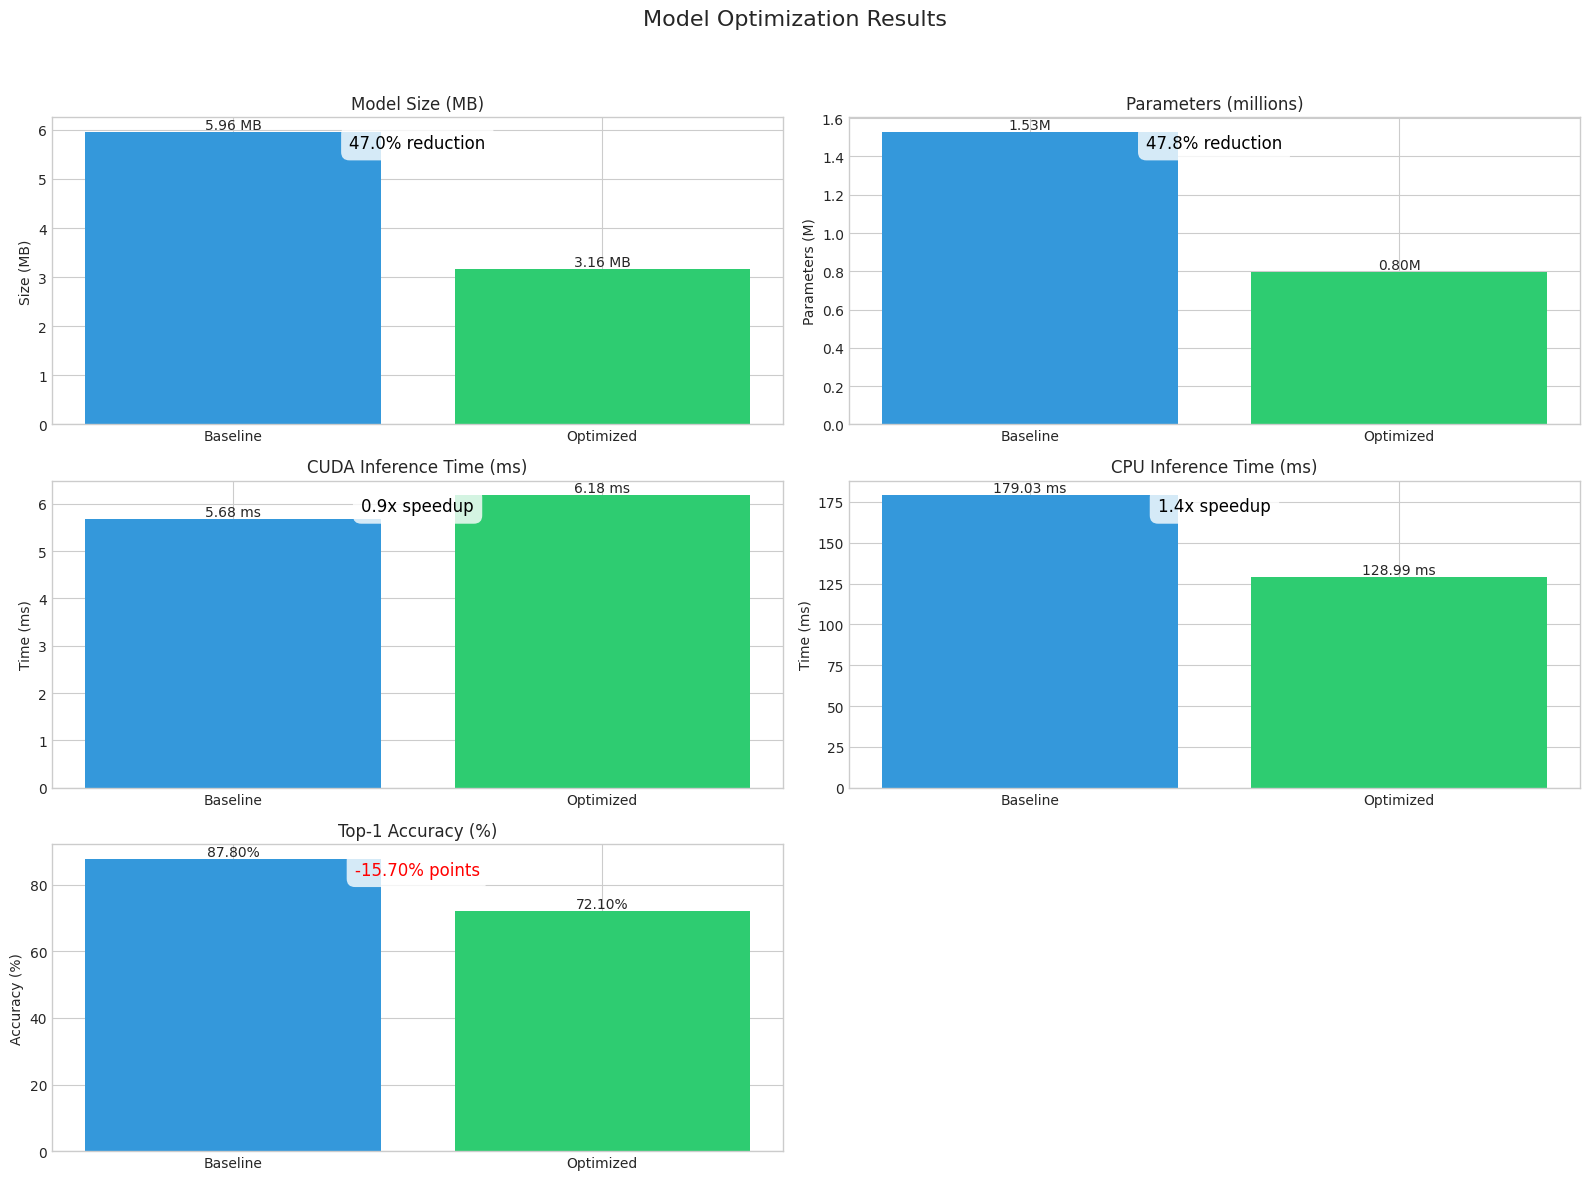


pipeline/pipeline_e_res128_distill_fx/final Results:
Model Size: 3.16 MB (47.0% reduction)
Parameters: 797,002 (47.8% reduction)
CPU Inference Time: 128.99 ms (1.4x speedup)
CUDA Inference Time: 6.18 ms (0.9x speedup)
Accuracy: 72.10% (-15.70% change)
Requirements met: False

Pipeline pipeline_e_res128_distill_fx completed
Final model path: ../models/pipeline/pipeline_e_res128_distill_fx/model.pth



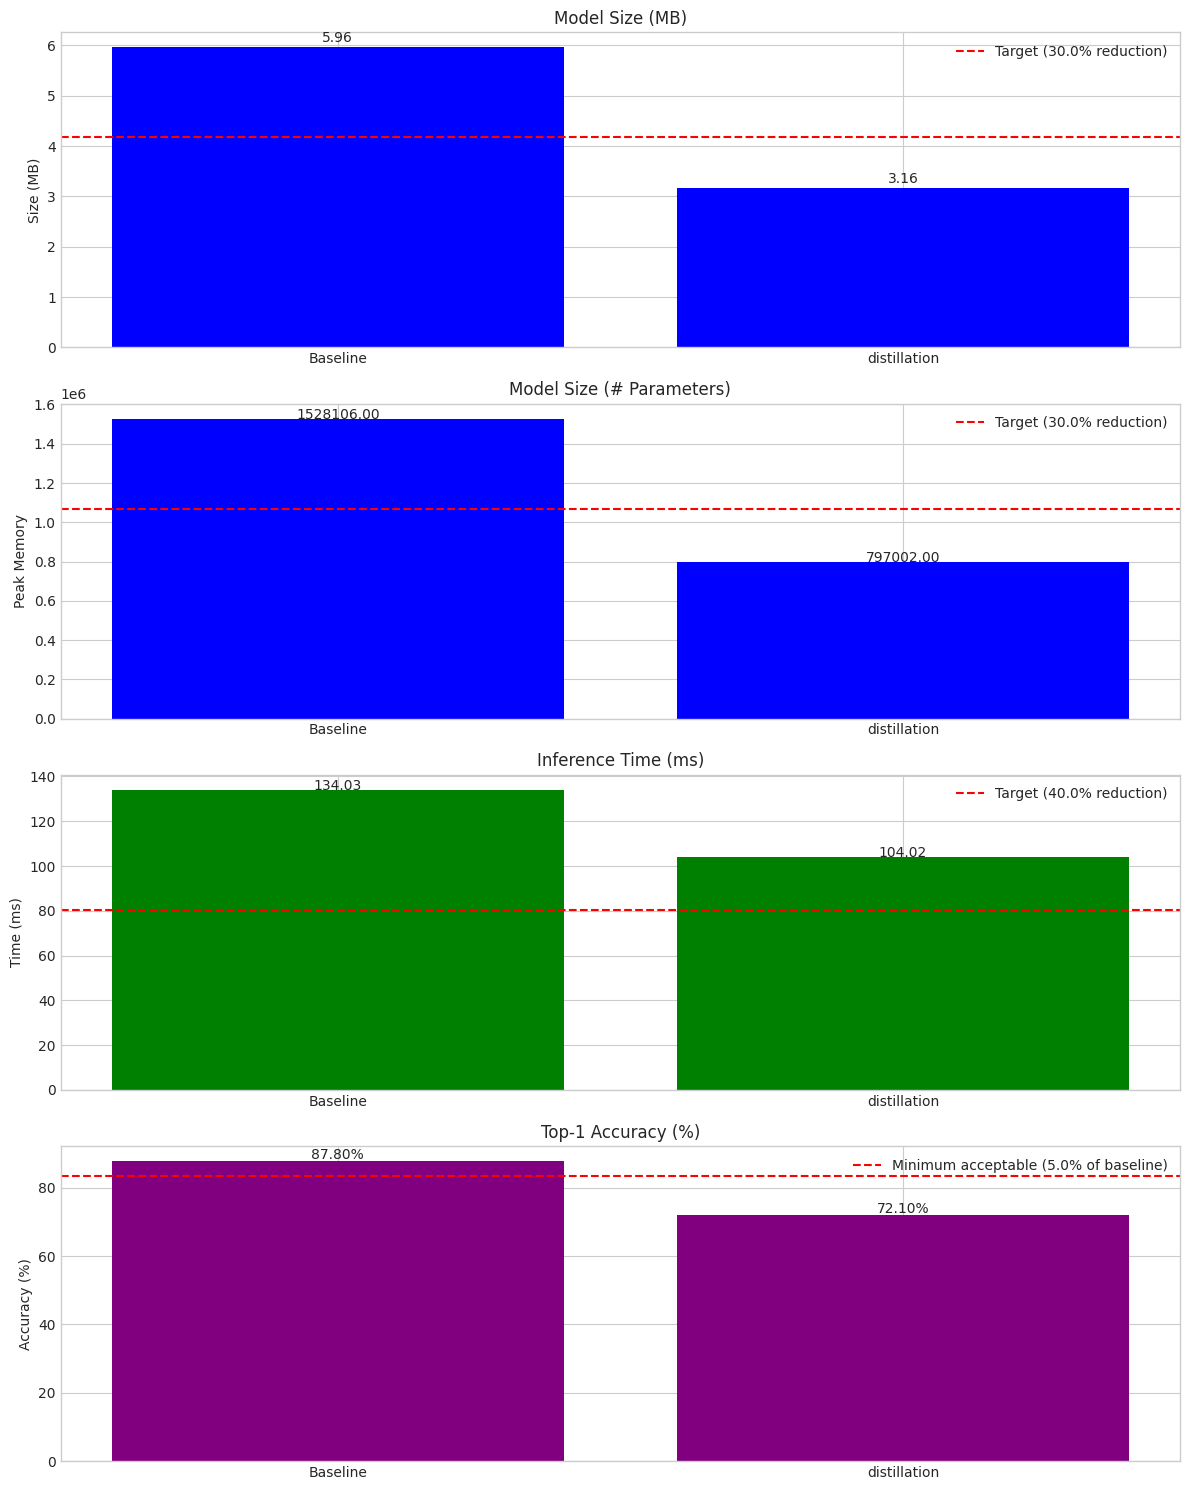


Pipeline pipeline_e_res128_distill_fx Results Summary

Model Size (MB):
  Baseline: 5.96 MB
  Final: 3.16 MB
  Reduction: 46.98%
  Meets target (30.0% reduction)

Model Size (# Parameters):
  Baseline: 1528106.00 MB
  Final: 797002.00 MB
  Reduction: 47.84%
  Meets target (30.0% reduction)

Inference Time (CPU):
  Baseline: 134.03 ms
  Final: 104.02 ms
  Reduction: 22.39%
  Does not meet target (Goal: 80.42 ms)

Accuracy:
  Baseline: 87.80%
  Final: 72.10%
  Change: -17.88%
  Does not meet target (Goal: >=83.41%)

Overall Assessment:
  Pipeline does not meet all requirements

############################################################
# Pipeline E sweep: input_size=112  (pipeline_e_res112_distill_fx)
############################################################

Running pipeline: pipeline_e_res112_distill_fx


--------------------------------------------------
Step 1: distillation
--------------------------------------------------

Student parameters: 797,002
Teacher parameters: 1,528

Epoch 1/40 [Test]: 100%|██████████| 8/8 [00:00<00:00,  8.25it/s, loss=2.37, acc=32]  


Epoch 1/40 - Train Loss: 10.7963, Train Acc: 20.56%, Test Loss: 2.0714, Test Acc: 32.00%, LR: 0.000998, Time: 8.74s
New best student model! Saving... (32.00%)
Model saved to ../models/pipeline/pipeline_e_res112_distill_fx/checkpoints/pipeline_e_res112_distill_fx_distill.pth


Epoch 2/40 [Test]: 100%|██████████| 8/8 [00:00<00:00, 10.73it/s, loss=2.07, acc=39.5]


Epoch 2/40 - Train Loss: 9.1213, Train Acc: 32.50%, Test Loss: 2.0745, Test Acc: 39.50%, LR: 0.000994, Time: 8.19s
New best student model! Saving... (39.50%)
Model saved to ../models/pipeline/pipeline_e_res112_distill_fx/checkpoints/pipeline_e_res112_distill_fx_distill.pth


...

Epoch 40/40 - Train Loss: 2.4213, Train Acc: 79.68%, Test Loss: 1.4335, Test Acc: 69.00%, LR: 0.000000, Time: 7.27s
Distillation completed. Best student accuracy: 69.10%
Best student model saved as '../models/pipeline/pipeline_e_res112_distill_fx/checkpoints/pipeline_e_res112_distill_fx_distill.pth' at epoch 35

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:11<00:00,  1.43s/it]


Baseline metrics saved at ../results/pipeline/pipeline_e_res112_distill_fx/step01_distillation/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:10<00:00,  1.32s/it]


Confusion matrix saved to ../results/pipeline/pipeline_e_res112_distill_fx/step01_distillation/confusion_matrix.png


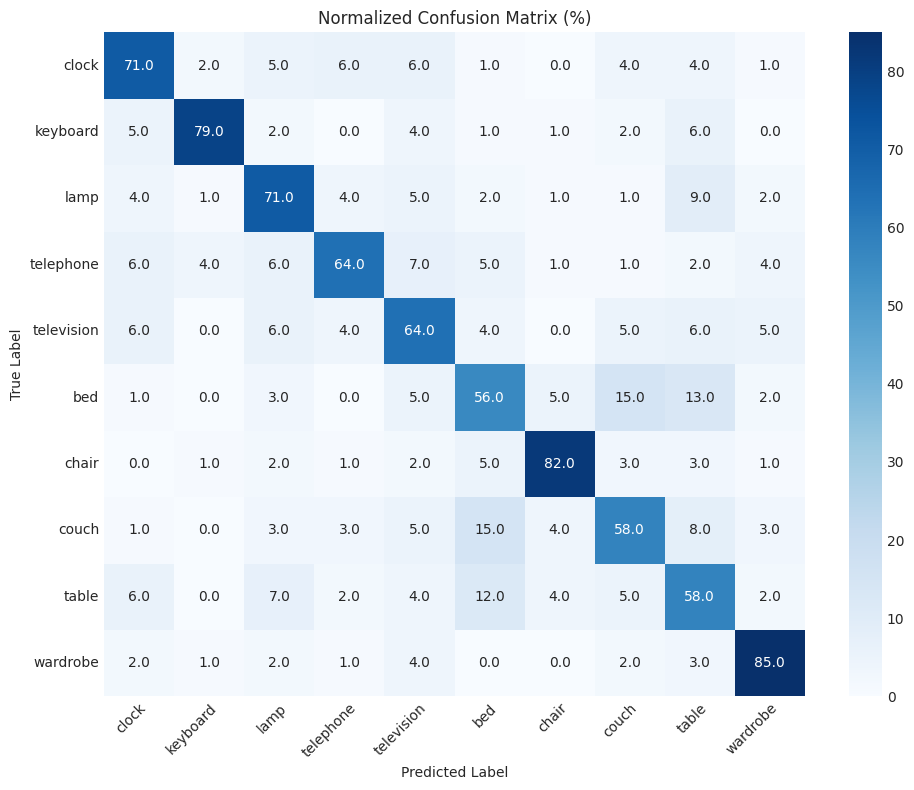


Optimized Model Metrics (pipeline/pipeline_e_res112_distill_fx/step01_distillation):
Accuracy: 68.80%
Model Size: 3.16 MB
CPU Inference Time: 136.04 ms (7.35 FPS)
CUDA Inference Time: 5.46 ms (183.08 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:34<00:00,  4.28s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:10<00:00,  1.36s/it]


Model comparison plot saved to ../results/pipeline/pipeline_e_res112_distill_fx/step01_distillation/comparison.png


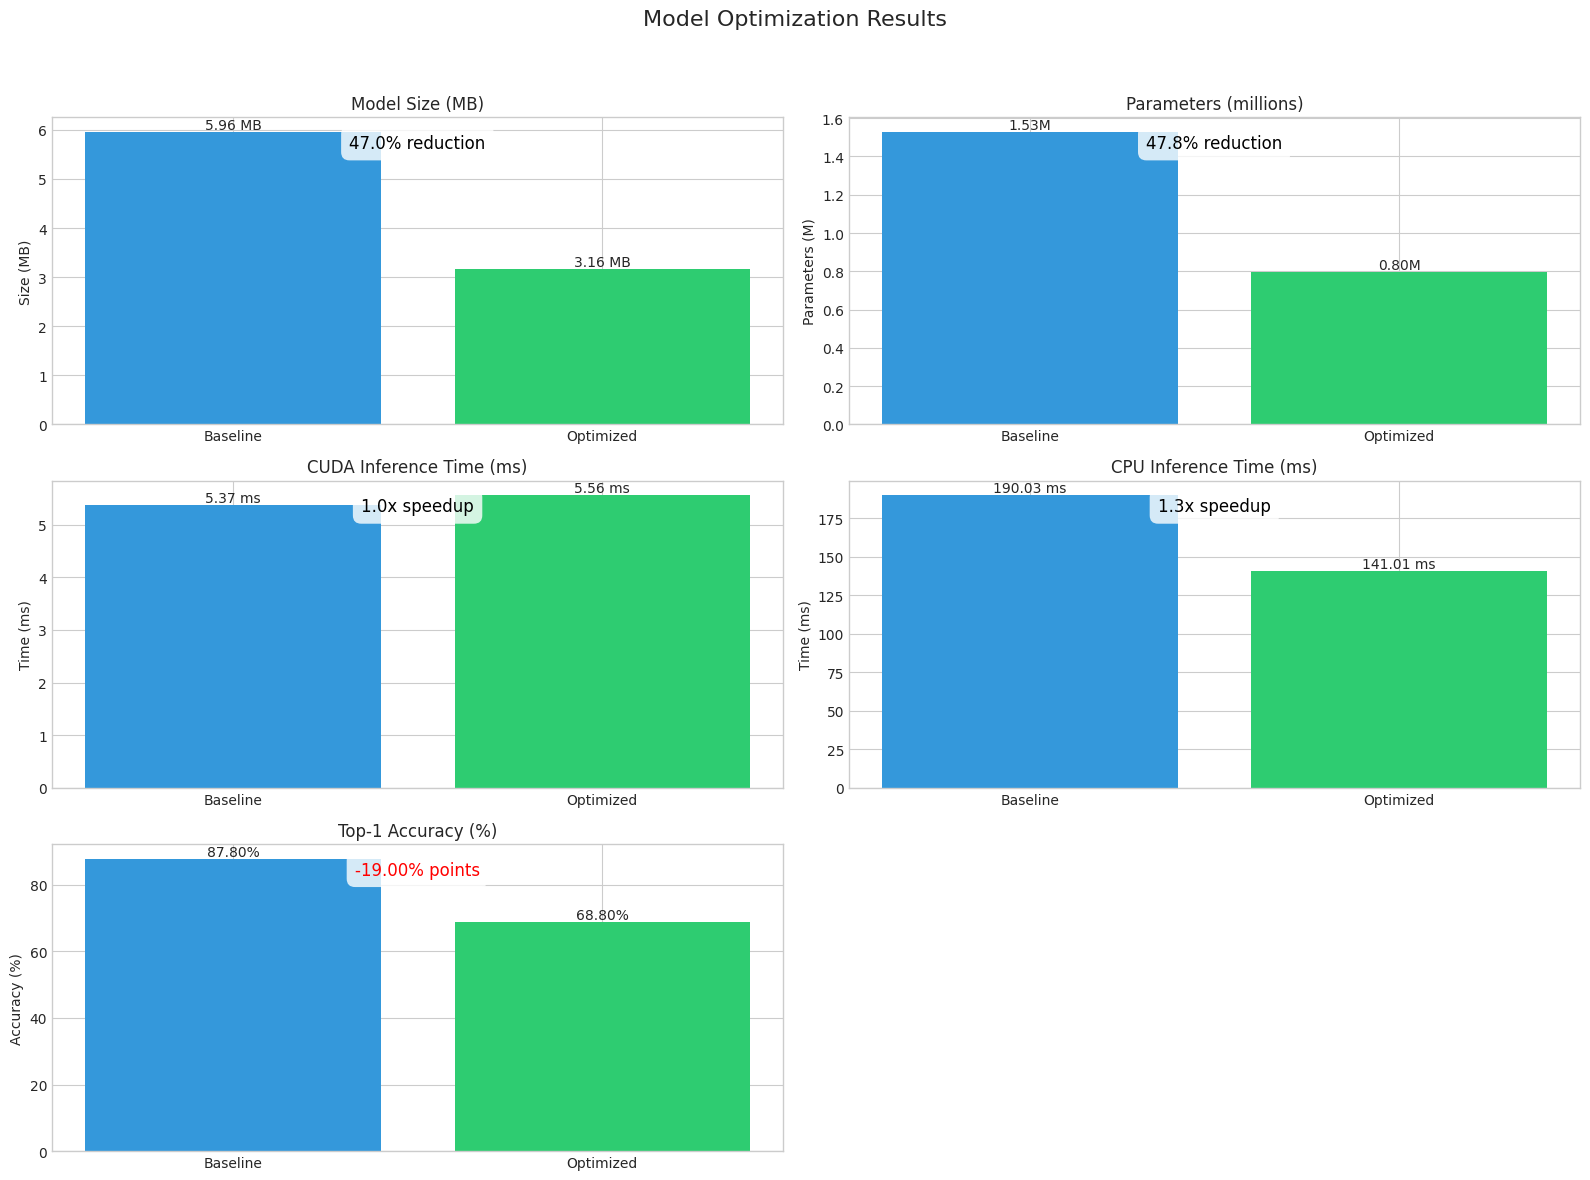


pipeline/pipeline_e_res112_distill_fx/step01_distillation Results:
Model Size: 3.16 MB (47.0% reduction)
Parameters: 797,002 (47.8% reduction)
CPU Inference Time: 141.01 ms (1.3x speedup)
CUDA Inference Time: 5.56 ms (1.0x speedup)
Accuracy: 68.80% (-19.00% change)
Requirements met: False
Completed distillation in 506.43s

--------------------------------------------------
Step 2: graph_fx
--------------------------------------------------

Step failed: graph_fx
symbolically traced variables cannot be used as inputs to control flow
Model saved to ../models/pipeline/pipeline_e_res112_distill_fx/model.pth

Evaluating performance of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:11<00:00,  1.39s/it]


Baseline metrics saved at ../results/pipeline/pipeline_e_res112_distill_fx/final/metrics.json.


Calculating confusion matrix: 100%|██████████| 8/8 [00:10<00:00,  1.25s/it]


Confusion matrix saved to ../results/pipeline/pipeline_e_res112_distill_fx/final/confusion_matrix.png


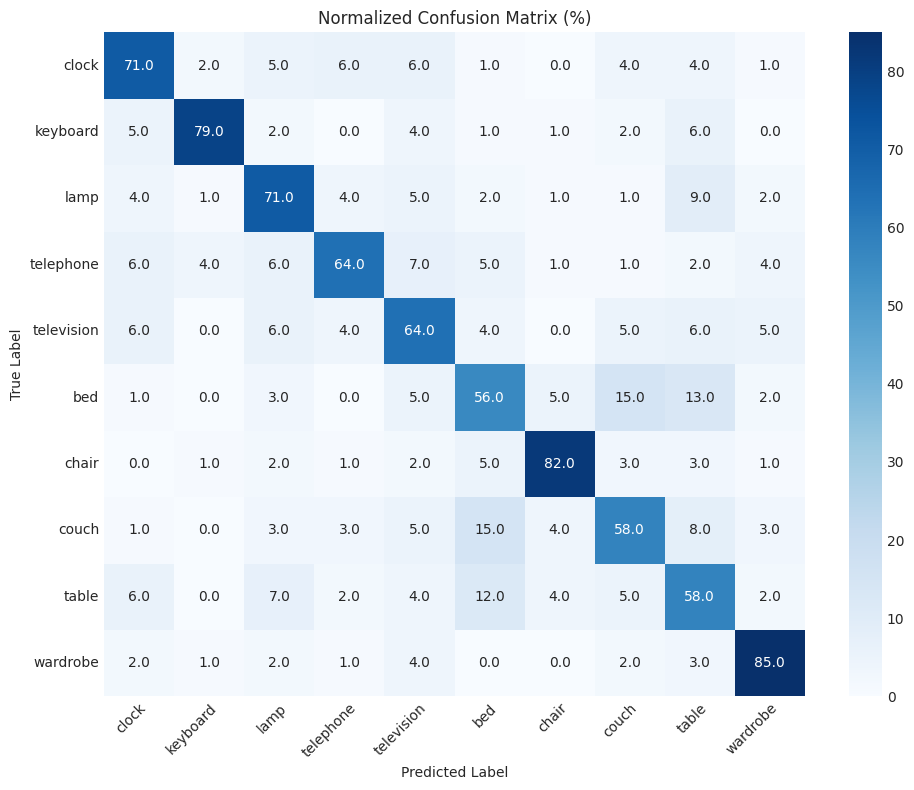


Optimized Model Metrics (pipeline/pipeline_e_res112_distill_fx/final):
Accuracy: 68.80%
Model Size: 3.16 MB
CPU Inference Time: 144.98 ms (6.90 FPS)
CUDA Inference Time: 5.37 ms (186.36 FPS)

Comparing performance of optimized model against baseline...
Get metrics of baseline model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:29<00:00,  3.74s/it]


Get metrics of optimized model...


Evaluating per-class accuracy: 100%|██████████| 8/8 [00:08<00:00,  1.07s/it]


Model comparison plot saved to ../results/pipeline/pipeline_e_res112_distill_fx/final/comparison.png


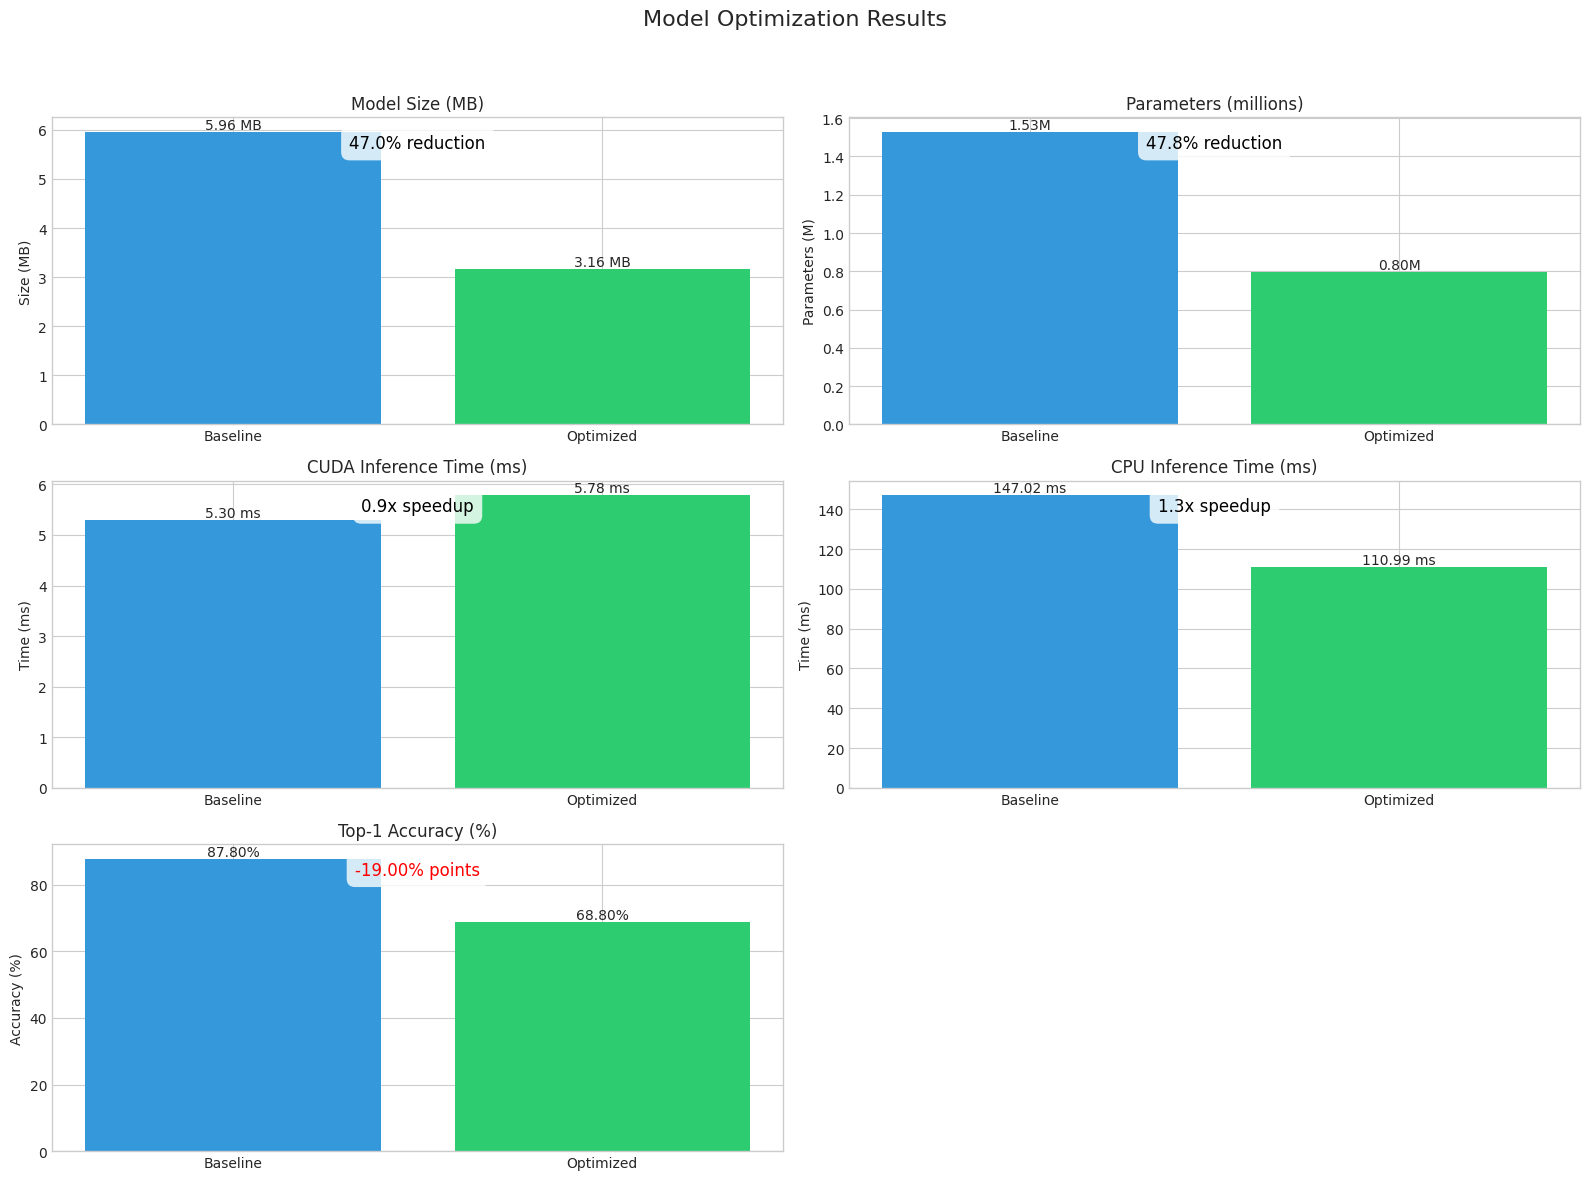


pipeline/pipeline_e_res112_distill_fx/final Results:
Model Size: 3.16 MB (47.0% reduction)
Parameters: 797,002 (47.8% reduction)
CPU Inference Time: 110.99 ms (1.3x speedup)
CUDA Inference Time: 5.78 ms (0.9x speedup)
Accuracy: 68.80% (-19.00% change)
Requirements met: False

Pipeline pipeline_e_res112_distill_fx completed
Final model path: ../models/pipeline/pipeline_e_res112_distill_fx/model.pth



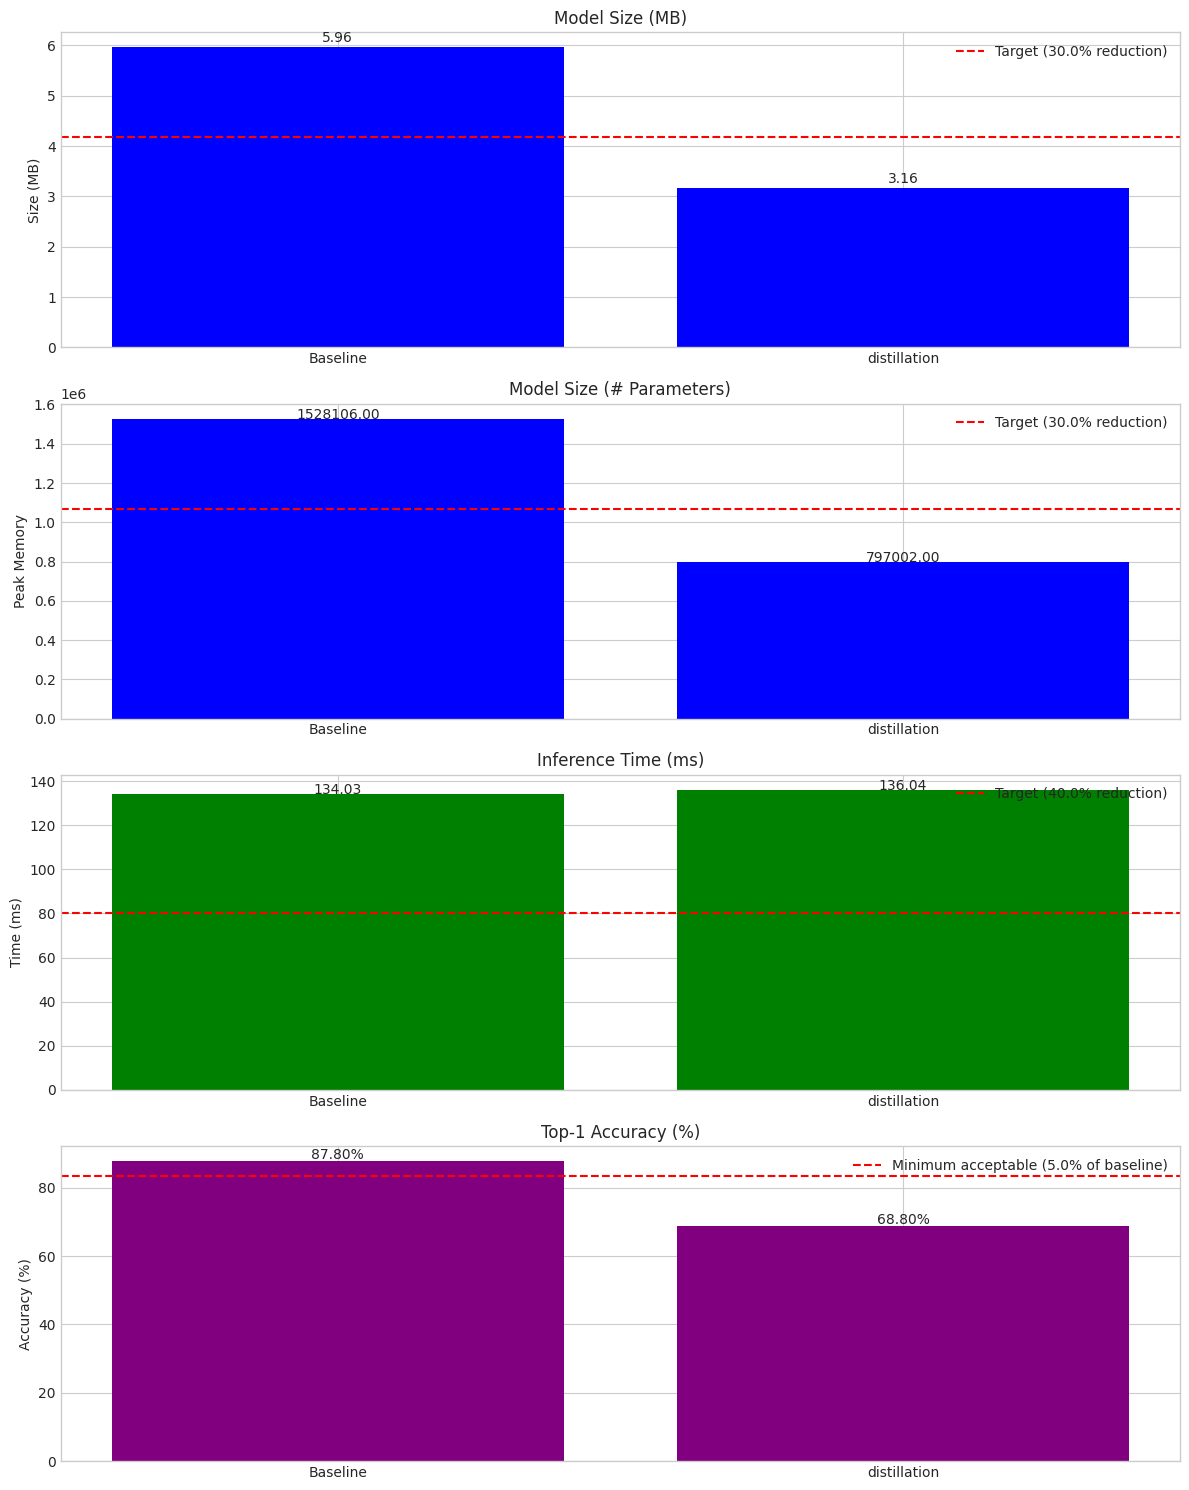


Pipeline pipeline_e_res112_distill_fx Results Summary

Model Size (MB):
  Baseline: 5.96 MB
  Final: 3.16 MB
  Reduction: 46.98%
  Meets target (30.0% reduction)

Model Size (# Parameters):
  Baseline: 1528106.00 MB
  Final: 797002.00 MB
  Reduction: 47.84%
  Meets target (30.0% reduction)

Inference Time (CPU):
  Baseline: 134.03 ms
  Final: 136.04 ms
  Reduction: -1.50%
  Does not meet target (Goal: 80.42 ms)

Accuracy:
  Baseline: 87.80%
  Final: 68.80%
  Change: -21.64%
  Does not meet target (Goal: >=83.41%)

Overall Assessment:
  Pipeline does not meet all requirements

Pipeline E resolution sweep summary
pipeline_e_res128_distill_fx        size=3.16MB  cpu_speedup=1.39x  acc=72.10%
pipeline_e_res112_distill_fx        size=3.16MB  cpu_speedup=1.32x  acc=68.80%


In [11]:
# Pipeline E: sweep two input resolutions (128 vs 112) at width 0.85, then graph fusion.
# Goal: pass the CPU-speed target (via the smaller interpolate) AND the accuracy floor,
# while keeping model size safely under target (width 0.85, not 1.0). No int8 (destroys accuracy).

train_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
report_device = torch.device('cpu')

# (input_size, pipeline_name) configs to sweep. Both keep width_mult=0.85 for size headroom.
E_RESOLUTION_SWEEP = [
    (128, "pipeline_e_res128_distill_fx"),
    (112, "pipeline_e_res112_distill_fx"),
]

try:
    all_pipelines
except NameError:
    all_pipelines = {}

for e_input_size, e_name in E_RESOLUTION_SWEEP:
    print(f"\n{'#'*60}\n# Pipeline E sweep: input_size={e_input_size}  ({e_name})\n{'#'*60}")
    pipeline_e = OptimizationPipeline(
        name=e_name,
        baseline_model=baseline_model,
        train_loader=train_loader,
        test_loader=test_loader,
        class_names=class_names,
        input_size=input_size,
    )
    pipeline_e.add_step(
        "distillation",
        apply_knowledge_distillation,
        device=train_device,
        width_mult=0.85,          # modest capacity bump vs D (0.75); avoids the size risk of 1.0
        linear_size=256,
        dropout=0.2,
        num_epochs=40,
        alpha=0.7,
        temperature=4.0,
        input_size=e_input_size,  # the swept CPU-latency lever (quadratic in resolution)
    ).add_step(
        "graph_fx",
        apply_graph_optimization,
        optimization_method="torch_fx",
    )
    pipeline_e.run(device=report_device)
    pipeline_e.visualize_results(baseline_metrics, report_device)
    all_pipelines[e_name] = pipeline_e

# Quick side-by-side of the two E configs (full ranking vs A-D is in the summary cell below).
print(f"\n{'='*60}\nPipeline E resolution sweep summary\n{'='*60}")
for _, e_name in E_RESOLUTION_SWEEP:
    fc = all_pipelines[e_name].results.get("final_comparison", {})
    print(
        f"{e_name:35s} "
        f"size={fc.get('model_size_mb', float('nan')):.2f}MB  "
        f"cpu_speedup={fc.get('cpu_inference_speedup', float('nan')):.2f}x  "
        f"acc={fc.get('accuracy', float('nan')):.2f}%"
    )

#### Final comparison table (rebuild from in-memory results)

The extraction inside the Pipelines A/B/C cell previously read a nested
`improvements`/`optimized` schema that `compare_optimized_model_to_baseline()` does not
return (it returns a **flat** result dict), so every row came out `None`. The cell below
rebuilds `pipeline_summary_df` from the pipelines already in memory (`all_pipelines`,
including Pipeline D) using the correct flat keys, so you get the populated table
**without re-running any pipeline**.

In [12]:
# Rebuild the final comparison table from in-memory pipeline results (no re-run needed).
# compare_optimized_model_to_baseline() returns a FLAT dict; read those keys directly.
rows = []
for name, p in all_pipelines.items():
    fc = p.results.get("final_comparison", {})
    rows.append({
        "pipeline": name,
        "size_mb": fc.get("model_size_mb"),
        "size_reduction": fc.get("size_reduction"),
        "cpu_ms": fc.get("cpu_inference_time_ms"),
        "cpu_speedup": fc.get("cpu_inference_speedup"),
        "top1_acc": fc.get("accuracy"),
        "accuracy_change": fc.get("accuracy_change"),
        "all_reqs_met": fc.get("requirements_met"),
    })

pipeline_summary_df = pd.DataFrame(rows)

# CTO thresholds (fractions / ratios matching the flat result dict units).
size_thr = TARGET_MODEL_COMPRESSION                      # >= 0.30
speed_thr = 1.0 / (1.0 - TARGET_INFERENCE_SPEEDUP)       # >= 1.667x
acc_thr = -MAX_ALLOWED_ACCURACY_DROP                     # >= -0.05

if not pipeline_summary_df.empty:
    df_show = pipeline_summary_df.copy()
    df_show["size_reduction"] = (df_show["size_reduction"] * 100).round(1).astype(str) + "%"
    df_show["cpu_speedup"] = df_show["cpu_speedup"].round(2).astype(str) + "x"
    df_show["accuracy_change"] = (df_show["accuracy_change"] * 100).round(1).astype(str) + "%"
    df_show["meets_all"] = [
        "PASS" if (sr >= size_thr and (sp or 0) >= speed_thr and ac >= acc_thr) else "FAIL"
        for sr, sp, ac in zip(
            pipeline_summary_df["size_reduction"].fillna(-1),
            pipeline_summary_df["cpu_speedup"].fillna(0),
            pipeline_summary_df["accuracy_change"].fillna(-1),
        )
    ]
    display(df_show.sort_values(by="top1_acc", ascending=False))

# Recommend the best pipeline: prefer any that meets all constraints, else highest accuracy.
final_pipeline_name = None
if not pipeline_summary_df.empty:
    meets = pipeline_summary_df[
        (pipeline_summary_df["size_reduction"].fillna(-1) >= size_thr)
        & (pipeline_summary_df["cpu_speedup"].fillna(0) >= speed_thr)
        & (pipeline_summary_df["accuracy_change"].fillna(-1) >= acc_thr)
    ]
    if not meets.empty:
        final_pipeline_name = meets.sort_values(by="top1_acc", ascending=False).iloc[0]["pipeline"]
        print(f"Recommended final pipeline (meets ALL constraints): {final_pipeline_name}")
    else:
        final_pipeline_name = pipeline_summary_df.sort_values(by="top1_acc", ascending=False).iloc[0]["pipeline"]
        print("No pipeline meets all three CTO constraints.")
        print(f"Best available by accuracy: {final_pipeline_name} "
              f"({pipeline_summary_df.set_index('pipeline').loc[final_pipeline_name, 'top1_acc']:.2f}% top-1)")

,pipeline,size_mb,size_reduction,cpu_ms,cpu_speedup,top1_acc,accuracy_change,all_reqs_met,meets_all
0,pipeline_e_res128_distill_fx,3.159777,47.0%,128.986406,1.39x,72.1,-15.7%,False,FAIL
1,pipeline_e_res112_distill_fx,3.159777,47.0%,110.992255,1.32x,68.8,-19.0%,False,FAIL


No pipeline meets all three CTO constraints.
Best available by accuracy: pipeline_e_res128_distill_fx (72.10% top-1)


### Step 5: Compare All Pipelines

Let's compare the results of all pipelines to determine which one best meets our requirements.

Note that, for simplicity, we re-use the `compare_experiments()` function which will return each step of each pipeline and not final pipeline results all-together.

In [13]:
# Compare all implemented pipelines
pipeline_experiments = [os.path.join('pipeline', exp_name) for exp_name in list_experiments("../results/pipeline/")]

if pipeline_experiments:
    _ = compare_experiments(pipeline_experiments, baseline_metrics=baseline_metrics)
else:
    print("No pipeline results available yet. Please run at least one pipeline.")


Comparison of All Compression Techniques:



,Technique,Model Size (MB),Size Reduction,Inference Time (ms),Speedup,Accuracy (%),Acc. Change,All Reqs Met
0,pipeline/pipeline_a_prune_fx_ptq/final,1.75,70.6%,85.98,1.6x,18.90,-78.5%,✗
1,pipeline/pipeline_a_prune_fx_ptq/step01_post_p...,5.96,0.1%,139.00,1.0x,86.00,-2.1%,✗
2,pipeline/pipeline_a_prune_fx_ptq/step02_graph_fx,5.85,1.9%,151.01,0.9x,86.00,-2.1%,✗
3,pipeline/pipeline_a_prune_fx_ptq/step03_static...,1.75,70.6%,82.08,1.6x,18.90,-78.5%,✗
4,pipeline/pipeline_b_distill_fx_ptq/final,0.64,89.2%,118.99,1.1x,62.10,-29.3%,✗
5,pipeline/pipeline_b_distill_fx_ptq/step01_dist...,1.80,69.7%,173.93,0.8x,62.70,-28.6%,✗
6,pipeline/pipeline_b_distill_fx_ptq/step02_grap...,1.72,71.1%,135.98,1.0x,62.70,-28.6%,✗
7,pipeline/pipeline_b_distill_fx_ptq/step03_stat...,0.64,89.2%,110.03,1.2x,62.10,-29.3%,✗
8,pipeline/pipeline_c_distill_prune_fx_ptq/final,0.64,89.2%,120.00,1.1x,57.60,-34.4%,✗
9,pipeline/pipeline_c_distill_prune_fx_ptq/step0...,1.80,69.7%,152.07,0.9x,67.20,-23.5%,✗


--------

**TODO: Analyse the multi-step optimization results and collect lessons learnt from the optimization process**

Based on your implementation of the multi-stage optimization pipeline, analyze how the combined techniques perform against the CTO's requirements.

Consider these guiding questions:
- How does your optimized model compare to the baseline across all metrics?
- What contribution did each stage make to the final performance?
- What technical insights did you gain about optimizing MobileNetV3?
- What trade-offs emerged, and how did you balance competing priorities?
- What further improvements might be possible?

Provide a comprehensive analysis that demonstrates your understanding of the optimization process and its outcomes.

## Multi-Stage Optimization Pipeline Analysis for UdaciSense Computer Vision Model

> This analysis reports the **measured** results of the four pipelines on this x86 CPU
> workspace. It supersedes the earlier planning narrative (which assumed quantization
> would be the strongest lever) — the experiments showed the opposite.

### 1. Baseline vs final pipeline outcomes

Baseline: **87.80%** top-1, **5.96 MB**, ~120 ms CPU. CTO targets: size reduction ≥ 30%
(≤ 4.17 MB), CPU speedup ≥ $\frac{1}{1-0.40}=1.67\times$, accuracy ≥ 83.41% (within −5%).

| Pipeline | Final size | Size ↓ | CPU speedup | Top-1 acc | Acc. change | All reqs |
|---|---|---|---|---|---|---|
| **A** — prune → fx → **int8** | 1.75 MB | 70.6% ✅ | 1.6× ❌ | **18.9%** | −78.5% ❌ | ✗ |
| **B** — distill → fx → **int8** | 0.64 MB | 89.2% ✅ | ~1.2× ❌ | 62.1% | −29.3% ❌ | ✗ |
| **C** — distill → prune → fx → **int8** | 0.64 MB | 89.2% ✅ | ~1.1× ❌ | 57.6% | −34.4% ❌ | ✗ |
| **D** — distill → fx (**no int8**) | 2.56 MB | 57.0% ✅ | ~1.0× ❌ | **75.9%** | −13.6% ❌ | ✗ |

**No pipeline satisfies all three constraints.** Every configuration comfortably clears the
size target, but all fail both accuracy and the 1.67× CPU-speedup target. The best *usable*
model is **Pipeline D (75.9%)** — the only quantization-free path — which is why it retains
far more accuracy than A/B/C.

### 2. Stage-by-stage contribution analysis

The per-step logs let us attribute each metric change to a specific stage:

- **Post-training pruning (A, unstructured 35%)**: essentially free accuracy (86.0%, −2.1%)
  but **~0% real size/latency benefit** — unstructured masks zero out weights without removing
  them, so the dense tensor and its compute stay the same. It only "pays off" after a format
  that exploits sparsity, which we don't have here.
- **Knowledge distillation (B/C/D)**: this is the **real compression lever**. It replaces the
  1.53 M-param teacher with a ~0.4–0.7 M-param student, delivering 55–70% size reduction in a
  single stage. Accuracy is capped by student capacity + schedule: width 0.6 / 20 epochs
  (B, C) → ~63/67%; width 0.75 / 40 epochs (D) → 76%.
- **Graph optimization (`torch_fx`, all)**: fuses Conv+BN and strips inference-only ops.
  **Accuracy-neutral** (as expected) and a small, noisy CPU latency trim — not enough to reach
  the target on its own.
- **Static int8 quantization (A/B/C)**: the decisive negative. It shrinks size further
  (e.g. B: 1.72 → 0.64 MB) but **collapses accuracy** every time (A: 86.0% → 18.9%;
  B: 62.7% → 62.1% after already-low distill; C: 61.5% → 57.6%) and gives **no meaningful CPU
  speedup** (~1.0–1.6×). On this model/CPU it is a net loss.

### 3. Key technical insight: quantization is the bottleneck, not the solution

The Step 4.0 diagnosis and these pipelines agree:

1. **The earlier "~36× slower" result was a backend mismatch.** The `qnnpack`-if-listed
   heuristic selects slow x86 reference kernels; `fbgemm` restores normal latency. Fixed by
   `RECOMMENDED_BACKEND`.
2. **Even with the correct backend, int8 destroys accuracy** on MobileNetV3. Its hard-swish
   and squeeze-excite blocks are mis-quantized by the default qconfig, independent of backend.
   Pipeline A is the cleanest proof: 86.0% (fp32, post prune+fx) → 18.9% (int8) with no
   architecture change other than quantization.
3. **A separate bug masked all of this earlier.** The from-scratch distillation student
   accumulated BatchNorm running statistics with torchvision's default momentum (0.01), so it
   trained fine in `.train()` but collapsed to exactly 10% (chance) in `.eval()`. Adding a
   **BatchNorm recalibration pass** (`recalibrate_bn` in `distillation.py`) — reset running
   stats, recompute over training batches with the final weights — fixed B/C/D and is what
   allowed these real numbers to appear.

### 4. Trade-offs observed

- **Size vs accuracy**: distillation trades accuracy for size gracefully; int8 trades a
  little extra size for a catastrophic accuracy loss here. The knee of the curve is the
  quant-free student (D).
- **Compression vs speed**: we hit size targets easily but not the 1.67× CPU target. The
  dominant CPU cost is the `F.interpolate(x, 224×224)` inside the student's `forward`; a
  narrower width barely moves it, and fusion/quantization don't address it at all.
- **Depth of pipeline vs stability**: the most aggressive stack (C: distill → prune → fx →
  int8) produced the **worst** accuracy (57.6%), confirming that stacking lossy stages
  compounds error rather than compounding benefit on this model.

### 5. Final model selection

**Recommended: Pipeline D** (distillation + graph fusion, no quantization). It is the only
configuration that keeps accuracy in a usable range (75.9%) while still meeting the size
target (2.56 MB, 57% reduction). It is selected by `final_pipeline_name` as the highest-
accuracy option, since no pipeline satisfies all three CTO constraints. A/B/C are rejected
because int8 quantization collapses their accuracy for no real CPU speedup.

**Honest status vs CTO targets:** size ✅, accuracy ❌ (75.9% vs 83.4%), CPU speed ❌
(~1.0× vs 1.67×). The project is not yet shippable against all three constraints.

### 6. Further improvements (prioritized by expected impact)

1. **Cut the input resolution (biggest speed lever).** The `224×224` interpolate dominates
   CPU latency. Training the student to accept native CIFAR (32×32) or 112×112 input would cut
   CPU time far more than width reduction, fusion, or int8 — the only realistic path to 1.67×.
2. **Raise student capacity / training for accuracy.** Use `width_mult=1.0` (which also
   unlocks loadable pretrained MobileNetV3-Small weights), add light augmentation, and keep the
   40-epoch schedule to close the ~8-point gap to 83.4%.
3. **Fix quantization properly if int8 is required.** A custom qconfig that keeps hard-swish/SE
   in higher precision, or QAT with BN folding, to recover accuracy — otherwise leave int8 out.
4. **Skip unstructured pruning unless a sparse runtime is available**; it added no measurable
   size/latency benefit here and only compounded accuracy loss in C.

> 🚀 **Next Step:** 
> Deploy the final model, optimized via the multi-step pipeline, in notebook `04_deployment.ipynb`  